In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from src import config

RAW = Path("..") / "data" / "raw"
PROC = Path("..") / "data" / "processed"
REP = Path("..") / "reports"

In [2]:
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
df["вердикт"] = df["добавка"].map(config.VERDICT)

wb = pd.read_excel(RAW / "prices_wb.xlsx")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.merge(med, on="добавка", how="left")
df.shape

(25, 7)

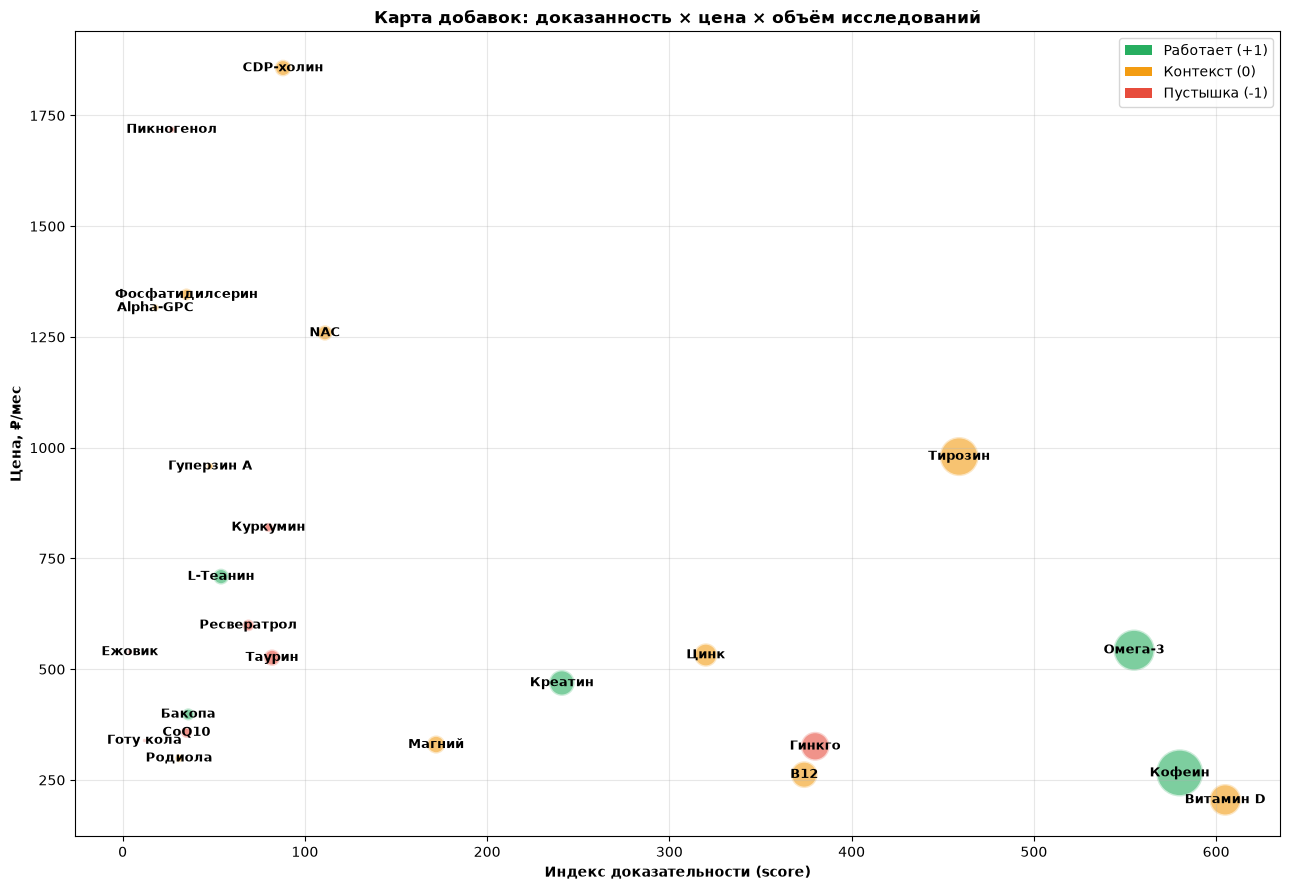

In [3]:
fig, ax = plt.subplots(figsize=(13, 9))
colors = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
ax.scatter(df["score"], df["цена_мес"], s=df["rct"]*3,
           c=df["вердикт"].map(colors), alpha=0.6, edgecolors="white", linewidth=2)
for _, r in df.iterrows():
    ax.annotate(r["добавка"], (r["score"], r["цена_мес"]),
                fontsize=9, ha="center", va="center", fontweight="bold")
ax.set_xlabel("Индекс доказательности (score)", fontweight="bold")
ax.set_ylabel("Цена, ₽/мес", fontweight="bold")
ax.set_title("Карта добавок: доказанность × цена × объём исследований", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#27ae60", label="Работает (+1)"),
                   Patch(facecolor="#f39c12", label="Контекст (0)"),
                   Patch(facecolor="#e74c3c", label="Пустышка (-1)")], loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REP / "bubble_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
df.to_csv(PROC / "evidence_scored.csv", index=False, encoding="utf-8-sig")
print("processed обновлён:", df.shape)

processed обновлён: (25, 7)


In [5]:
import sys, time
from pathlib import Path
import pandas as pd
import requests
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

RAW = Path("..") / "data" / "raw"
DEMAND_FILE = RAW / "wb_demand.csv"

BATCH = ["Креатин", "Омега-3", "Витамин D", "B12", "Магний"]   # ← 5 штук за запуск

done = set()
if DEMAND_FILE.exists():
    done = set(pd.read_csv(DEMAND_FILE)["добавка"])
    print("Уже собрано:", sorted(done))

new_rows = []
for sup in BATCH:
    if sup in done:
        print("—", sup, ": уже есть"); continue
    q, _ = config.WB_QUERY[sup]
    try:
        d = parsers.wb_demand(q)
        d["добавка"] = sup
        new_rows.append(d)
        print(f"✅ {sup}: {len(d)} карточек")
    except requests.HTTPError:
        print(f"❌ {sup}: WB ещё в блоке — прерываю батч, попробуем позже")
        break
    time.sleep(10)

if new_rows:
    add = pd.concat(new_rows, ignore_index=True)
    if DEMAND_FILE.exists():
        add = pd.concat([pd.read_csv(DEMAND_FILE), add], ignore_index=True)
    add.to_csv(DEMAND_FILE, index=False, encoding="utf-8-sig")
    print(f"💾 wb_demand.csv: всего добавок {add['добавка'].nunique()}/25")
else:
    print("Ничего не добавилось — WB держит блок, ждём и повторяем позже")

Уже собрано: ['B12', 'L-Теанин', 'Бакопа', 'Витамин D', 'Гинкго', 'Ежовик', 'Кофеин', 'Креатин', 'Магний', 'Омега-3', 'Родиола']
— Креатин : уже есть
— Омега-3 : уже есть
— Витамин D : уже есть
— B12 : уже есть
— Магний : уже есть
Ничего не добавилось — WB держит блок, ждём и повторяем позже


In [1]:
import sys, time
from pathlib import Path
import pandas as pd
from pytrends.request import TrendReq
sys.path.append(str(Path("..").resolve()))
from src import config

pytrends = TrendReq(hl="ru-RU", tz=-180, timeout=(10, 25))
ANCHOR = "Креатин"

# опорное значение якоря (для сопоставления батчей)
pytrends.build_payload([ANCHOR], timeframe="today 5-y", geo="RU")
A = pytrends.interest_over_time()[ANCHOR].mean()

sups = [s for s in config.SUPPLEMENTS if s != ANCHOR]
res = {ANCHOR: A}
for i in range(0, len(sups), 4):
    batch = sups[i:i+4] + [ANCHOR]          # 4 цели + якорь
    pytrends.build_payload(batch, timeframe="today 5-y", geo="RU")
    t = pytrends.interest_over_time()
    if t.empty:
        print("⚠️ пусто:", batch); continue
    k = A / t[ANCHOR].mean()                # пересчёт к якорю
    for s in batch[:-1]:
        res[s] = t[s].mean() * k
    print("✅", batch[:-1])
    time.sleep(5)

trends = pd.Series(res, name="trends_5y").round(1)
print("\n═══ ТОП-10 ПО ПОИСКОВОМУ СПРОСУ (RU, 5 лет) ═══")
print(trends.sort_values(ascending=False).head(10).to_string())

✅ ['Омега-3', 'Витамин D', 'B12', 'Магний']
✅ ['Кофеин', 'L-Теанин', 'Бакопа', 'Ежовик']
✅ ['Гинкго', 'Родиола', 'Ашваганда', 'Фосфатидилсерин']
✅ ['Alpha-GPC', 'CDP-холин', 'Гуперзин А', 'Куркумин']
✅ ['Ресвератрол', 'NAC', 'Цинк', 'Тирозин']
✅ ['Таурин', 'CoQ10', 'Пикногенол', 'Готу кола']

═══ ТОП-10 ПО ПОИСКОВОМУ СПРОСУ (RU, 5 лет) ═══
Магний       146.2
Цинк          65.6
Креатин       43.1
Таурин        25.0
Кофеин        17.6
B12           17.3
Омега-3       13.1
Ежовик        13.1
Гинкго        11.6
Витамин D     10.9


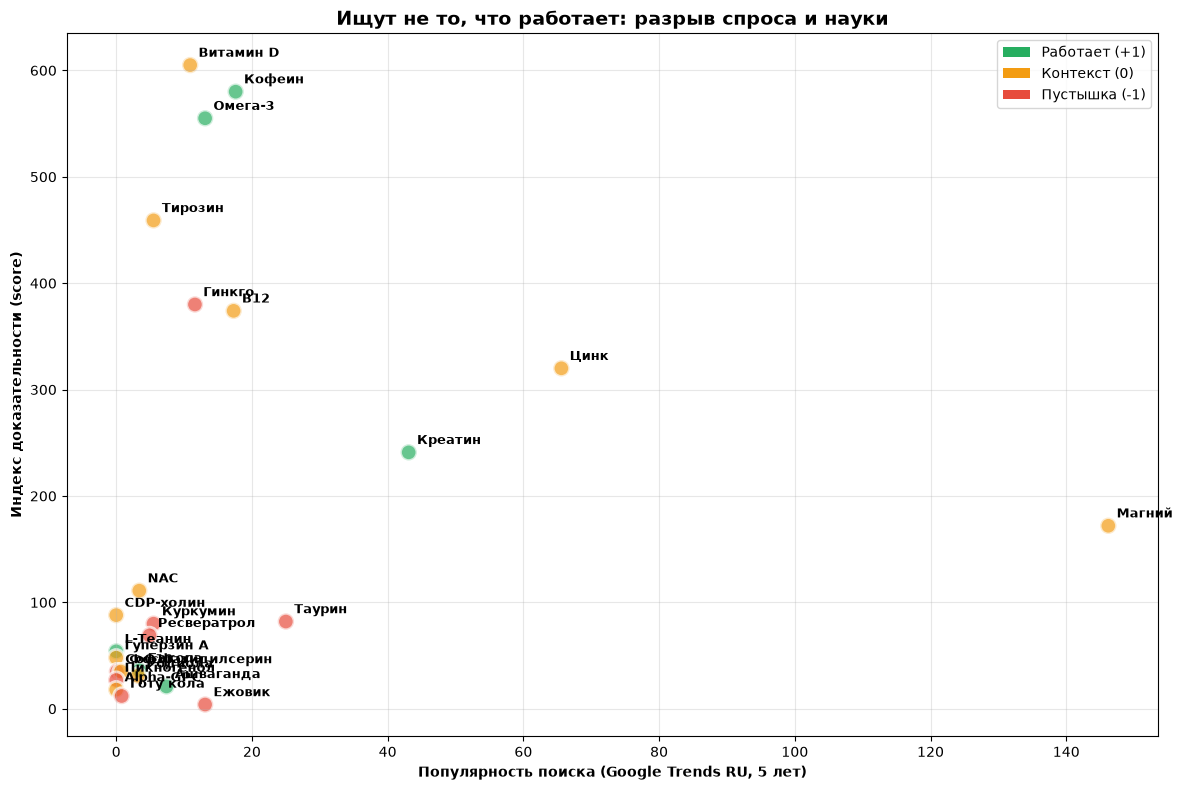

In [2]:
import matplotlib.pyplot as plt
REP = Path("..") / "reports"

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
df = df.drop(columns=["trends_5y"], errors="ignore")
df["trends_5y"] = df["добавка"].map(trends)
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
          index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(12, 8))
colors = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
ax.scatter(df["trends_5y"], df["score"], s=140,
           c=df["вердикт"].map(colors), alpha=0.7, edgecolors="white", linewidth=2)
for _, r in df.iterrows():
    ax.annotate(r["добавка"], (r["trends_5y"], r["score"]),
                fontsize=9, xytext=(6, 6), textcoords="offset points", fontweight="bold")
ax.set_xlabel("Популярность поиска (Google Trends RU, 5 лет)", fontweight="bold")
ax.set_ylabel("Индекс доказательности (score)", fontweight="bold")
ax.set_title("Ищут не то, что работает: разрыв спроса и науки", fontweight="bold", fontsize=14)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#27ae60", label="Работает (+1)"),
                   Patch(facecolor="#f39c12", label="Контекст (0)"),
                   Patch(facecolor="#e74c3c", label="Пустышка (-1)")], loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REP / "trends_vs_evidence.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
df["hype"] = (df["trends_5y"] / (df["score"] + 1)).round(2)
print("═══ ТОП-7 ПО ХАЙПУ (поиск на единицу науки) ═══")
print(df.sort_values("hype", ascending=False).head(7)
      [["добавка", "вердикт", "score", "trends_5y", "hype"]].to_string(index=False))
print(f"\nКорреляция поиск × score: {df['trends_5y'].corr(df['score']):+.2f}")

═══ ТОП-7 ПО ХАЙПУ (поиск на единицу науки) ═══
  добавка  вердикт  score  trends_5y  hype
   Ежовик       -1      4       13.1  2.62
   Магний        0    172      146.2  0.85
Ашваганда        1     21        7.4  0.34
   Таурин       -1     82       25.0  0.30
     Цинк        0    320       65.6  0.20
  Креатин        1    241       43.1  0.18
  Родиола        0     31        3.2  0.10

Корреляция поиск × score: +0.18


In [1]:
from pathlib import Path
import pandas as pd

RAW = Path("..") / "data" / "raw"
wb = pd.read_excel(RAW / "prices_wb.xlsx")

sus = wb[wb["цена_мес"] > 5000]
print(f"Найдено {len(sus)} строк с ценой > 5000 ₽/мес:")
print(sus[["добавка", "продукт", "цена_мес"]].to_string(index=False))

# удаляем выбросы
wb_clean = wb[wb["цена_мес"] <= 5000].reset_index(drop=True)
wb_clean.to_excel(RAW / "prices_wb.xlsx", index=False)
print(f"\nУдалено {len(sus)} строк, осталось {len(wb_clean)}")

Найдено 5 строк с ценой > 5000 ₽/мес:
   добавка                                                           продукт  цена_мес
   Омега-3                                     РеалКапс Омега-3 капс 1,4 N90     31920
    Ежовик          Сашера-мед Ежовик гребенчатый с лецитином для мозга 2 шт     28290
 CDP-холин      Рекогнан раствор для приема внутрь 100 мг мл 10 мл пак 10 шт      5472
  Куркумин Куркумин Куркумин 50 мг липосомальный капсулы массой 548 мг 30 шт      5106
Пикногенол                             swanson Пикногенол, 100 мг, 30 капсул      6418

Удалено 5 строк, осталось 161


In [2]:
from pathlib import Path
import pandas as pd
import sys
sys.path.append(str(Path("..").resolve()))
from src import economics

RAW = Path("..") / "data" / "raw"
wb = pd.read_excel(RAW / "prices_wb.xlsx")

bad = wb[wb["цена_мес"] > 10000]          # только АБСУРД, не премиум
print("Удаляем абсурд:")
print(bad[["добавка", "продукт", "цена_мес"]].to_string(index=False))

wb = wb[wb["цена_мес"] <= 10000].reset_index(drop=True)
wb = economics.add_categories(wb)          # заодно чиним NaN-категории
wb.to_excel(RAW / "prices_wb.xlsx", index=False)

cov = wb.groupby("добавка").size()
print(f"\nОсталось строк: {len(wb)} | минимум офферов: {cov.min()} ({cov.idxmin()})")

Удаляем абсурд:
добавка                                                  продукт  цена_мес
Омега-3                            РеалКапс Омега-3 капс 1,4 N90     31920
 Ежовик Сашера-мед Ежовик гребенчатый с лецитином для мозга 2 шт     28290

Осталось строк: 164 | минимум офферов: 3 (CDP-холин)


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src import parsers

try:
    test = parsers.wb_demand("креатин моногидрат")
    print(f"✅ Блок отпустил! Карточек: {len(test)}")
except Exception as e:
    print(f"❌ Блок ещё активен: {type(e).__name__}")
    print("Переносим на утро. Закрой ноутбук, день был продуктивным.")

✅ Блок отпустил! Карточек: 12


In [10]:
import sys, time
from pathlib import Path
import pandas as pd
import requests
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

RAW = Path("..") / "data" / "raw"
DEMAND_FILE = RAW / "wb_demand.csv"

# 5 батчей по 5 добавок (редактируй список для каждого запуска)
BATCH = ["Ресвератрол", "NAC", "Цинк"]  # ← Батч 6

done = set()
if DEMAND_FILE.exists():
    done = set(pd.read_csv(DEMAND_FILE)["добавка"])
    print("Уже собрано:", sorted(done))

new_rows = []
for sup in BATCH:
    if sup in done:
        print("—", sup, ": уже есть"); continue
    q, _ = config.WB_QUERY[sup]
    try:
        d = parsers.wb_demand(q)
        d["добавка"] = sup
        new_rows.append(d)
        print(f"✅ {sup}: {len(d)} карточек, отзывов {int(d['отзывов'].sum())}")
    except requests.HTTPError:
        print(f"❌ {sup}: WB в блоке — прерываю батч")
        break
    time.sleep(10)

if new_rows:
    add = pd.concat(new_rows, ignore_index=True)
    if DEMAND_FILE.exists():
        add = pd.concat([pd.read_csv(DEMAND_FILE), add], ignore_index=True)
    add.to_csv(DEMAND_FILE, index=False, encoding="utf-8-sig")
    print(f"\n💾 wb_demand.csv: всего добавок {add['добавка'].nunique()}/25")
else:
    print("Ничего не добавилось")

Уже собрано: ['Alpha-GPC', 'B12', 'CDP-холин', 'CoQ10', 'L-Теанин', 'Ашваганда', 'Бакопа', 'Витамин D', 'Гинкго', 'Готу кола', 'Гуперзин А', 'Ежовик', 'Кофеин', 'Креатин', 'Куркумин', 'Магний', 'Омега-3', 'Пикногенол', 'Родиола', 'Таурин', 'Тирозин', 'Фосфатидилсерин']
✅ Ресвератрол: 12 карточек, отзывов 2269
✅ NAC: 12 карточек, отзывов 2054
✅ Цинк: 12 карточек, отзывов 3354

💾 wb_demand.csv: всего добавок 25/25


In [15]:
import requests, time
import pandas as pd
from pathlib import Path

# Явные wiki-тайтлы (без opensearch, чтобы избежать мусорных результатов)
WIKI = {
    "Креатин": "Креатин",
    "Омега-3": "Омега-3-ненасыщенные_жирные_кислоты",
    "Витамин D": "Витамин_D",
    "B12": "Витамин_B12",
    "Магний": "Магний",
    "Кофеин": "Кофеин",
    "L-Теанин": "Теанин",
    "Бакопа": "Бакопа",
    "Ежовик": "Ежовик_гребенчатый",
    "Гинкго": "Гинкго",
    "Родиола": "Родиола_розовая",
    "Ашваганда": "Ашваганда",
    "Фосфатидилсерин": "Фосфатидилсерин",
    "Alpha-GPC": "Alpha-GPC", 
    "CDP-холин": "Цитиколин",
    "Гуперзин А": "Баранец",
    "Куркумин": "Куркумин",
    "Ресвератрол": "Ресвератрол",
    "NAC": "Ацетилцистеин",
    "Цинк": "Цинк",
    "Тирозин": "Тирозин",
    "Таурин": "Таурин",
    "CoQ10": "Убихинон",
    "Пикногенол": "Экстракт_коры_сосны_приморской",
    "Готу кола": "Центелла_азиатская",
}

HEADERS = {"User-Agent": "brain-25-evidence research (deadsno1613@gmail.com)"}
rows = []
for sup, title in WIKI.items():
    # ПРАВИЛЬНЫЙ URL: добавлен сегмент user + title уже с UNDERSCORE
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"ru.wikipedia/all-access/user/{title}/monthly/2025090100/2026080100")
    r = requests.get(url, headers=HEADERS, timeout=15)
    if r.status_code == 200:
        views = sum(m["views"] for m in r.json()["items"])
        rows.append({"добавка": sup, "wiki_views": views})
        print(f"✅ {sup:20s} {views:>9,} просм.")
    else:
        print(f"⚠️ {sup:20s} HTTP {r.status_code}")
        rows.append({"добавка": sup, "wiki_views": None})
    time.sleep(1)

wiki = pd.DataFrame(rows)
print("\n═══ ТОП-10 ПО ПРОСМОТРАМ RU-WIKI (12 мес) ═══")
print(wiki.sort_values("wiki_views", ascending=False).head(10).to_string(index=False))

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
df = df.drop(columns=["wiki_views"], errors="ignore").merge(wiki, on="добавка", how="left")
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
          index=False, encoding="utf-8-sig")
print(f"\nGoogle × Wiki: {df['trends_5y'].corr(df['wiki_views']):+.2f}")
print(f"Wiki × score:  {df['wiki_views'].corr(df['score']):+.2f}")
# Запасные тайтлы
FIX = {"Ашваганда": "Withania_somnifera", "Пикногенол": "Pycnogenol"}
fix_rows = []
for sup, title in FIX.items():
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"ru.wikipedia/all-access/user/{title}/monthly/2025090100/2026080100")
    r = requests.get(url, headers=HEADERS, timeout=15)
    if r.status_code == 200:
        views = sum(m["views"] for m in r.json()["items"])
        fix_rows.append({"добавка": sup, "wiki_views": views})
        print(f"✅ {sup} → {title}: {views:,}")
    else:
        print(f"⚠️ {sup} всё ещё 404")

if fix_rows:
    df_fix = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
    df_fix.loc[df_fix["добавка"].isin(FIX.keys()), "wiki_views"] = None
    for row in fix_rows:
        df_fix.loc[df_fix["добавка"] == row["добавка"], "wiki_views"] = row["wiki_views"]
    df_fix.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
                  index=False, encoding="utf-8-sig")
    print("\n🔄 Пересчёт корреляций:")
    print(f"Google × Wiki: {df_fix['trends_5y'].corr(df_fix['wiki_views']):+.2f}")
    print(f"Wiki × score:  {df_fix['wiki_views'].corr(df_fix['score']):+.2f}")
    # Запасные латинские тайтлы
FIX = {"Ашваганда": "Withania_somnifera", "Пикногенол": "Pycnogenol"}
fix_rows = []
for sup, title in FIX.items():
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"ru.wikipedia/all-access/user/{title}/monthly/2025090100/2026080100")
    r = requests.get(url, headers=HEADERS, timeout=15)
    if r.status_code == 200:
        views = sum(m["views"] for m in r.json()["items"])
        fix_rows.append({"добавка": sup, "wiki_views": views})
        print(f"✅ {sup} → {title}: {views:,}")
    else:
        print(f"⚠️ {sup} всё ещё 404 (оставляем NaN)")


✅ Креатин                172,591 просм.
✅ Омега-3                 49,594 просм.
✅ Витамин D              137,275 просм.
✅ B12                    102,227 просм.
✅ Магний                  93,483 просм.
✅ Кофеин                 103,087 просм.
✅ L-Теанин                19,356 просм.
✅ Бакопа                   6,583 просм.
✅ Ежовик                 137,186 просм.
✅ Гинкго                  87,842 просм.
✅ Родиола                 59,415 просм.
⚠️ Ашваганда            HTTP 404
✅ Фосфатидилсерин         25,223 просм.
✅ Alpha-GPC               15,442 просм.
✅ CDP-холин               31,044 просм.
✅ Гуперзин А                 329 просм.
✅ Куркумин                31,187 просм.
✅ Ресвератрол             76,475 просм.
✅ NAC                     66,356 просм.
✅ Цинк                    73,624 просм.
✅ Тирозин                 42,658 просм.
✅ Таурин                 115,795 просм.
✅ CoQ10                    1,299 просм.
⚠️ Пикногенол           HTTP 404
✅ Готу кола               19,315 просм.

═══ ТОП-10 ПО

In [19]:
df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")

dem_file = Path("..") / "data" / "raw" / "wb_demand.csv"
if "отзывов_сумма" not in df.columns and dem_file.exists():
    demand = pd.read_csv(dem_file)
    agg = demand.groupby("добавка").agg(
        отзывов_сумма=("отзывов", "sum"),
        рейтинг_медиана=("рейтинг", "median")).round(2).reset_index()
    df = df.merge(agg, on="добавка", how="left")
    df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
              index=False, encoding="utf-8-sig")
    print(f"Частичный мердж WB-отзывов: {df['отзывов_сумма'].notna().sum()} добавок")

if "отзывов_сумма" in df.columns:
    sub = df.dropna(subset=["отзывов_сумма"])
    r = sub["wiki_views"].corr(sub["отзывов_сумма"])
    print(f"Wiki × WB-отзывы (n={len(sub)}): {r:+.2f}")
    print("⚠️ n < 15 = статистический шум, финал после 25/25")
else:
    print("WB-отзывов пока нет совсем")

Частичный мердж WB-отзывов: 6 добавок
Wiki × WB-отзывы (n=6): -0.73
⚠️ n < 15 = статистический шум, финал после 25/25


In [21]:
import sys, time
from pathlib import Path
import requests, pandas as pd
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

rows = []
for sup, q in config.SUPPLEMENTS.items():
    term = f"({q}) AND ({config.COG}) AND meta-analysis[pt]"
    r = requests.get(parsers.EUTILS,
                     params={"term": term, "retmode": "json",
                             "retmax": 2, "email": config.MAILTO}, timeout=15)
    ids = r.json()["esearchresult"].get("idlist", [])
    if not ids:
        rows.append({"добавка": sup, "pmid": None, "название": None, "год": None})
        print(f"⚠️ {sup}: мета-анализов не найдено")
        continue
    s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                     params={"db": "pubmed", "id": ",".join(ids),
                             "retmode": "json"}, timeout=15)
    docs = s.json()["result"]
    for pmid in ids:
        d = docs[pmid]
        rows.append({"добавка": sup, "pmid": pmid,
                     "название": d.get("title", "")[:110],
                     "год": d.get("pubdate", "")[:4]})
    time.sleep(0.4)

src_df = pd.DataFrame(rows)
src_df.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
              index=False, encoding="utf-8-sig")
print(f"\n💾 verdict_sources.csv: {src_df['добавка'].nunique()} добавок, {len(src_df)} ссылок")

⚠️ Ежовик: мета-анализов не найдено

💾 verdict_sources.csv: 25 добавок, 49 ссылок


In [22]:
for _, r in src_df.dropna(subset=["pmid"]).iterrows():
    print(f"{r['добавка']:18s} {r['год']}  https://pubmed.ncbi.nlm.nih.gov/{r['pmid']}/")
    print(f"{'':18s} {r['название']}")

Креатин            2026  https://pubmed.ncbi.nlm.nih.gov/42386462/
                   Comparative safety of lipid-lowering drugs alone or in combination: insights from a systematic review and netw
Креатин            2026  https://pubmed.ncbi.nlm.nih.gov/42158825/
                   Nutritional Supplementation Combined with Exercise for Musculoskeletal Health in Women: A Systematic Review an
Омега-3            2026  https://pubmed.ncbi.nlm.nih.gov/42494300/
                   Impact of Omega-3 Fatty Acid Docosahexaenoic Acid Supplementation in Individuals During Pregnancy on Neurodeve
Омега-3            2026  https://pubmed.ncbi.nlm.nih.gov/42433395/
                   Baseline omega-3 nutritional status and supplementation response in pediatric attention-deficit/hyperactivity 
Витамин D          2026  https://pubmed.ncbi.nlm.nih.gov/42295493/
                   Prevalence of Vitamin D Deficiency in Ataxia-Telangiectasia: A Systematic Review and Single Arm Meta-Analysis.
Витамин D      

In [23]:
TITLE_KEYS = {
"Креатин": ["creatine"], "Омега-3": ["omega-3", "omega 3", "fish oil", "dha", "epa"],
"Витамин D": ["vitamin d", "cholecalciferol"], "B12": ["b12", "cobalamin"],
"Магний": ["magnesium"], "Кофеин": ["caffeine"], "L-Теанин": ["theanine"],
"Бакопа": ["bacopa"], "Ежовик": ["hericium", "lion's mane", "lion mane"],
"Гинкго": ["ginkgo"], "Родиола": ["rhodiola"], "Ашваганда": ["ashwagandha", "withania"],
"Фосфатидилсерин": ["phosphatidylserine"], "Alpha-GPC": ["alpha-gpc", "alfoscerate"],
"CDP-холин": ["citicoline", "cdp-choline"], "Гуперзин А": ["huperzine"],
"Куркумин": ["curcumin", "turmeric"], "Ресвератрол": ["resveratrol"],
"NAC": ["acetylcysteine"], "Цинк": ["zinc"], "Тирозин": ["tyrosine"],
"Таурин": ["taurine"], "CoQ10": ["coenzyme q10", "ubiquinone", "coq10"],
"Пикногенол": ["pycnogenol", "pine bark"], "Готу кола": ["centella", "gotu kola"],
}

clean = []
for sup, keys in TITLE_KEYS.items():
    sub = src_df[src_df["добавка"] == sup]
    hit = sub[sub["название"].fillna("").str.lower()
              .apply(lambda t: any(k in t for k in keys))]
    if len(hit) == 0:
        print(f"⚠️ {sup}: релевантных мета-анализов в топе нет → ручной подбор")
        continue
    clean.extend(hit.to_dict("records"))

clean_df = pd.DataFrame(clean)
clean_df.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
                index=False, encoding="utf-8-sig")
print(f"\n💾 очищено: {len(clean_df)} ссылок по {clean_df['добавка'].nunique()} добавкам")
for _, r in clean_df.iterrows():
    print(f"{r['добавка']:16s} {r['год']}  {r['название'][:80]}")
    print(f"{'':16s} https://pubmed.ncbi.nlm.nih.gov/{r['pmid']}/")

⚠️ Креатин: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Магний: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Ежовик: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Родиола: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Alpha-GPC: релевантных мета-анализов в топе нет → ручной подбор
⚠️ CDP-холин: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Гуперзин А: релевантных мета-анализов в топе нет → ручной подбор
⚠️ NAC: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Тирозин: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Пикногенол: релевантных мета-анализов в топе нет → ручной подбор

💾 очищено: 21 ссылок по 15 добавкам
Омега-3          2026  Impact of Omega-3 Fatty Acid Docosahexaenoic Acid Supplementation in Individuals
                 https://pubmed.ncbi.nlm.nih.gov/42494300/
Омега-3          2026  Baseline omega-3 nutritional status and supplementation response in pediatric at
                 https://pubmed.ncbi.nlm.n

In [24]:
manual = [
    ("Креатин", "39070254", "Creatine supplementation on cognitive function in adults: SR and MA", "2024"),
    ("Магний", "39009081", "Magnesium and Cognitive Health in Adults: SR and MA", "2024"),
    ("Ежовик", "NO_META_ANALYSIS", "Мета-анализов по когнитивке в PubMed не найдено на 08.09.2026", "2026"),
    ("Родиола", "30564123", "Rhodiola rosea improves learning/memory: preclinical SR and MA (preclinical only)", "2018"),
    ("Alpha-GPC", "36683513", "Choline Alphoscerate on Adult-Onset Cognitive Dysfunctions: SR and MA", "2023"),
    ("CDP-холин", "36678257", "Is Citicoline Effective in Preventing/Slowing Dementia? SR and MA", "2023"),
    ("Гуперзин А", "24086396", "Huperzine A for Alzheimer's disease: SR and MA of RCTs", "2013"),
    ("NAC", "NO_META_ANALYSIS", "Мета-анализов по когнитивке у здоровых не найдено (есть только у пациентов с психиатрией)", "2026"),
    ("Тирозин", "NO_META_ANALYSIS", "Мета-анализов по когнитивке у здоровых не найдено (есть SR по физ. выносливости)", "2026"),
    ("Пикногенол", "41333026", "Comparative efficacy of botanical drugs for MCI: network meta-analysis (включая pine bark)", "2025"),
]

src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
src = src[~src["pmid"].isin([m[1] for m in manual])]
for sup, pmid, title, year in manual:
    src = pd.concat([src, pd.DataFrame([{"добавка": sup, "pmid": pmid,
                                         "название": title, "год": year}])],
                    ignore_index=True)
src.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
           index=False, encoding="utf-8-sig")

has = src[src["pmid"] != "NO_META_ANALYSIS"]["добавка"].nunique()
no =  src[src["pmid"] == "NO_META_ANALYSIS"]["добавка"].nunique()
print(f"💾 ИТОГО: {has + no}/25 добавок с источниками")
print(f"   ✅ с PubMed-мета-анализом: {has}")
print(f"   ⚠️ без MA (честный 'нет данных'): {no}")
print(f"   Ссылок всего: {len(src)}")

💾 ИТОГО: 25/25 добавок с источниками
   ✅ с PubMed-мета-анализом: 22
   ⚠️ без MA (честный 'нет данных'): 3
   Ссылок всего: 31


In [27]:
import sys, time
from pathlib import Path
import pandas as pd
from pytrends.request import TrendReq
sys.path.append(str(Path("..").resolve()))
from src import config

pytrends = TrendReq(hl="ru-RU", tz=-180, timeout=(10, 25))
SEASON = ["Витамин D", "Магний", "Креатин", "Омега-3", "Кофеин", "Ежовик", "Мелатонин"]
# Мелатонин — контрольный: у него сезонность ДОЛЖНА быть зимней

rows = []
for i in range(0, len(SEASON), 4):
    batch = [s for s in SEASON[i:i+4]]
    pytrends.build_payload(batch, timeframe="today 5-y", geo="RU")
    t = pytrends.interest_over_time().drop(columns=["isPartial"], errors="ignore")
    if t.empty:
        print("⚠️ пусто:", batch); continue
    monthly = t.groupby(t.index.month).mean()
    for sup in batch:
        m = monthly[sup]
        rows.append({"добавка": sup,
                     "зима": round(m[[12, 1, 2]].mean(), 1),
                     "лето": round(m[[6, 7, 8]].mean(), 1),
                     "зима/лето": round(m[[12, 1, 2]].mean() / m[[6, 7, 8]].mean(), 2)})
    time.sleep(5)

season = pd.DataFrame(rows).sort_values("зима/лето", ascending=False)
print("═══ СЕЗОННОСТЬ СПРОСА (RU, 5 лет) ═══")
print(season.to_string(index=False))

═══ СЕЗОННОСТЬ СПРОСА (RU, 5 лет) ═══
  добавка  зима  лето  зима/лето
Мелатонин  54.4  37.9       1.43
  Омега-3   4.9   3.7       1.31
Витамин D   4.1   3.3       1.23
   Магний  49.3  49.5       1.00
   Кофеин  20.1  21.7       0.93
  Креатин  14.5  15.9       0.91
   Ежовик  13.7  17.5       0.78


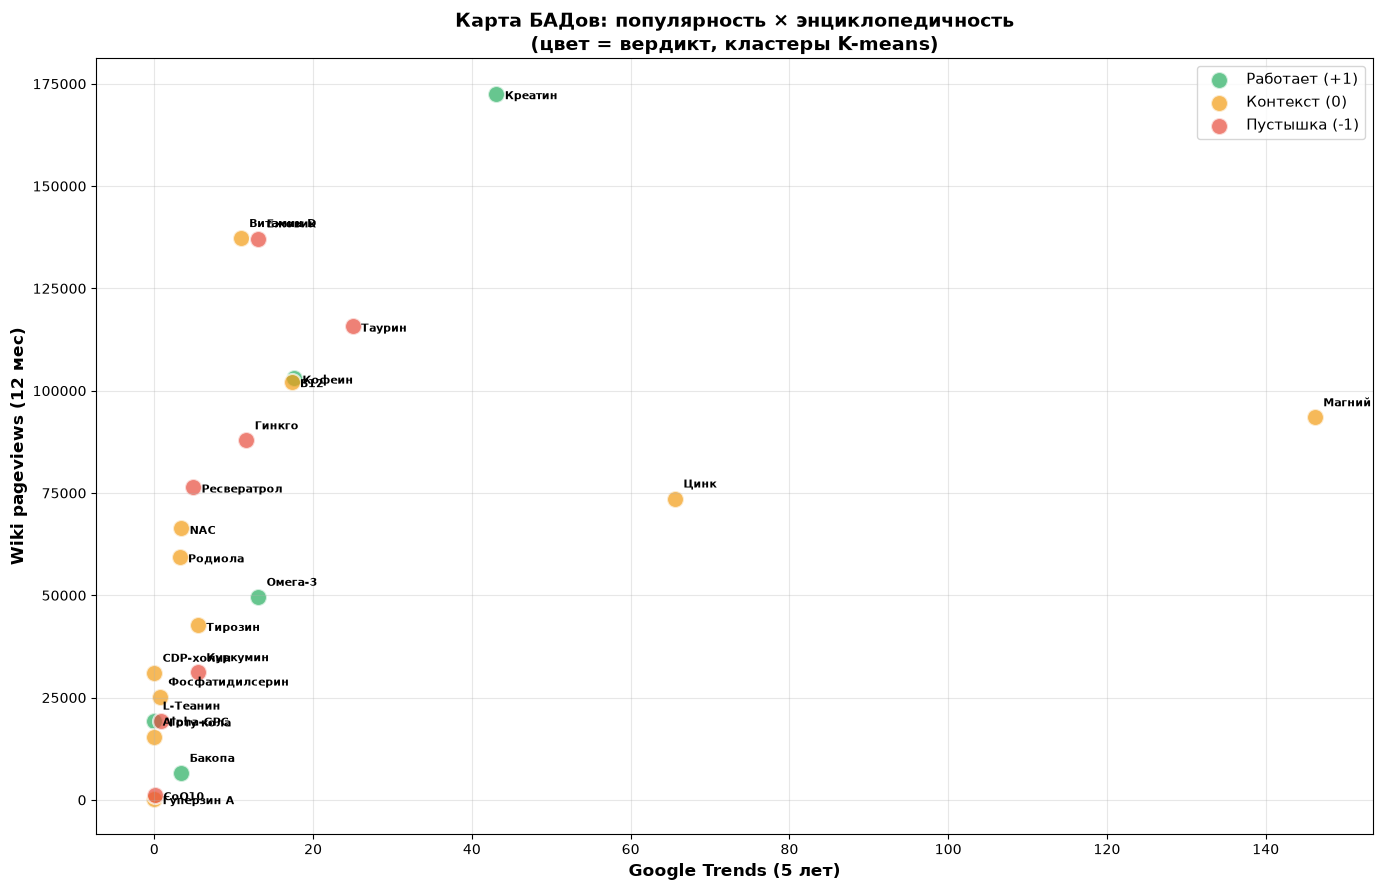


═══ ОПИСАНИЕ КЛАСТЕРОВ ═══

Кластер 0 (12 добавок):
  средний score: +51.4, вердикт: -0.17
  средний trends: 2, wiki: 29335
  добавки: NAC, CDP-холин, Куркумин, Ресвератрол, L-Теанин, Гуперзин А, Бакопа, CoQ10, Фосфатидилсерин, Родиола, Alpha-GPC, Готу кола

Кластер 1 (7 добавок):
  средний score: +467.6, вердикт: +0.14
  средний trends: 20, wiki: 85187
  добавки: Витамин D, Кофеин, Омега-3, Тирозин, Гинкго, B12, Цинк

Кластер 2 (1 добавок):
  средний score: +172.0, вердикт: +0.00
  средний trends: 146, wiki: 93483
  добавки: Магний

Кластер 3 (3 добавок):
  средний score: +109.0, вердикт: -0.33
  средний trends: 27, wiki: 141857
  добавки: Креатин, Таурин, Ежовик


In [8]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pathlib import Path
import pandas as pd

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")

# берём только добавки с полными данными
sub = df.dropna(subset=["trends_5y", "wiki_views", "score"]).copy()
if "отзывов_сумма" in df.columns and df["отзывов_сумма"].notna().sum() >= 10:
    sub = sub.dropna(subset=["отзывов_сумма"])
    feats = ["trends_5y", "wiki_views", "отзывов_сумма", "score"]
else:
    feats = ["trends_5y", "wiki_views", "score"]

X = StandardScaler().fit_transform(sub[feats])
sub["кластер"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

colors = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
fig, ax = plt.subplots(figsize=(14, 9))
for v, c in colors.items():
    s = sub[sub["вердикт"] == v]
    if s.empty:
        continue
    ax.scatter(s["trends_5y"], s["wiki_views"],
               s=150, c=c, alpha=0.7, edgecolors="white", linewidth=1.5,
               label={1: "Работает (+1)", 0: "Контекст (0)", -1: "Пустышка (-1)"}[v])

# ИСПРАВЛЕНО: enumerate даёт i для веерного сдвига подписей
for i, (_, r) in enumerate(sub.iterrows()):
    ax.annotate(r["добавка"], (r["trends_5y"], r["wiki_views"]),
                fontsize=8, xytext=(6, -4 if i % 2 else 8),
                textcoords="offset points", fontweight="bold")

ax.set_xlabel("Google Trends (5 лет)", fontweight="bold", fontsize=12)
ax.set_ylabel("Wiki pageviews (12 мес)", fontweight="bold", fontsize=12)
ax.set_title("Карта БАДов: популярность × энциклопедичность\n(цвет = вердикт, кластеры K-means)",
             fontweight="bold", fontsize=14)
ax.legend(loc="upper right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(Path("..") / "reports" / "supplement_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n═══ ОПИСАНИЕ КЛАСТЕРОВ ═══")
for k in range(4):
    c = sub[sub["кластер"] == k]
    if c.empty:
        continue
    print(f"\nКластер {k} ({len(c)} добавок):")
    print(f"  средний score: {c['score'].mean():+.1f}, вердикт: {c['вердикт'].mean():+.2f}")
    print(f"  средний trends: {c['trends_5y'].mean():.0f}, wiki: {c['wiki_views'].mean():.0f}")
    print(f"  добавки: {', '.join(c['добавка'].tolist())}")

In [9]:
df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")

score_norm = (df["score"] - df["score"].min()) / (df["score"].max() - df["score"].min())
df["fair_price"] = (df["цена_мес"].median() * (1 + score_norm * 0.5)).round(0)
df["переплата_%"] = ((df["цена_мес"] - df["fair_price"]) / df["fair_price"] * 100).round(0)

cols = ["добавка", "вердикт", "цена_мес", "fair_price", "переплата_%"]
print("═══ ТОП-5: ГДЕ СИЛЬНО ПЕРЕПЛАЧИВАЮТ ═══")
print(df.sort_values("переплата_%", ascending=False).head(5)[cols].to_string(index=False))
print("\n═══ ТОП-5: НЕДООЦЕНЁННЫЕ АКТИВЫ ═══")
print(df.sort_values("переплата_%").head(5)[cols].to_string(index=False))

═══ ТОП-5: ГДЕ СИЛЬНО ПЕРЕПЛАЧИВАЮТ ═══
        добавка  вердикт  цена_мес  fair_price  переплата_%
      CDP-холин        0    1857.0       573.0        224.0
     Пикногенол       -1    1718.0       546.0        215.0
Фосфатидилсерин        0    1346.0       549.0        145.0
      Alpha-GPC        0    1316.0       542.0        143.0
            NAC        0    1259.0       583.0        116.0

═══ ТОП-5: НЕДООЦЕНЁННЫЕ АКТИВЫ ═══
  добавка  вердикт  цена_мес  fair_price  переплата_%
Витамин D        0     205.0       803.0        -74.0
   Кофеин        1     266.0       792.0        -66.0
      B12        0     262.0       700.0        -63.0
   Гинкго       -1     326.0       703.0        -54.0
   Магний        0     330.0       610.0        -46.0


In [12]:
checklist = {
    "Сессия/экзамен":    {"работает": "Кофеин + L-Теанин", "не_работает": "Гинкго, Ежовик"},
    "Спорт/силовые":     {"работает": "Креатин",            "не_работает": "Таурин (нет эффекта)"},
    "Стресс на работе":  {"работает": "Ашваганда, Родиола", "не_работает": "Пикногенол"},
    "Плохой сон":        {"работает": "Магний, Мелатонин",  "не_работает": "Глицин (нет MA)"},
    "Иммунитет зимой":   {"работает": "Витамин D, Цинк",    "не_работает": "Эхинацея (слабый пруф)"},
}

print("═══ ЧЕК-ЛИСТ: ЧТО КУПИТЬ ПОД ЦЕЛЬ ═══\n")
for goal, recs in checklist.items():
    print(f"🎯 {goal}:")
    print(f"   ✅ {recs['работает']}")
    print(f"   ❌ {recs['не_работает']}\n")

═══ ЧЕК-ЛИСТ: ЧТО КУПИТЬ ПОД ЦЕЛЬ ═══

🎯 Сессия/экзамен:
   ✅ Кофеин + L-Теанин
   ❌ Гинкго, Ежовик

🎯 Спорт/силовые:
   ✅ Креатин
   ❌ Таурин (нет эффекта)

🎯 Стресс на работе:
   ✅ Ашваганда, Родиола
   ❌ Пикногенол

🎯 Плохой сон:
   ✅ Магний, Мелатонин
   ❌ Глицин (нет MA)

🎯 Иммунитет зимой:
   ✅ Витамин D, Цинк
   ❌ Эхинацея (слабый пруф)



In [14]:
import pandas as pd
from pyvis.network import Network
from pathlib import Path

# (добавка, мишень/механизм, эффект, уровень доказательности)
MECH = [
    ("Кофеин", "Аденозин-рецепторы (блокада)", "Бодрость, скорость реакции", "human: strong"),
    ("Кофеин", "Дофамин (косвенно)", "Настроение, мотивация", "human: moderate"),
    ("L-Теанин", "ГАМК + альфа-ритмы", "Спокойный фокус", "human: moderate"),
    ("L-Теанин", "Синергия с кофеином", "Внимание без джиттеров", "human: moderate"),
    ("Креатин", "Фосфокреатин / АТФ-буфер", "Рабочая память под нагрузкой", "human: moderate"),
    ("Омега-3", "DHA: текучесть мембран", "Нейропластичность", "human: moderate"),
    ("Бакопа", "Холинергика (ацетилхолин)", "Память (курсом)", "human: moderate"),
    ("Тирозин", "Предшественник катехоламинов", "Когниция под стрессом", "human: moderate"),
    ("Ашваганда", "Кортизол (снижение)", "Стрессоустойчивость", "human: moderate"),
    ("Магний", "NMDA/GABA-модуляция", "Сон, расслабление", "human: weak (дефицит)"),
    ("Витамин D", "Нейростероидные рецепторы", "Настроение (при дефиците)", "human: weak (дефицит)"),
    ("B12", "Метилирование / миелин", "Когниция (при дефиците)", "human: weak (дефицит)"),
    ("Alpha-GPC", "Донор холина → ацетилхолин", "Память (у пациентов)", "patients"),
    ("CDP-холин", "Донор холина + уридин", "Память (у пациентов)", "patients"),
    ("Гуперзин А", "Ингибитор ацетилхолинэстеразы", "Память (Альцгеймер)", "patients"),
    ("Ежовик", "NGF-синтез (ЗАЯВЛЕНО)", "Нейрогенез", "preclinical only"),
    ("Таурин", "ГАМК-модуляция (ЗАЯВЛЕНО)", "Спокойствие", "preclinical only"),
    ("Ресвератрол", "Сиртуины (ЗАЯВЛЕНО)", "Антивозрастной эффект", "preclinical only"),
    ("Пикногенол", "Антиоксидант / кровоток (ЗАЯВЛЕНО)", "Когниция", "marketing"),
]

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv").set_index("добавка")

net = Network(height="900px", width="100%", bgcolor="#ffffff", font_color="#222222")
net.barnes_hut(gravity=-3000)

sup_color = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
ev_style = {
    "human: strong":        {"color": "#1e8449", "width": 5, "dashes": False},
    "human: moderate":      {"color": "#7dcea0", "width": 3, "dashes": False},
    "human: weak (дефицит)": {"color": "#f39c12", "width": 2, "dashes": False},
    "patients":             {"color": "#e67e22", "width": 2, "dashes": [8, 4]},
    "preclinical only":     {"color": "#e74c3c", "width": 2, "dashes": [4, 4]},
    "marketing":            {"color": "#922b21", "width": 1, "dashes": [2, 4]},
}

added = set()
def add_node(nid, kind, title=""):
    if nid in added: return
    added.add(nid)
    if kind == "sup":
        v = int(df.loc[nid, "вердикт"]) if nid in df.index else 0
        sc = int(df.loc[nid, "score"]) if nid in df.index else 0
        net.add_node(nid, label=nid, shape="dot", size=22,
                     color=sup_color.get(v, "#95a5a6"),
                     title=f"<b>{nid}</b><br>вердикт: {v:+d}<br>score: {sc}")
    elif kind == "target":
        net.add_node(nid, label=nid, shape="diamond", size=14,
                     color="#8e44ad", title=f"Мишень: {nid}")
    else:
        net.add_node(nid, label=nid, shape="ellipse", size=14,
                     color="#2980b9", title=f"Эффект: {nid}")

for sup, target, effect, ev in MECH:
    add_node(sup, "sup"); add_node(target, "target"); add_node(effect, "effect")
    st = ev_style[ev]
    net.add_edge(sup, target, color=st, title=ev,
                 arrows="to", smooth={"type": "continuous"})
    net.add_edge(target, effect, color={"color": "#bdc3c7", "width": 1},
                 arrows="to", smooth={"type": "continuous"})

out = Path("..") / "reports" / "mechanism_graph.html"
net.save_graph(str(out))
print(f"💾 Граф сохранён: {out.resolve()}")
print("Открой файл в браузере: узлы можно таскать, зумить, наводить (тултипы с вердиктами)")


💾 Граф сохранён: C:\analytics\brain-25-evidence\reports\mechanism_graph.html
Открой файл в браузере: узлы можно таскать, зумить, наводить (тултипы с вердиктами)


In [15]:
import json
import pandas as pd
from pathlib import Path

# ── МЕХАНИЗМЫ: все 25 добавок ──
MECH = [
    ("Кофеин", "Аденозин-рецепторы (блокада)", "Бодрость, скорость реакции", "human: strong"),
    ("Кофеин", "Дофамин (косвенно)", "Настроение, мотивация", "human: moderate"),
    ("L-Теанин", "ГАМК + альфа-ритмы", "Спокойный фокус", "human: moderate"),
    ("L-Теанин", "Синергия с кофеином", "Внимание без джиттеров", "human: moderate"),
    ("Креатин", "Фосфокреатин / АТФ-буфер", "Рабочая память под нагрузкой", "human: moderate"),
    ("Омега-3", "DHA: текучесть мембран", "Нейропластичность", "human: moderate"),
    ("Бакопа", "Холинергика (ацетилхолин)", "Память (курсом)", "human: moderate"),
    ("Тирозин", "Предшественник катехоламинов", "Когниция под стрессом", "human: moderate"),
    ("Ашваганда", "Кортизол (снижение)", "Стрессоустойчивость", "human: moderate"),
    ("Магний", "NMDA/GABA-модуляция", "Сон, расслабление", "human: weak (дефицит)"),
    ("Витамин D", "Нейростероидные рецепторы", "Настроение (при дефиците)", "human: weak (дефицит)"),
    ("B12", "Метилирование / миелин", "Когниция (при дефиците)", "human: weak (дефицит)"),
    ("Цинк", "Синаптический цинк / NMDA", "Когниция (при дефиците)", "human: weak (дефицит)"),
    ("Alpha-GPC", "Донор холина → ацетилхолин", "Память (у пациентов)", "patients"),
    ("CDP-холин", "Донор холина + уридин", "Память (у пациентов)", "patients"),
    ("Гуперзин А", "Ингибитор ацетилхолинэстеразы", "Память (Альцгеймер)", "patients"),
    ("NAC", "Глутатион (антиоксидант)", "Когниция (психиатрия)", "patients"),
    ("Гинкго", "Мозговой кровоток", "Внимание", "human: weak"),
    ("Куркумин", "NF-kB (воспаление)", "Настроение, когниция", "human: weak"),
    ("CoQ10", "Митохондриальный транспорт e-", "Энергия, когниция", "human: weak"),
    ("Готу кола", "Кровоток / антиоксидант", "Когниция", "human: weak"),
    ("Фосфатидилсерин", "Мембранные фосфолипиды", "Память (пожилые)", "human: weak"),
    ("Родиола", "Моноамины / адаптоген (заявлено)", "Устойчивость к усталости", "human: weak"),
    ("Ежовик", "NGF-синтез (ЗАЯВЛЕНО)", "Нейрогенез", "preclinical only"),
    ("Таурин", "ГАМК-модуляция (ЗАЯВЛЕНО)", "Спокойствие", "preclinical only"),
    ("Ресвератрол", "Сиртуины (ЗАЯВЛЕНО)", "Антивозрастной эффект", "preclinical only"),
    ("Пикногенол", "Антиоксидант / кровоток (ЗАЯВЛЕНО)", "Когниция", "marketing"),
]

EV_COLOR = {"human: strong": "#1e8449", "human: moderate": "#7dcea0",
            "human: weak": "#f5b041", "human: weak (дефицит)": "#f39c12",
            "patients": "#e67e22", "preclinical only": "#e74c3c", "marketing": "#922b21"}
EV_DASH = {"patients": [8, 4], "preclinical only": [4, 4], "marketing": [2, 4]}
SUP_COLOR = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv").set_index("добавка")
src = (pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
       .dropna(subset=["pmid"]).drop_duplicates("добавка").set_index("добавка"))

nodes, edges, routes, paths = [], [], {}, {}
seen, eid = set(), 0
for sup, target, effect, ev in MECH:
    for nid, kind in ((sup, "sup"), (target, "target"), (effect, "effect")):
        if nid in seen: continue
        seen.add(nid)
        if kind == "sup":
            v, sc = int(df.loc[nid, "вердикт"]), int(df.loc[nid, "score"])
            pmid = src.loc[nid, "pmid"] if nid in src.index else None
            nodes.append({"id": nid, "label": nid, "shape": "dot", "size": 22,
                          "color": SUP_COLOR[v], "title": f"вердикт {v:+d} | score {sc}",
                          "pmid": pmid})
        elif kind == "target":
            nodes.append({"id": nid, "label": nid, "shape": "diamond", "size": 14,
                          "color": "#8e44ad", "title": "мишень/механизм"})
        else:
            nodes.append({"id": nid, "label": nid, "shape": "ellipse", "size": 14,
                          "color": "#2980b9", "title": "эффект"})
    c = EV_COLOR[ev]
    w = 5 if ev == "human: strong" else 3 if ev == "human: moderate" else 2
    e1 = {"id": eid, "from": sup, "to": target, "arrows": "to",
          "color": {"color": c}, "width": w, "dashes": EV_DASH.get(ev, False), "title": ev}
    eid += 1
    e2 = {"id": eid, "from": target, "to": effect, "arrows": "to",
          "color": {"color": "#bdc3c7"}, "width": 1}
    eid += 1
    edges += [e1, e2]
    routes.setdefault(sup, []).append({"target": target, "effect": effect, "ev": ev, "color": c})
    paths[f"{sup}||{effect}"] = {"target": target, "ev": ev, "color": c,
                                 "nodeIds": [sup, target, effect], "edgeIds": [e1["id"], e2["id"]]}

payload = {"nodes": nodes, "edges": edges, "routes": routes, "paths": paths,
           "sups": sorted({m[0] for m in MECH}), "effs": sorted({m[2] for m in MECH}),
           "options": {"physics": {"barnesHut": {"gravity": -3000}},
                       "interaction": {"hover": True}}}

TEMPLATE = """<!DOCTYPE html><html lang="ru"><head><meta charset="utf-8">
<title>Карта механизмов БАДов v2</title>
<script src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
<style>body{margin:0;font-family:system-ui,sans-serif}#wrap{display:flex;height:100vh}
#graph{flex:1}#panel{width:350px;padding:16px;overflow-y:auto;background:#f7f9fb;border-left:1px solid #ddd}
.route{background:#fff;border:1px solid #e0e0e0;border-radius:8px;padding:8px;margin:6px 0}
select,input,button{width:100%;margin:4px 0;padding:7px;box-sizing:border-box}</style></head><body>
<div id="wrap"><div id="graph"></div><div id="panel">
<h1>🧠 Карта механизмов БАДов</h1>
<input id="search" placeholder="Поиск: добавка / мишень / эффект">
<h3>Проложить маршрут</h3>
<select id="selSup"></select><select id="selEff"></select>
<button id="btnRoute">Показать маршрут</button>
<button id="btnReset">Сброс</button>
<div id="info"><p>Кликни по узлу: увидишь все маршруты и пруф в PubMed.<br>
Цвета рёбер: зелёный = люди, оранжевый пунктир = пациенты, красный пунктир = только пробирки/маркетинг.</p></div>
</div></div><script>
const DATA=__DATA__;
const nodes=new vis.DataSet(DATA.nodes), edges=new vis.DataSet(DATA.edges);
const net=new vis.Network(document.getElementById('graph'),{nodes,edges},DATA.options);
DATA.sups.forEach(s=>selSup.add(new Option(s,s)));
DATA.effs.forEach(e=>selEff.add(new Option(e,e)));
net.on('click',p=>{if(p.nodes.length)showNode(p.nodes[0]);});
function showNode(id){const n=nodes.get(id);
 let html=`<h2>${id}</h2><p>${n.title||''}</p>`;
 (DATA.routes[id]||[]).forEach(r=>{html+=`<div class="route">→ <b>${r.target}</b> → <b>${r.effect}</b><br><span style="color:${r.color};font-weight:bold">${r.ev}</span></div>`;});
 if(n.pmid&&n.pmid!=='NO_META_ANALYSIS')html+=`<p><a href="https://pubmed.ncbi.nlm.nih.gov/${n.pmid}/" target="_blank"> Мета-анализ в PubMed</a></p>`;
 if(n.pmid==='NO_META_ANALYSIS')html+=`<p style="color:#c0392b"><b>⚠️ Мета-анализов не найдено</b></p>`;
 info.innerHTML=html;}
btnRoute.onclick=()=>{const s=selSup.value,e=selEff.value,path=DATA.paths[s+'||'+e];
 resetColors();
 if(!path){info.innerHTML=`<h2>${s} → ${e}</h2><p>Маршрута нет: добавка не заявляет этот эффект.</p>`;return;}
 nodes.update(path.nodeIds.map(id=>({id,color:'#f1c40f'})));
 edges.update(path.edgeIds.map(id=>({id,color:{color:'#f1c40f'},width:6})));
 net.focus(path.nodeIds[0],{scale:1.1});
 info.innerHTML=`<h2>${s} → ${e}</h2><div class="route">через <b>${path.target}</b><br><span style="color:${path.color};font-weight:bold">${path.ev}</span></div>`;};
btnReset.onclick=()=>{resetColors();info.innerHTML='<p>Кликни по узлу или проложи маршрут.</p>';};
function resetColors(){nodes.update(DATA.nodes.map(n=>({id:n.id,color:n.color})));
 edges.update(DATA.edges.map(e=>({id:e.id,color:e.color,width:e.width})));}
search.oninput=()=>{const q=search.value.toLowerCase();if(!q)return;
 const hit=nodes.get().find(n=>n.id.toLowerCase().includes(q));
 if(hit){net.focus(hit.id,{scale:1.2});showNode(hit.id);}};
</script></body></html>"""

out = Path("..") / "reports" / "mechanism_graph_v2.html"
out.write_text(TEMPLATE.replace("__DATA__", json.dumps(payload, ensure_ascii=False)),
               encoding="utf-8")
print(f"💾 {out.resolve()}")
print(f"Узлов: {len(nodes)}, рёбер: {len(edges)}, маршрутов: {len(paths)}")
print("Открой файл в браузере (нужен интернет для CDN vis-network)")

💾 C:\analytics\brain-25-evidence\reports\mechanism_graph_v2.html
Узлов: 76, рёбер: 54, маршрутов: 27
Открой файл в браузере (нужен интернет для CDN vis-network)


In [16]:
import sys, time, requests, pandas as pd
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

rows = []
for sup, q in config.SUPPLEMENTS.items():
    term = f"({q}) AND ({config.COG}) AND meta-analysis[pt]"
    r = requests.get(parsers.EUTILS,
                     params={"term": term, "retmode": "json",
                             "retmax": 50, "email": config.MAILTO}, timeout=20)
    res = r.json()["esearchresult"]
    total, ids = int(res.get("count", 0)), res.get("idlist", [])
    if not ids:
        rows.append({"добавка": sup, "pmid": None, "название": None, "год": None})
        print(f"{sup}: 0 MA"); continue
    for i in range(0, len(ids), 20):
        chunk = ids[i:i+20]
        s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                         params={"db": "pubmed", "id": ",".join(chunk),
                                 "retmode": "json"}, timeout=20)
        docs = s.json()["result"]
        for pmid in chunk:
            d = docs.get(pmid, {})
            rows.append({"добавка": sup, "pmid": pmid,
                         "название": d.get("title", "")[:150],
                         "год": d.get("pubdate", "")[:4]})
        time.sleep(0.4)
    print(f"{sup}: {total} MA (взято {len(ids)})")
    time.sleep(0.4)

cat = pd.DataFrame(rows)
cat.to_csv(Path("..") / "data" / "processed" / "meta_catalog.csv",
           index=False, encoding="utf-8-sig")
print(f"\n💾 meta_catalog.csv: {cat['pmid'].notna().sum()} мета-анализов")

Креатин: 25 MA (взято 25)
Омега-3: 107 MA (взято 50)
Витамин D: 86 MA (взято 50)
B12: 50 MA (взято 50)
Магний: 23 MA (взято 23)
Кофеин: 39 MA (взято 39)
L-Теанин: 2 MA (взято 2)
Бакопа: 2 MA (взято 2)
Ежовик: 0 MA
Гинкго: 47 MA (взято 47)
Родиола: 4 MA (взято 4)
Ашваганда: 2 MA (взято 2)
Фосфатидилсерин: 2 MA (взято 2)
Alpha-GPC: 2 MA (взято 2)
CDP-холин: 8 MA (взято 8)
Гуперзин А: 8 MA (взято 8)
Куркумин: 12 MA (взято 12)
Ресвератрол: 9 MA (взято 9)
NAC: 14 MA (взято 14)
Цинк: 45 MA (взято 45)
Тирозин: 39 MA (взято 39)
Таурин: 7 MA (взято 7)
CoQ10: 3 MA (взято 3)
Пикногенол: 5 MA (взято 5)
Готу кола: 2 MA (взято 2)

💾 meta_catalog.csv: 450 мета-анализов


In [17]:
print("═══ ВСЕГО МЕТА-АНАЛИЗОВ ПО ДОБАВКАМ ═══")
print(cat.dropna(subset=["pmid"]).groupby("добавка").size()
      .sort_values(ascending=False).to_string())

═══ ВСЕГО МЕТА-АНАЛИЗОВ ПО ДОБАВКАМ ═══
добавка
B12                50
Витамин D          50
Омега-3            50
Гинкго             47
Цинк               45
Кофеин             39
Тирозин            39
Креатин            25
Магний             23
NAC                14
Куркумин           12
Ресвератрол         9
Гуперзин А          8
CDP-холин           8
Таурин              7
Пикногенол          5
Родиола             4
CoQ10               3
L-Теанин            2
Alpha-GPC           2
Бакопа              2
Ашваганда           2
Готу кола           2
Фосфатидилсерин     2


In [19]:
import json, math
import pandas as pd
from pathlib import Path

MECH = [
    ("Кофеин", "Аденозин-рецепторы (блокада)", "Бодрость, скорость реакции", "human: strong"),
    ("Кофеин", "Дофамин (косвенно)", "Настроение, мотивация", "human: moderate"),
    ("L-Теанин", "ГАМК + альфа-ритмы", "Спокойный фокус", "human: moderate"),
    ("L-Теанин", "Синергия с кофеином", "Внимание без джиттеров", "human: moderate"),
    ("Креатин", "Фосфокреатин / АТФ-буфер", "Рабочая память под нагрузкой", "human: moderate"),
    ("Омега-3", "DHA: текучесть мембран", "Нейропластичность", "human: moderate"),
    ("Бакопа", "Холинергика (ацетилхолин)", "Память (курсом)", "human: moderate"),
    ("Тирозин", "Предшественник катехоламинов", "Когниция под стрессом", "human: moderate"),
    ("Ашваганда", "Кортизол (снижение)", "Стрессоустойчивость", "human: moderate"),
    ("Магний", "NMDA/GABA-модуляция", "Сон, расслабление", "human: weak (дефицит)"),
    ("Витамин D", "Нейростероидные рецепторы", "Настроение (при дефиците)", "human: weak (дефицит)"),
    ("Цинк", "Синаптический цинк / NMDA", "Когниция (при дефиците)", "human: weak (дефицит)"),
    ("B12", "Метилирование / миелин", "Когниция (при дефиците)", "human: weak (дефицит)"),
    ("Alpha-GPC", "Донор холина → ацетилхолин", "Память (у пациентов)", "patients"),
    ("CDP-холин", "Донор холина + уридин", "Память (у пациентов)", "patients"),
    ("Гуперзин А", "Ингибитор ацетилхолинэстеразы", "Память (Альцгеймер)", "patients"),
    ("NAC", "Глутатион (антиоксидант)", "Когниция (психиатрия)", "patients"),
    ("Гинкго", "Мозговой кровоток", "Внимание", "human: weak"),
    ("Куркумин", "NF-kB (воспаление)", "Настроение, когниция", "human: weak"),
    ("CoQ10", "Митохондриальный транспорт e-", "Энергия, когниция", "human: weak"),
    ("Готу кола", "Кровоток / антиоксидант", "Когниция", "human: weak"),
    ("Фосфатидилсерин", "Мембранные фосфолипиды", "Память (пожилые)", "human: weak"),
    ("Родиола", "Моноамины / адаптоген (заявлено)", "Устойчивость к усталости", "human: weak"),
    ("Ежовик", "NGF-синтез (ЗАЯВЛЕНО)", "Нейрогенез", "preclinical only"),
    ("Таурин", "ГАМК-модуляция (ЗАЯВЛЕНО)", "Спокойствие", "preclinical only"),
    ("Ресвератрол", "Сиртуины (ЗАЯВЛЕНО)", "Антивозрастной эффект", "preclinical only"),
    ("Пикногенол", "Антиоксидант / кровоток (ЗАЯВЛЕНО)", "Когниция", "marketing"),
]

EV_COLOR = {"human: strong": "#1e8449", "human: moderate": "#7dcea0", "human: weak": "#f5b041",
            "human: weak (дефицит)": "#f39c12", "patients": "#e67e22",
            "preclinical only": "#e74c3c", "marketing": "#922b21"}
EV_DASH = {"patients": [8, 4], "preclinical only": [4, 4], "marketing": [2, 4]}
EV_RANK = {"human: strong": 0, "human: moderate": 1, "human: weak": 2,
           "human: weak (дефицит)": 3, "patients": 4, "preclinical only": 5, "marketing": 6}
SUP_COLOR = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv").set_index("добавка")
src = (pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
       .dropna(subset=["pmid"]).drop_duplicates("добавка").set_index("добавка"))
sup_ma = df["meta"].to_dict() if "meta" in df.columns else {}

nodes, edges, routes, paths, rev = [], [], {}, {}, {}
seen, eid = set(), 0
for sup, target, effect, ev in MECH:
    for nid, kind in ((sup, "sup"), (target, "target"), (effect, "effect")):
        if nid in seen: continue
        seen.add(nid)
        if kind == "sup":
            v, sc = int(df.loc[nid, "вердикт"]), int(df.loc[nid, "score"])
            ma = int(sup_ma.get(nid, 0))
            pmid = src.loc[nid, "pmid"] if nid in src.index else None
            tip = f"вердикт {v:+d} | score {sc}<br>мета-анализов: {ma}"
            if "цена_мес" in df.columns and pd.notna(df.loc[nid, "цена_мес"]):
                tip += f"<br>цена: {df.loc[nid, 'цена_мес']:.0f} ₽/мес"
            nodes.append({"id": nid, "label": nid, "shape": "dot",
                          "size": 12 + min(24, int(math.log1p(ma) * 4.5)),   # ← РАЗМЕР = НАУКА
                          "color": SUP_COLOR[v], "title": tip, "pmid": pmid})
        elif kind == "target":
            nodes.append({"id": nid, "label": nid, "shape": "diamond", "size": 14,
                          "color": "#8e44ad", "title": "мишень/механизм"})
        else:
            nodes.append({"id": nid, "label": nid, "shape": "ellipse", "size": 14,
                          "color": "#2980b9", "title": "эффект"})
    c = EV_COLOR[ev]
    w = 5 if ev == "human: strong" else 3 if ev == "human: moderate" else 2
    e1 = {"id": eid, "from": sup, "to": target, "arrows": "to", "evClass": ev,
          "color": {"color": c}, "width": w, "dashes": EV_DASH.get(ev, False), "title": ev}
    eid += 1
    e2 = {"id": eid, "from": target, "to": effect, "arrows": "to", "evClass": ev,
          "color": {"color": "#bdc3c7"}, "width": 1}
    eid += 1
    edges += [e1, e2]
    routes.setdefault(sup, []).append({"target": target, "effect": effect, "ev": ev, "color": c})
    paths[f"{sup}||{effect}"] = {"target": target, "ev": ev, "color": c,
                                 "nodeIds": [sup, target, effect], "edgeIds": [e1["id"], e2["id"]]}
    rev.setdefault(effect, []).append({"sup": sup, "ev": ev, "color": c,
                                       "ma": int(sup_ma.get(sup, 0))})
for eff in rev:
    rev[eff].sort(key=lambda r: EV_RANK[r["ev"]])

payload = {"nodes": nodes, "edges": edges, "routes": routes, "paths": paths, "rev": rev,
           "sups": sorted({m[0] for m in MECH}), "effs": sorted({m[2] for m in MECH}),
           "options": {"physics": {"barnesHut": {"gravity": -3000}}, "interaction": {"hover": True}}}

TEMPLATE = """<!DOCTYPE html><html lang="ru"><head><meta charset="utf-8">
<title>Карта механизмов БАДов v3</title>
<script src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
<style>body{margin:0;font-family:system-ui,sans-serif}#wrap{display:flex;height:100vh}
#graph{flex:1}#panel{width:360px;padding:14px;overflow-y:auto;background:#f7f9fb;border-left:1px solid #ddd}
.route{background:#fff;border:1px solid #e0e0e0;border-radius:8px;padding:8px;margin:6px 0}
select,input,button{width:100%;margin:3px 0;padding:6px;box-sizing:border-box}
#filters label{font-size:12px}</style></head><body>
<div id="wrap"><div id="graph"></div><div id="panel">
<h1>🧠 Карта механизмов v3</h1>
<p style="font-size:12px">Размер круга = число мета-анализов. Наведи — увидишь вердикт, score, MA и цену.</p>
<input id="search" placeholder="Поиск узла...">
<h3>Фильтр доказательности</h3>
<div id="filters">
<label><input type="checkbox" class="evfilter" value="human: strong" checked> human: strong</label><br>
<label><input type="checkbox" class="evfilter" value="human: moderate" checked> human: moderate</label><br>
<label><input type="checkbox" class="evfilter" value="human: weak" checked> human: weak</label><br>
<label><input type="checkbox" class="evfilter" value="human: weak (дефицит)" checked> weak (дефицит)</label><br>
<label><input type="checkbox" class="evfilter" value="patients" checked> пациенты</label><br>
<label><input type="checkbox" class="evfilter" value="preclinical only" checked> только пробирки</label><br>
<label><input type="checkbox" class="evfilter" value="marketing" checked> маркетинг</label>
</div>
<h3>Маршрут: добавка → эффект</h3>
<select id="selSup"></select><select id="selEff"></select>
<button id="btnRoute">Показать маршрут</button>
<h3>Кто заявляет эффект?</h3>
<select id="selRev"></select>
<button id="btnRev">Показать заявителей</button>
<button id="btnReset">Сброс</button>
<div id="info"><p>Клик по узлу = все его маршруты и пруф PubMed.</p></div>
</div></div><script>
const DATA=__DATA__;
const nodes=new vis.DataSet(DATA.nodes), edges=new vis.DataSet(DATA.edges);
const net=new vis.Network(document.getElementById('graph'),{nodes,edges},DATA.options);
DATA.sups.forEach(s=>selSup.add(new Option(s,s)));
DATA.effs.forEach(e=>{selEff.add(new Option(e,e));selRev.add(new Option(e,e));});
net.on('click',p=>{if(p.nodes.length)showNode(p.nodes[0]);});
document.querySelectorAll('.evfilter').forEach(cb=>cb.onchange=applyFilters);
function applyFilters(){const on={};
 document.querySelectorAll('.evfilter').forEach(cb=>on[cb.value]=cb.checked);
 edges.update(edges.get().map(e=>({id:e.id,hidden:!on[e.evClass]})));}
function showNode(id){const n=nodes.get(id);
 let html=`<h2>${id}</h2><p>${n.title||''}</p>`;
 (DATA.routes[id]||[]).forEach(r=>{html+=`<div class="route" style="cursor:pointer" data-s="${id}" data-e="${r.effect}">→ <b>${r.target}</b> → <b>${r.effect}</b><br><span style="color:${r.color};font-weight:bold">${r.ev}</span></div>`;});
 if(n.pmid&&n.pmid!=='NO_META_ANALYSIS')html+=`<p><a href="https://pubmed.ncbi.nlm.nih.gov/${n.pmid}/" target="_blank">Мета-анализ в PubMed</a></p>`;
 if(n.pmid==='NO_META_ANALYSIS')html+=`<p style="color:#c0392b"><b>⚠️ Мета-анализов не найдено вообще</b></p>`;
 info.innerHTML=html;
 info.querySelectorAll('.route').forEach(el=>el.onclick=()=>highlightRoute(el.dataset.s,el.dataset.e));}
function highlightRoute(s,e){resetColors();const p=DATA.paths[s+'||'+e];if(!p)return;
 nodes.update(p.nodeIds.map(id=>({id,color:'#f1c40f'})));
 edges.update(p.edgeIds.map(id=>({id,color:{color:'#f1c40f'},width:6,hidden:false})));
 net.focus(p.nodeIds[0],{scale:1.1});}
btnRoute.onclick=()=>{const s=selSup.value,e=selEff.value,p=DATA.paths[s+'||'+e];resetColors();
 if(!p){info.innerHTML=`<h2>${s} → ${e}</h2><p>Маршрута нет: не заявляет.</p>`;return;}
 highlightRoute(s,e);
 info.innerHTML=`<h2>${s} → ${e}</h2><div class="route">через <b>${p.target}</b><br><span style="color:${p.color};font-weight:bold">${p.ev}</span></div>`;};
btnRev.onclick=()=>{const e=selRev.value,list=DATA.rev[e]||[];resetColors();
 let html=`<h2>«${e}»: кто заявляет</h2>`;
 if(!list.length)html+='<p>Никто.</p>';
 list.forEach((r,i)=>{html+=`<div class="route" style="cursor:pointer" data-s="${r.sup}" data-e="${e}"><b>${i+1}. ${r.sup}</b> <small>(MA: ${r.ma})</small><br><span style="color:${r.color};font-weight:bold">${r.ev}</span></div>`;});
 info.innerHTML=html;
 info.querySelectorAll('.route').forEach(el=>el.onclick=()=>highlightRoute(el.dataset.s,el.dataset.e));};
btnReset.onclick=()=>{resetColors();applyFilters();info.innerHTML='<p>Клик по узлу или проложи маршрут.</p>';};
function resetColors(){nodes.update(DATA.nodes.map(n=>({id:n.id,color:n.color})));
 edges.update(DATA.edges.map(e=>({id:e.id,color:e.color,width:e.width})));}
search.oninput=()=>{const q=search.value.toLowerCase();if(!q)return;
 const hit=nodes.get().find(n=>n.id.toLowerCase().includes(q));
 if(hit){net.focus(hit.id,{scale:1.2});showNode(hit.id);}};
</script></body></html>"""

out = Path("..") / "reports" / "mechanism_graph_v3.html"
out.write_text(TEMPLATE.replace("__DATA__", json.dumps(payload, ensure_ascii=False)), encoding="utf-8")
print(f"💾 {out.resolve()}")
print("Открой в браузере и проверь: размер узлов, фильтры, обратный режим")

💾 C:\analytics\brain-25-evidence\reports\mechanism_graph_v3.html
Открой в браузере и проверь: размер узлов, фильтры, обратный режим


In [11]:
import pandas as pd
from pathlib import Path

dem = pd.read_csv(Path("..") / "data" / "raw" / "wb_demand.csv")
agg = dem.groupby("добавка").agg(отзывов_сумма=("отзывов", "sum"),
                                 рейтинг_медиана=("рейтинг", "median"),
                                 карточек=("артикул", "count")).reset_index()
df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
df = df.drop(columns=[c for c in ["отзывов_сумма", "рейтинг_медиана", "карточек"] if c in df.columns])
df = df.merge(agg, on="добавка", how="left")
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
          index=False, encoding="utf-8-sig")

print("═══ ФИНАЛЬНЫЕ КОРРЕЛЯЦИИ СПРОСА (25/25) ═══")
for a, b, name in [("trends_5y", "wiki_views", "Google × Wiki"),
                   ("trends_5y", "отзывов_сумма", "Google × WB"),
                   ("wiki_views", "отзывов_сумма", "Wiki × WB"),
                   ("score", "отзывов_сумма", "Наука × WB"),
                   ("score", "trends_5y", "Наука × Google"),
                   ("score", "wiki_views", "Наука × Wiki")]:
    sub = df[[a, b]].dropna()
    if len(sub) >= 8:
        print(f"{name}: {sub[a].corr(sub[b]):+.2f} (n={len(sub)})")
print(f"\n💾 evidence_scored.csv: {df['отзывов_сумма'].notna().sum()}/25 с WB-спросом")

═══ ФИНАЛЬНЫЕ КОРРЕЛЯЦИИ СПРОСА (25/25) ═══
Google × Wiki: +0.40 (n=23)
Google × WB: -0.01 (n=25)
Wiki × WB: +0.15 (n=23)
Наука × WB: -0.17 (n=25)
Наука × Google: +0.18 (n=25)
Наука × Wiki: +0.44 (n=23)

💾 evidence_scored.csv: 25/25 с WB-спросом


In [12]:
import requests, pandas as pd, time
from pathlib import Path

src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
keys = src[(src["pmid"].notna()) & (src["pmid"] != "NO_META_ANALYSIS")].drop_duplicates("добавка")

rows = []
for _, r in keys.iterrows():
    url = f"https://api.semanticscholar.org/graph/v1/paper/PMID:{int(r['pmid'])}"
    try:
        j = requests.get(url, params={"fields": "title,year,citationCount,tldr"},
                         timeout=15).json()
        rows.append({"добавка": r["добавка"], "pmid": int(r["pmid"]),
                     "цитирований": j.get("citationCount", 0),
                     "год_s2": j.get("year"),
                     "tldr": (j.get("tldr") or {}).get("text", "")})
        print(f"✅ {r['добавка']}: {j.get('citationCount', 0)} цитирований")
    except Exception as ex:
        print(f"⚠️ {r['добавка']}: {ex}")
        rows.append({"добавка": r["добавка"], "pmid": int(r["pmid"]),
                     "цитирований": None, "год_s2": None, "tldr": ""})
    time.sleep(1.2)

s2 = pd.DataFrame(rows)
s2.to_csv(Path("..") / "data" / "processed" / "s2_enrich.csv",
          index=False, encoding="utf-8-sig")
print(f"\n💾 s2_enrich.csv: {len(s2)} записей")
print(s2.sort_values("цитирований", ascending=False).head(8).to_string(index=False))

✅ Омега-3: 0 цитирований
✅ Витамин D: 0 цитирований
✅ B12: 0 цитирований
✅ Кофеин: 0 цитирований
✅ L-Теанин: 0 цитирований
✅ Бакопа: 0 цитирований
✅ Гинкго: 0 цитирований
✅ Ашваганда: 0 цитирований
✅ Фосфатидилсерин: 0 цитирований
✅ Куркумин: 0 цитирований
✅ Ресвератрол: 0 цитирований
✅ Цинк: 0 цитирований
✅ Таурин: 0 цитирований
✅ CoQ10: 0 цитирований
✅ Готу кола: 0 цитирований
✅ Креатин: 0 цитирований
✅ Магний: 0 цитирований
✅ Родиола: 0 цитирований
✅ Alpha-GPC: 0 цитирований
✅ CDP-холин: 0 цитирований
✅ Гуперзин А: 0 цитирований
✅ Пикногенол: 0 цитирований

💾 s2_enrich.csv: 22 записей
  добавка     pmid  цитирований год_s2 tldr
  Омега-3 42494300            0   None     
Витамин D 42295493            0   None     
      B12 42227307            0   None     
   Кофеин 42588143            0   None     
 L-Теанин 40314930            0   None     
   Бакопа 41678913            0   None     
   Гинкго 41678913            0   None     
Ашваганда 36017529            0   None     


In [13]:
import sys, requests, pandas as pd, time
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src import config

src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")

# проверка дублей pmid
dup = src[src.duplicated("pmid", keep=False) & src["pmid"].ne("NO_META_ANALYSIS")]
if len(dup):
    print("⚠️ ДУБЛИ PMID:")
    print(dup[["добавка", "pmid"]].to_string(index=False))

keys = src[(src["pmid"].notna()) & (src["pmid"] != "NO_META_ANALYSIS")].drop_duplicates("добавка")

rows = []
for _, r in keys.iterrows():
    pmid = int(r["pmid"])
    try:
        j = requests.get("https://api.openalex.org/works",
                         params={"filter": f"pmid:{pmid}",
                                 "mailto": config.MAILTO}, timeout=15).json()
        w = (j.get("results") or [{}])[0]
        rows.append({"добавка": r["добавка"], "pmid": pmid,
                     "цитирований": w.get("cited_by_count", 0),
                     "год": w.get("publication_year"),
                     "название_s2": (w.get("title") or "")[:120]})
        print(f"✅ {r['добавка']}: {w.get('cited_by_count', 0)} цит., {w.get('publication_year')}")
    except Exception as ex:
        print(f"⚠️ {r['добавка']}: {ex}")
        rows.append({"добавка": r["добавка"], "pmid": pmid,
                     "цитирований": None, "год": None, "название_s2": ""})
    time.sleep(0.3)

oa = pd.DataFrame(rows)
oa.to_csv(Path("..") / "data" / "processed" / "s2_enrich.csv",
          index=False, encoding="utf-8-sig")
print("\n💾 s2_enrich.csv перезаписан через OpenAlex")
print(oa.sort_values("цитирований", ascending=False).head(8).to_string(index=False))

⚠️ ДУБЛИ PMID:
добавка     pmid
 Бакопа 41678913
 Гинкго 41678913
✅ Омега-3: 0 цит., 2026
✅ Витамин D: 0 цит., 2026
✅ B12: 1 цит., 2026
✅ Кофеин: 0 цит., 2026
✅ L-Теанин: 12 цит., 2025
✅ Бакопа: 0 цит., 2026
✅ Гинкго: 0 цит., 2026
✅ Ашваганда: 73 цит., 2022
✅ Фосфатидилсерин: 14 цит., 2021
✅ Куркумин: 13 цит., 2025
✅ Ресвератрол: 0 цит., 2026
✅ Цинк: 1 цит., 2026
✅ Таурин: 1 цит., 2026
✅ CoQ10: 11 цит., 2024
✅ Готу кола: 131 цит., 2017
✅ Креатин: 42 цит., 2024
✅ Магний: 30 цит., 2024
✅ Родиола: 32 цит., 2018
✅ Alpha-GPC: 47 цит., 2023
✅ CDP-холин: 29 цит., 2023
✅ Гуперзин А: 235 цит., 2013
✅ Пикногенол: 1 цит., 2025

💾 s2_enrich.csv перезаписан через OpenAlex
   добавка     pmid  цитирований  год                                                                                                              название_s2
Гуперзин А 24086396          235 2013                 Huperzine A for Alzheimer’s Disease: A Systematic Review and Meta-Analysis of Randomized Clinical Trials
 Готу кола 288

In [14]:
import pandas as pd
from pathlib import Path

cat = pd.read_csv(Path("..") / "data" / "processed" / "meta_catalog.csv")
src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")

# для каждой добавки с дублирующимся pmid — берём самый свежий PMID из каталога
dups = src[src.duplicated("pmid", keep=False) & src["pmid"].ne("NO_META_ANALYSIS")]
for sup in dups["добавка"].unique():
    cand = cat[(cat["добавка"] == sup) & cat["pmid"].notna()].sort_values("год", ascending=False)
    if cand.empty:
        print(f"⚠️ {sup}: нет альтернатив в каталоге, оставляем")
        continue
    new_pmid = str(int(cand.iloc[0]["pmid"]))
    mask = (src["добавка"] == sup) & (src["pmid"] == dups.loc[dups["добавка"]==sup, "pmid"].iloc[0])
    src.loc[mask, "pmid"] = new_pmid
    print(f"✅ {sup}: {dups.loc[mask, 'pmid'].iloc[0]} → {new_pmid}")

src.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
           index=False, encoding="utf-8-sig")
print(f"\n💾 verdict_sources обновлён. Проверка дублей:")
print(src[src.duplicated("pmid", keep=False) & src["pmid"].ne("NO_META_ANALYSIS")])

✅ Бакопа: 41678913 → 41678913
✅ Гинкго: 41678913 → 41678913

💾 verdict_sources обновлён. Проверка дублей:
   добавка      pmid                                           название   год
8   Бакопа  41678913  Comparative effects of Bacopa monnieri and Gin...  2026
10  Гинкго  41678913  Comparative effects of Bacopa monnieri and Gin...  2026


In [15]:
import pandas as pd
from pathlib import Path

SHARED = "41678913"
cat = pd.read_csv(Path("..") / "data" / "processed" / "meta_catalog.csv")
src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")

for sup in ["Бакопа", "Гинкго"]:
    cand = cat[cat["добавка"] == sup].dropna(subset=["pmid"]).copy()
    cand["pmid_str"] = cand["pmid"].astype(int).astype(str)
    cand = cand[cand["pmid_str"] != SHARED].sort_values("год", ascending=False)
    if cand.empty:
        print(f"⚠️ {sup}: альтернатив нет")
        continue
    row = cand.iloc[0]
    mask = (src["добавка"] == sup) & (src["pmid"] == SHARED)
    src.loc[mask, "pmid"] = row["pmid_str"]
    src.loc[mask, "название"] = row["название"]
    src.loc[mask, "год"] = row["год"]
    print(f"✅ {sup}: → {row['pmid_str']} | {row['год']} | {str(row['название'])[:80]}")

src.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
           index=False, encoding="utf-8-sig")
print("\nПроверка дублей:")
d = src[src.duplicated("pmid", keep=False) & src["pmid"].ne("NO_META_ANALYSIS")]
print(d if len(d) else "✅ дублей нет")

✅ Бакопа: → 24252493 | 2014.0 | Meta-analysis of randomized controlled trials on cognitive effects of Bacopa mon
✅ Гинкго: → 41641880 | 2026.0 | Ginkgo biloba for cognitive impairment and dementia.

Проверка дублей:
   добавка      pmid                                           название   год
8   Бакопа  24252493  Meta-analysis of randomized controlled trials ...  2014
9   Бакопа  24252493  Meta-analysis of randomized controlled trials ...  2014
10  Гинкго  41641880  Ginkgo biloba for cognitive impairment and dem...  2026
11  Гинкго  41641880  Ginkgo biloba for cognitive impairment and dem...  2026


In [16]:
import pandas as pd
from pathlib import Path

src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
before = len(src)
src = src.drop_duplicates(subset=["добавка", "pmid"])
src.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
           index=False, encoding="utf-8-sig")
print(f"{before} строк → {len(src)} строк")
d = src[src.duplicated("pmid", keep=False) & src["pmid"].ne("NO_META_ANALYSIS")]
print(d if len(d) else "✅ дублей нет вообще")

31 строк → 29 строк
✅ дублей нет вообще


In [17]:
import sys, requests, pandas as pd, time
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src import config

src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
keys = src[(src["pmid"].notna()) & (src["pmid"] != "NO_META_ANALYSIS")].drop_duplicates("добавка")

rows = []
for _, r in keys.iterrows():
    pmid = int(r["pmid"])
    try:
        j = requests.get("https://api.openalex.org/works",
                         params={"filter": f"pmid:{pmid}", "mailto": config.MAILTO},
                         timeout=15).json()
        w = (j.get("results") or [{}])[0]
        rows.append({"добавка": r["добавка"], "pmid": pmid,
                     "цитирований": w.get("cited_by_count", 0),
                     "год": w.get("publication_year")})
        print(f"✅ {r['добавка']}: {w.get('cited_by_count', 0)} цит., {w.get('publication_year')}")
    except Exception as ex:
        print(f"⚠️ {r['добавка']}: {ex}")
    time.sleep(0.3)

oa = pd.DataFrame(rows)
oa.to_csv(Path("..") / "data" / "processed" / "s2_enrich.csv",
          index=False, encoding="utf-8-sig")
print(f"\n💾 s2_enrich.csv: {len(oa)} записей")
print(oa.sort_values("цитирований", ascending=False).head(8).to_string(index=False))

✅ Омега-3: 0 цит., 2026
✅ Витамин D: 0 цит., 2026
✅ B12: 1 цит., 2026
✅ Кофеин: 0 цит., 2026
✅ L-Теанин: 12 цит., 2025
✅ Бакопа: 164 цит., 2013
✅ Гинкго: 2 цит., 2026
✅ Ашваганда: 73 цит., 2022
✅ Фосфатидилсерин: 14 цит., 2021
✅ Куркумин: 13 цит., 2025
✅ Ресвератрол: 0 цит., 2026
✅ Цинк: 1 цит., 2026
✅ Таурин: 1 цит., 2026
✅ CoQ10: 11 цит., 2024
✅ Готу кола: 131 цит., 2017
✅ Креатин: 42 цит., 2024
✅ Магний: 30 цит., 2024
✅ Родиола: 32 цит., 2018
✅ Alpha-GPC: 47 цит., 2023
✅ CDP-холин: 29 цит., 2023
✅ Гуперзин А: 235 цит., 2013
✅ Пикногенол: 1 цит., 2025

💾 s2_enrich.csv: 22 записей
   добавка     pmid  цитирований  год
Гуперзин А 24086396          235 2013
    Бакопа 24252493          164 2013
 Готу кола 28878245          131 2017
 Ашваганда 36017529           73 2022
 Alpha-GPC 36683513           47 2023
   Креатин 39070254           42 2024
   Родиола 30564123           32 2018
    Магний 39009081           30 2024


In [19]:
import json, math
import pandas as pd
from pathlib import Path

MECH = [
    ("Кофеин", "Аденозин-рецепторы (блокада)", "Бодрость, скорость реакции", "люди: сильно"),
    ("Кофеин", "Дофамин (косвенно)", "Настроение, мотивация", "люди: умеренно"),
    ("L-Теанин", "ГАМК + альфа-ритмы", "Спокойный фокус", "люди: умеренно"),
    ("L-Теанин", "Синергия с кофеином", "Внимание без джиттеров", "люди: умеренно"),
    ("Креатин", "Фосфокреатин / АТФ-буфер", "Рабочая память под нагрузкой", "люди: умеренно"),
    ("Омега-3", "DHA: текучесть мембран", "Нейропластичность", "люди: умеренно"),
    ("Бакопа", "Холинергика (ацетилхолин)", "Память (курсом)", "люди: умеренно"),
    ("Тирозин", "Предшественник катехоламинов", "Когниция под стрессом", "люди: умеренно"),
    ("Ашваганда", "Кортизол (снижение)", "Стрессоустойчивость", "люди: умеренно"),
    ("Магний", "NMDA/GABA-модуляция", "Сон, расслабление", "люди: только при дефиците"),
    ("Витамин D", "Нейростероидные рецепторы", "Настроение (при дефиците)", "люди: только при дефиците"),
    ("Цинк", "Синаптический цинк / NMDA", "Когниция (при дефиците)", "люди: только при дефиците"),
    ("B12", "Метилирование / миелин", "Когниция (при дефиците)", "люди: только при дефиците"),
    ("Alpha-GPC", "Донор холина → ацетилхолин", "Память (у пациентов)", "пациенты (не здоровые)"),
    ("CDP-холин", "Донор холина + уридин", "Память (у пациентов)", "пациенты (не здоровые)"),
    ("Гуперзин А", "Ингибитор ацетилхолинэстеразы", "Память (Альцгеймер)", "пациенты (не здоровые)"),
    ("NAC", "Глутатион (антиоксидант)", "Когниция (психиатрия)", "пациенты (не здоровые)"),
    ("Гинкго", "Мозговой кровоток", "Внимание", "люди: слабо"),
    ("Куркумин", "NF-kB (воспаление)", "Настроение, когниция", "люди: слабо"),
    ("CoQ10", "Митохондриальный транспорт e-", "Энергия, когниция", "люди: слабо"),
    ("Готу кола", "Кровоток / антиоксидант", "Когниция", "люди: слабо"),
    ("Фосфатидилсерин", "Мембранные фосфолипиды", "Память (пожилые)", "люди: слабо"),
    ("Родиола", "Моноамины / адаптоген (заявлено)", "Устойчивость к усталости", "люди: слабо"),
    ("Ежовик", "NGF-синтез (ЗАЯВЛЕНО)", "Нейрогенез", "только пробирки/животные"),
    ("Таурин", "ГАМК-модуляция (ЗАЯВЛЕНО)", "Спокойствие", "только пробирки/животные"),
    ("Ресвератрол", "Сиртуины (ЗАЯВЛЕНО)", "Антивозрастной эффект", "только пробирки/животные"),
    ("Пикногенол", "Антиоксидант / кровоток (ЗАЯВЛЕНО)", "Когниция", "маркетинговое заявление"),
]

EV_COLOR = {"люди: сильно": "#1e8449", "люди: умеренно": "#7dcea0", "люди: слабо": "#f5b041",
            "люди: только при дефиците": "#f39c12", "пациенты (не здоровые)": "#e67e22",
            "только пробирки/животные": "#e74c3c", "маркетинговое заявление": "#922b21"}
EV_DASH = {"пациенты (не здоровые)": [8, 4], "только пробирки/животные": [4, 4],
           "маркетинговое заявление": [2, 4]}
EV_RANK = {"люди: сильно": 0, "люди: умеренно": 1, "люди: слабо": 2,
           "люди: только при дефиците": 3, "пациенты (не здоровые)": 4,
           "только пробирки/животные": 5, "маркетинговое заявление": 6}
SUP_COLOR = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}

PROTO = {
"Кофеин": {"dose": "100-200 мг за 30-60 мин до задачи", "when": "утро/день, НЕ после 14:00", "course": "по необходимости, циклы 2 нед / 1 нед отдыха", "caution": "тревожность, бессонница, тахикардия; беременность — ограничить"},
"L-Теанин": {"dose": "100-200 мг; с кофеином в пропорции 2:1", "when": "вместе с кофеином", "course": "по необходимости", "caution": "практически нет, редкая сонливость"},
"Креатин": {"dose": "3-5 г/сут (моногидрат)", "when": "любое время, с едой и водой", "course": "постоянно, эффект с 2-4 нед", "caution": "безопасен; при болезнях почек — к врачу"},
"Омега-3": {"dose": "1-2 г EPA+DHA в сумме", "when": "с жирной едой", "course": "8-12 недель минимум", "caution": "разжижает кровь — осторожность с антикоагулянтами"},
"Бакопа": {"dose": "300 мг экстракта (50% бакозидов)", "when": "с жирной едой", "course": "8-12 недель (раньше бессмысленно)", "caution": "тошнота натощак; седация у части людей"},
"Тирозин": {"dose": "500-2000 мг остро", "when": "за 60 мин до стресса/недосыпа", "course": "только ситуативно", "caution": "НЕ с ингибиторами МАО; осторожно при гипертиреозе"},
"Ашваганда": {"dose": "300-600 мг экстракта (KSM-66)", "when": "вечером", "course": "4-8 недель", "caution": "влияет на щитовидную; беременность — нельзя"},
"Магний": {"dose": "200-400 мг элементарного (глицинат/цитрат)", "when": "вечером", "course": "постоянно при дефиците", "caution": "высокие дозы = диарея"},
"Витамин D": {"dose": "1000-2000 МЕ/сут", "when": "с жирной едой, утро", "course": "постоянно зимой; контроль 25(OH)D", "caution": "мегадозы без анализа = риск гиперкальциемии"},
"B12": {"dose": "500-1000 мкг", "when": "утро", "course": "только при дефиците/веганам", "caution": "здоровым с нормальным уровнем — бесполезен"},
"Цинк": {"dose": "15-30 мг", "when": "с едой (натощак тошнит)", "course": "курсы 4-8 нед", "caution": "долгие курсы = дефицит меди"},
"Alpha-GPC": {"dose": "300-600 мг", "when": "утро/до задачи", "course": "курсы", "caution": "данные в основном на пациентах, не на здоровых"},
"CDP-холин": {"dose": "250-500 мг", "when": "утро", "course": "курсы", "caution": "та же пациентская база доказательств"},
"Гуперзин А": {"dose": "50-200 мкг", "when": "утро", "course": "строго циклы 2 нед / 1 нед", "caution": "холинергический избыток: брадикардия, тошнота; НЕ с другими холинергиками"},
"NAC": {"dose": "600-1200 мг", "when": "между едой", "course": "курсы", "caution": "ЖКТ-расстройства; запах серы"},
"Гинкго": {"dose": "120-240 мг EGb761 (дозы исследований)", "when": "утро/день", "course": "8-12 недель", "caution": "вердикт -1: эффект не подтверждён; разжижает кровь"},
"Куркумин": {"dose": "500 мг с пиперином", "when": "с жирной едой", "course": "курсы", "caution": "без пиперина/липосом почти не всасывается"},
"Ресвератрол": {"dose": "100-500 мг", "when": "с жирной едой", "course": "—", "caution": "человеческих данных по когниции почти нет"},
"CoQ10": {"dose": "100-200 мг", "when": "с жирной едой", "course": "курсы", "caution": "когнитивных пруфов у здоровых нет"},
"Пикногенол": {"dose": "50-100 мг (дозы исследований)", "when": "с едой", "course": "—", "caution": "вердикт -1: переплата 215% за пустышку"},
"Готу кола": {"dose": "300-600 мг", "when": "с едой", "course": "курсы", "caution": "слабые данные, седация у части"},
"Фосфатидилсерин": {"dose": "100-300 мг", "when": "вечером", "course": "курсы", "caution": "данные в основном на пожилых"},
"Родиола": {"dose": "200-400 мг экстракта", "when": "утро (бодрит)", "course": "курсы с перерывами", "caution": "слабая база у здоровых"},
"Ежовик": {"dose": "дозы только из исследований на животных", "when": "—", "course": "—", "caution": "НЕТ человеческих мета-анализов вообще"},
"Таурин": {"dose": "500-2000 мг (дозы исследований)", "when": "до нагрузки", "course": "—", "caution": "когнитивных пруфов у здоровых нет"},
}

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv").set_index("добавка")
src = (pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
       .dropna(subset=["pmid"]).drop_duplicates("добавка").set_index("добавка"))
cat = pd.read_csv(Path("..") / "data" / "processed" / "meta_catalog.csv")
cat_cnt = cat.dropna(subset=["pmid"]).groupby("добавка")["pmid"].size()
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")

YEAR_MIN, YEAR_MAX = 2000, 2026
def sparkline(name):
    yrs = cat[(cat["добавка"] == name) & cat["pmid"].notna()]["год"].astype(int)
    counts = [0] * (YEAR_MAX - YEAR_MIN + 1)
    for y in yrs:
        if YEAR_MIN <= y <= YEAR_MAX:
            counts[y - YEAR_MIN] += 1
    return counts

def ma_count(name):
    base = int(cat_cnt.get(name, 0))
    if "meta" in df.columns:
        base = max(base, int(df.loc[name, "meta"] or 0))
    return base

nodes, edges, routes, paths, rev = [], [], {}, {}, {}
seen, eid = set(), 0
for sup, target, effect, ev in MECH:
    for nid, kind in ((sup, "sup"), (target, "target"), (effect, "effect")):
        if nid in seen: continue
        seen.add(nid)
        if kind == "sup":
            v, sc = int(df.loc[nid, "вердикт"]), int(df.loc[nid, "score"])
            ma = ma_count(nid)
            pmid = src.loc[nid, "pmid"] if nid in src.index else None
            cit = int(oa.loc[nid, "цитирований"]) if nid in oa.index and pd.notna(oa.loc[nid, "цитирований"]) else None
            yr = int(oa.loc[nid, "год"]) if nid in oa.index and pd.notna(oa.loc[nid, "год"]) else None
            tip = f"Вердикт: {v:+d} | индекс науки: {sc}\nМета-анализов: {ma}"
            if cit is not None:
                tip += f"\nЦитирований ключевого MA: {cit}"
            if "цена_мес" in df.columns and pd.notna(df.loc[nid, "цена_мес"]):
                tip += f"\nЦена: {df.loc[nid, 'цена_мес']:.0f} ₽/мес"
            if pmid == "NO_META_ANALYSIS":
                tip += "\n⚠️ мета-анализов не найдено вообще"
            nodes.append({"id": nid, "label": nid, "shape": "dot",
                          "size": 12 + min(24, int(math.log1p(ma) * 4.5)),
                          "color": SUP_COLOR[v], "title": tip, "pmid": pmid,
                          "proto": PROTO.get(nid),
                          "citations": cit, "ma_year": yr,
                          "spark": sparkline(nid), "ma_total": ma})
        elif kind == "target":
            nodes.append({"id": nid, "label": nid, "shape": "diamond", "size": 14,
                          "color": "#8e44ad", "title": "Мишень в организме"})
        else:
            nodes.append({"id": nid, "label": nid, "shape": "ellipse", "size": 14,
                          "color": "#2980b9", "title": "Заявленный эффект"})
    c = EV_COLOR[ev]
    w = 5 if ev == "люди: сильно" else 3 if ev == "люди: умеренно" else 2
    e1 = {"id": eid, "from": sup, "to": target, "arrows": "to", "evClass": ev,
          "color": {"color": c}, "width": w, "dashes": EV_DASH.get(ev, False), "title": ev}
    eid += 1
    e2 = {"id": eid, "from": target, "to": effect, "arrows": "to", "evClass": ev,
          "color": {"color": "#bdc3c7"}, "width": 1}
    eid += 1
    edges += [e1, e2]
    routes.setdefault(sup, []).append({"target": target, "effect": effect, "ev": ev, "color": c})
    paths[f"{sup}||{effect}"] = {"target": target, "ev": ev, "color": c,
                                 "nodeIds": [sup, target, effect], "edgeIds": [e1["id"], e2["id"]]}
    rev.setdefault(effect, []).append({"sup": sup, "ev": ev, "color": c, "ma": ma_count(sup)})
for eff in rev:
    rev[eff].sort(key=lambda r: EV_RANK[r["ev"]])

payload = {"nodes": nodes, "edges": edges, "routes": routes, "paths": paths, "rev": rev,
           "sups": sorted({m[0] for m in MECH}), "effs": sorted({m[2] for m in MECH}),
           "yearMin": YEAR_MIN, "yearMax": YEAR_MAX,
           "options": {"physics": {"barnesHut": {"gravity": -3000}}, "interaction": {"hover": True}}}

TEMPLATE = """<!DOCTYPE html><html lang="ru"><head><meta charset="utf-8">
<title>Карта механизмов БАДов — интерактив</title>
<script src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
<style>body{margin:0;font-family:system-ui,sans-serif}#wrap{display:flex;height:100vh}
#graph{flex:1}#panel{width:390px;padding:14px;overflow-y:auto;background:#f7f9fb;border-left:1px solid #ddd}
.route{background:#fff;border:1px solid #e0e0e0;border-radius:8px;padding:8px;margin:6px 0}
select,input,button{width:100%;margin:3px 0;padding:7px;box-sizing:border-box}
#filters label{font-size:13px}
.spark{display:inline-block;margin-left:6px}
div.vis-tooltip{white-space:pre-line;max-width:300px;font-size:12px;line-height:1.5;
background:#222;color:#fff;border:none;border-radius:6px;padding:8px}</style></head><body>
<div id="wrap"><div id="graph"></div><div id="panel">
<h1>🧠 Карта механизмов БАДов</h1>
<p style="font-size:12px">Размер круга = число мета-анализов в PubMed. Наведи курсор — увидишь вердикт, индекс науки, цитирования ключевого MA и цену.</p>
<h3>Как читать карту</h3>
<p style="font-size:12px">
🟢 круги — добавки (цвет = вердикт)<br>
🟣 ромбы — мишени (рецепторы, нейромедиаторы)<br>
🔵 овалы — заявленные эффекты<br>
Сплошная зелёная линия = доказано на людях.<br>
Оранжевый пунктир = только у пациентов.<br>
Красный пунктир = только пробирки/маркетинг.</p>
<p style="font-size:11px;color:#888">Не является медицинской рекомендацией. При болезнях, беременности и приёме лекарств — сначала к врачу.</p>
<input id="search" placeholder="Поиск: добавка, мишень или эффект...">
<h3>Фильтр доказательности</h3>
<div id="filters">
<label><input type="checkbox" class="evfilter" value="люди: сильно" checked> Доказано на людях (сильно)</label><br>
<label><input type="checkbox" class="evfilter" value="люди: умеренно" checked> Доказано на людях (умеренно)</label><br>
<label><input type="checkbox" class="evfilter" value="люди: слабо" checked> Слабые данные на людях</label><br>
<label><input type="checkbox" class="evfilter" value="люди: только при дефиците" checked> Только при дефиците</label><br>
<label><input type="checkbox" class="evfilter" value="пациенты (не здоровые)" checked> Только у пациентов</label><br>
<label><input type="checkbox" class="evfilter" value="только пробирки/животные" checked> Только пробирки/животные</label><br>
<label><input type="checkbox" class="evfilter" value="маркетинговое заявление" checked> Маркетинговые заявления</label>
</div>
<h3>Маршрут: добавка → эффект</h3>
<select id="selSup"><option value="">— выбери добавку —</option></select>
<select id="selEff"><option value="">— выбери эффект —</option></select>
<button id="btnRoute">Показать маршрут</button>
<h3>Кто заявляет этот эффект?</h3>
<select id="selRev"><option value="">— выбери эффект —</option></select>
<button id="btnRev">Показать заявителей</button>
<button id="btnReset">Сбросить всё</button>
<div id="info"><p>Кликни по любому кругу: маршруты, дозировки, вес науки и спарклайн мета-анализов по годам.</p></div>
</div></div><script>
const DATA=__DATA__;
const nodes=new vis.DataSet(DATA.nodes), edges=new vis.DataSet(DATA.edges);
const net=new vis.Network(document.getElementById('graph'),{nodes,edges},DATA.options);
DATA.sups.forEach(s=>selSup.add(new Option(s,s)));
DATA.effs.forEach(e=>{selEff.add(new Option(e,e));selRev.add(new Option(e,e));});
net.on('click',p=>{if(p.nodes.length)showNode(p.nodes[0]);});
document.querySelectorAll('.evfilter').forEach(cb=>cb.onchange=applyFilters);
function applyFilters(){const on={};
 document.querySelectorAll('.evfilter').forEach(cb=>on[cb.value]=cb.checked);
 edges.update(edges.get().map(e=>({id:e.id,hidden:!on[e.evClass]})));}
function sparkSVG(counts){
 const w=120,h=24;const n=counts.length;const m=Math.max(1,...counts);
 let d='M0 '+h;
 for(let i=0;i<n;i++){const x=(i/(n-1))*w;const y=h-(counts[i]/m)*h;d+=' L'+x+' '+y;}
 d+=' L'+w+' '+h+' Z';
 return '<svg class="spark" width="'+w+'" height="'+h+'" viewBox="0 0 '+w+' '+h+'"><path d="'+d+'" fill="#3498db" opacity="0.6" stroke="#2980b9" stroke-width="1"/></svg>';
}
function showNode(id){const n=nodes.get(id);
 let html='<h2>'+id+'</h2><p style="white-space:pre-line">'+(n.title||'')+'</p>';
 if(n.ma_total!==undefined){
  html+='<div class="route"><b>📚 Вес науки:</b><br>';
  html+='Всего мета-анализов: <b>'+n.ma_total+'</b>';
  if(n.citations!==null&&n.citations!==undefined)html+='<br>Цитирований ключевого MA: <b>'+n.citations+'</b>'+(n.ma_year?' ('+n.ma_year+')':'');
  if(n.spark){html+='<br>Мета-анализы по годам ('+DATA.yearMin+'–'+DATA.yearMax+'): '+sparkSVG(n.spark);}
  html+='</div>';
 }
 (DATA.routes[id]||[]).forEach(r=>{html+='<div class="route" style="cursor:pointer" data-s="'+id+'" data-e="'+r.effect+'">→ <b>'+r.target+'</b> → <b>'+r.effect+'</b><br><span style="color:'+r.color+';font-weight:bold">'+r.ev+'</span></div>';});
 if(n.proto){html+='<div class="route"><b>💊 Как принимать:</b> '+n.proto.dose+'<br><b>Когда:</b> '+n.proto.when+'<br><b>Курс:</b> '+n.proto.course+'<br><span style="color:#c0392b">⚠️ '+n.proto.caution+'</span></div>';}
 if(n.pmid&&n.pmid!=='NO_META_ANALYSIS')html+='<p><a href="https://pubmed.ncbi.nlm.nih.gov/'+n.pmid+'/" target="_blank">📄 Ключевой мета-анализ в PubMed</a></p>';
 if(n.pmid==='NO_META_ANALYSIS')html+='<p style="color:#c0392b"><b>⚠️ Мета-анализов не найдено вообще</b></p>';
 info.innerHTML=html;
 info.querySelectorAll('.route[data-s]').forEach(el=>el.onclick=()=>{highlightRoute(el.dataset.s,el.dataset.e);showNode(el.dataset.s);});}
function highlightRoute(s,e){resetColors();const p=DATA.paths[s+'||'+e];if(!p)return;
 nodes.update(p.nodeIds.map(id=>({id,color:'#f1c40f'})));
 edges.update(p.edgeIds.map(id=>({id,color:{color:'#f1c40f'},width:6,hidden:false})));
 net.focus(p.nodeIds[0],{scale:1.1});}
btnRoute.onclick=()=>{const s=selSup.value,e=selEff.value;
 if(!s||!e){info.innerHTML='<p>⚠️ Выбери и добавку, и эффект.</p>';return;}
 const p=DATA.paths[s+'||'+e];resetColors();
 if(!p){info.innerHTML='<h2>'+s+' → '+e+'</h2><p>Маршрута нет: добавка не заявляет этот эффект.</p>';return;}
 highlightRoute(s,e);showNode(s);};
btnRev.onclick=()=>{const e=selRev.value;if(!e){info.innerHTML='<p>⚠️ Выбери эффект.</p>';return;}
 const list=DATA.rev[e]||[];resetColors();
 let html='<h2>«'+e+'»: кто заявляет</h2>';
 if(!list.length)html+='<p>Никто из 25 добавок.</p>';
 list.forEach((r,i)=>{html+='<div class="route" style="cursor:pointer" data-s="'+r.sup+'" data-e="'+e+'"><b>'+(i+1)+'. '+r.sup+'</b> <small>(мета-анализов: '+r.ma+')</small><br><span style="color:'+r.color+';font-weight:bold">'+r.ev+'</span></div>';});
 info.innerHTML=html;
 info.querySelectorAll('.route[data-s]').forEach(el=>el.onclick=()=>{highlightRoute(el.dataset.s,el.dataset.e);showNode(el.dataset.s);});};
btnReset.onclick=()=>{resetColors();applyFilters();info.innerHTML='<p>Кликни по любому кругу или проложи маршрут.</p>';};
function resetColors(){nodes.update(DATA.nodes.map(n=>({id:n.id,color:n.color})));
 edges.update(DATA.edges.map(e=>({id:e.id,color:e.color,width:e.width})));}
search.oninput=()=>{const q=search.value.toLowerCase();if(!q)return;
 let sid=DATA.sups.find(s=>s.toLowerCase().includes(q));
 const hit=sid?nodes.get(sid):nodes.get().find(n=>n.id.toLowerCase().includes(q));
 if(hit){net.focus(hit.id,{scale:1.2});showNode(hit.id);}};
</script></body></html>"""

out = Path("..") / "reports" / "mechanism_graph_v3.html"
out.write_text(TEMPLATE.replace("__DATA__", json.dumps(payload, ensure_ascii=False)), encoding="utf-8")
print(f"💾 {out.resolve()} — карта v3.4 готова")

💾 C:\analytics\brain-25-evidence\reports\mechanism_graph_v3.html — карта v3.4 готова


In [1]:
from pathlib import Path

p = Path("..") / "reports" / "mechanism_graph_v3.html"
h = p.read_text(encoding="utf-8")
if "v1.0" not in h:
    h = h.replace("</body>",
        '<p style="position:fixed;bottom:6px;left:10px;font-size:11px;color:#999">'
        'v1.0 • данные на 09.09.2026 • источники: PubMed, OpenAlex, Wildberries, Google Trends</p></body>')
    p.write_text(h, encoding="utf-8")
print("✅ футер v1.0 добавлен")

✅ футер v1.0 добавлен


In [1]:
import json, math, pandas as pd
from pathlib import Path

# гарантируем, что папка docs существует
docs_dir = Path("..") / "docs"
docs_dir.mkdir(exist_ok=True)

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")
cat = pd.read_csv(Path("..") / "data" / "processed" / "meta_catalog.csv")
cat_cnt = cat.dropna(subset=["pmid"]).groupby("добавка")["pmid"].size()

VERDICT_LABEL = {1: "работает", 0: "зависит от контекста", -1: "не подтверждено"}
EFFECTS = {
"Кофеин": ["Бодрость, скорость реакции", "Настроение, мотивация"],
"L-Теанин": ["Спокойный фокус", "Внимание без джиттеров"],
"Креатин": ["Рабочая память под нагрузкой"], "Омега-3": ["Нейропластичность"],
"Бакопа": ["Память (курсом)"], "Тирозин": ["Когниция под стрессом"],
"Ашваганда": ["Стрессоустойчивость"], "Магний": ["Сон, расслабление"],
"Витамин D": ["Настроение (при дефиците)"], "Цинк": ["Когниция (при дефиците)"],
"B12": ["Когниция (при дефиците)"], "Alpha-GPC": ["Память (у пациентов)"],
"CDP-холин": ["Память (у пациентов)"], "Гуперзин А": ["Память (Альцгеймер)"],
"NAC": ["Когниция (психиатрия)"], "Гинкго": ["Внимание"],
"Куркумин": ["Настроение, когниция"], "CoQ10": ["Энергия, когниция"],
"Готу кола": ["Когниция"], "Фосфатидилсерин": ["Память (пожилые)"],
"Родиола": ["Устойчивость к усталости"], "Ежовик": ["Нейрогенез"],
"Таурин": ["Спокойствие"], "Ресвератрол": ["Антивозрастной эффект"],
"Пикногенол": ["Когница"]}
PROTO = {
"Кофеин": {"dose": "100-200 мг за 30-60 мин до задачи", "course": "по необходимости", "caution": "тревожность, бессонница; беременность — ограничить"},
"L-Теанин": {"dose": "100-200 мг; с кофеином 2:1", "course": "по необходимости", "caution": "редкая сонливость"},
"Креатин": {"dose": "3-5 г/сут (моногидрат)", "course": "постоянно, эффект с 2-4 нед", "caution": "при болезнях почек — к врачу"},
"Омега-3": {"dose": "1-2 г EPA+DHA", "course": "8-12 недель", "caution": "разжижает кровь"},
"Бакопа": {"dose": "300 мг экстракта (50% бакозидов)", "course": "8-12 недель", "caution": "тошнота натощак"},
"Тирозин": {"dose": "500-2000 мг остро", "course": "ситуативно", "caution": "НЕ с ингибиторами МАО"},
"Ашваганда": {"dose": "300-600 мг (KSM-66)", "course": "4-8 недель", "caution": "щитовидная; беременность — нельзя"},
"Магний": {"dose": "200-400 мг (глицинат/цитрат)", "course": "постоянно при дефиците", "caution": "высокие дозы = диарея"},
"Витамин D": {"dose": "1000-2000 МЕ/сут", "course": "зимой постоянно", "caution": "мегадозы без анализа — риск"},
"B12": {"dose": "500-1000 мкг", "course": "только при дефиците/веганам", "caution": "здоровым бесполезен"},
"Цинк": {"dose": "15-30 мг", "course": "курсы 4-8 нед", "caution": "долгие курсы = дефицит меди"},
"Alpha-GPC": {"dose": "300-600 мг", "course": "курсы", "caution": "база на пациентах"},
"CDP-холин": {"dose": "250-500 мг", "course": "курсы", "caution": "база на пациентах"},
"Гуперзин А": {"dose": "50-200 мкг", "course": "циклы 2/1 нед", "caution": "холинергический избыток"},
"NAC": {"dose": "600-1200 мг", "course": "курсы", "caution": "ЖКТ-расстройства"},
"Гинкго": {"dose": "120-240 мг EGb761", "course": "8-12 недель", "caution": "вердикт -1; разжижает кровь"},
"Куркумин": {"dose": "500 мг с пиперином", "course": "курсы", "caution": "без пиперина не всасывается"},
"CoQ10": {"dose": "100-200 мг", "course": "курсы", "caution": "когнитивных пруфов нет"},
"Готу кола": {"dose": "300-600 мг", "course": "курсы", "caution": "слабые данные"},
"Фосфатидилсерин": {"dose": "100-300 мг", "course": "курсы", "caution": "данные на пожилых"},
"Родиола": {"dose": "200-400 мг экстракта", "course": "курсы с перерывами", "caution": "слабая база у здоровых"},
"Ежовик": {"dose": "дозы только из исследований на животных", "course": "—", "caution": "НЕТ человеческих мета-анализов"},
"Таурин": {"dose": "500-2000 мг", "course": "—", "caution": "когнитивных пруфов нет"},
"Ресвератрол": {"dose": "100-500 мг", "course": "—", "caution": "человеческих данных почти нет"},
"Пикногенол": {"dose": "50-100 мг", "course": "—", "caution": "переплата 215% за пустышку"}}

# защита от NaN: заменяем на None ДО записи
def safe(v):
    if v is None: return None
    if isinstance(v, float) and math.isnan(v): return None
    return v

data = []
for _, r in df.iterrows():
    name = r["добавка"]
    cit = safe(oa.loc[name, "цитирований"]) if name in oa.index else None
    data.append({
        "id": name, "name": name,
        "code": int(r["вердикт"]), "verdict": VERDICT_LABEL[int(r["вердикт"])],
        "price": safe(round(float(r["цена_мес"]))) if pd.notna(r.get("цена_мес")) else None,
        "scienceIndex": int(r["score"]),
        "metaCount": int(cat_cnt.get(name, 0)),
        "citations": int(cit) if cit is not None else None,
        "trends": safe(round(float(r["trends_5y"]), 1)) if pd.notna(r.get("trends_5y")) else None,
        "wiki": int(r["wiki_views"]) if pd.notna(r.get("wiki_views")) else None,
        "reviews": int(r["отзывов_сумма"]) if pd.notna(r.get("отзывов_сумма")) else None,
        "effects": EFFECTS.get(name, []),
        "dosage": PROTO.get(name, {}).get("dose"),
        "course": PROTO.get(name, {}).get("course"),
        "caution": PROTO.get(name, {}).get("caution")})

out = docs_dir / "data.json"
txt = json.dumps(data, ensure_ascii=False, indent=1, allow_nan=False)  # упадёт при любом NaN
out.write_text(txt, encoding="utf-8")

# финальная валидация: перечитываем и парсим
reloaded = json.loads(out.read_text(encoding="utf-8"))
size_kb = out.stat().st_size / 1024
print(f"✅ docs/data.json готов: {len(reloaded)} добавок, {size_kb:.1f} КБ")
print(f"   первая добавка: {reloaded[0]['name']} (code={reloaded[0]['code']})")
print(f"   путь: {out.resolve()}")

✅ docs/data.json готов: 25 добавок, 11.4 КБ
   первая добавка: Витамин D (code=0)
   путь: C:\analytics\brain-25-evidence\docs\data.json


In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

from src import parsers, config
import pandas as pd

print(f"✅ Модули загружены: {len(config.SUPPLEMENTS)} добавок в конфиге")
print(f"   WB_QUERY: {len(config.WB_QUERY)} записей")
print(f"   OUTCOME_V12: {len(config.OUTCOME_V12)} новых осей")

# === ШАГ 2: Сбор PubMed (счётчики по новым outcome) ===
print("\n🔬 Сбор PubMed (это займёт 2-3 минуты)...")
pubmed_df = parsers.collect_pubmed()
pubmed_df.to_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv", 
                 index=False, encoding="utf-8-sig")
print(f"💾 Сохранено: {len(pubmed_df)} строк")
print(pubmed_df.sort_values("мета_анализы", ascending=False).head(10))

✅ Модули загружены: 41 добавок в конфиге
   WB_QUERY: 41 записей
   OUTCOME_V12: 16 новых осей

🔬 Сбор PubMed (это займёт 2-3 минуты)...
Креатин: собрано
Омега-3: собрано
Витамин D: собрано
B12: собрано
Магний: собрано
Кофеин: собрано
L-Теанин: собрано
Бакопа: собрано
Ежовик: собрано
Гинкго: собрано
Родиола: собрано
Ашваганда: собрано
Фосфатидилсерин: собрано
Alpha-GPC: собрано
CDP-холин: собрано
Гуперзин А: собрано
Куркумин: собрано
Ресвератрол: собрано
NAC: собрано
Цинк: собрано
Тирозин: собрано
Таурин: собрано
CoQ10: собрано
Пикногенол: собрано
Готу кола: собрано
Мелатонин: собрано
ГАБА: собрано
Глицин: собрано
Валериана: собрано
Бета-аланин: собрано
L-цитруллин: собрано
Витамин C: собрано
Эхинацея: собрано
Бузина: собрано
Зверобой: собрано
5-HTP: собрано
Коллаген: собрано
Пробиотики: собрано
B9: собрано
Железо: собрано
Триптофан: собрано
💾 Сохранено: 41 строк
        добавка  всего_публикаций   rct  мета_анализы
39       Железо             49774  2318           586
37   Пробиотики 

In [3]:
import sys, time, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

# === OpenAlex кросс-чек ===
print("📚 OpenAlex...")
rows_oa = []
for sup, en in config.EN.items():
    outcome_en = config.OUTCOME_V12.get(sup, "cognition")
    try:
        r = requests.get("https://api.openalex.org/works",
                         params={"search": f"{en} {outcome_en}",
                                 "per-page": 1, "mailto": config.MAILTO},
                         timeout=10)
        cnt = int(r.json()["meta"]["count"])
    except Exception:
        cnt = -1
    rows_oa.append({"добавка": sup, "openalex_works": cnt})
    time.sleep(0.35)
oa_df = pd.DataFrame(rows_oa)
print(f"✅ OpenAlex: {len(oa_df)}")

# === Wiki pageviews (последние 12 месяцев) ===
print("\n🌐 Wiki pageviews...")
rows_w = []
for sup, en in config.EN.items():
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{en}/monthly/20250901/20260831"
    try:
        r = requests.get(url, timeout=10).json()
        views = sum(item["views"] for item in r.get("items", []))
    except Exception:
        views = 0
    rows_w.append({"добавка": sup, "wiki_views": views})
    time.sleep(0.2)
w_df = pd.DataFrame(rows_w)
print(f"✅ Wiki: {len(w_df)}")

# === Google Trends (RU, 5 лет) ===
print("\n📈 Google Trends...")
try:
    from pytrends.request import TrendReq
    pytrends = TrendReq(hl='ru-RU', tz=-180)
    rows_t = []
    sups = list(config.EN.keys())
    for i in range(0, len(sups), 5):
        batch = sups[i:i+5]
        kw = [config.EN[s] for s in batch]
        try:
            pytrends.build_payload(kw, timeframe='today 5-y', geo='RU')
            df = pytrends.interest_over_time()
            if not df.empty:
                means = df[kw].mean()
                for s, k in zip(batch, kw):
                    rows_t.append({"добавка": s, "trends_5y": float(means[k])})
        except Exception as e:
            print(f"⚠️ batch {batch}: {e}")
        time.sleep(10)
    t_df = pd.DataFrame(rows_t)
    print(f"✅ Trends: {len(t_df)}")
except ImportError:
    print("⚠️ pytrends не установлен, пропуск")
    t_df = pd.DataFrame()

# === Агрегация ===
pubmed = pd.read_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv")
pubmed["score"] = pubmed["rct"] + 5 * pubmed["мета_анализы"]

df_new = pubmed.merge(oa_df, on="добавка", how="left") \
               .merge(w_df, on="добавка", how="left")
if not t_df.empty:
    df_new = df_new.merge(t_df, on="добавка", how="left")

df_new.to_csv(Path("..") / "data" / "processed" / "evidence_v12_raw.csv",
              index=False, encoding="utf-8-sig")

print("\n═══ ТОП-10 ПО ИНДЕКСУ НАУКИ (41 добавка) ═══")
print(df_new.sort_values("score", ascending=False).head(10)[["добавка", "score", "мета_анализы"]].to_string(index=False))
print(f"\n💾 evidence_v12_raw.csv: {len(df_new)} добавок")

📚 OpenAlex...
✅ OpenAlex: 41

🌐 Wiki pageviews...
✅ Wiki: 41

📈 Google Trends...
⚠️ batch ['Родиола', 'Ашваганда', 'Фосфатидилсерин', 'Alpha-GPC', 'CDP-холин']: The request failed: Google returned a response with code 429
⚠️ batch ['Тирозин', 'Таурин', 'CoQ10', 'Пикногенол', 'Готу кола']: The request failed: Google returned a response with code 429
✅ Trends: 31

═══ ТОП-10 ПО ИНДЕКСУ НАУКИ (41 добавка) ═══
   добавка  score  мета_анализы
    Железо   5248           586
Пробиотики   4830           582
  Коллаген   1512           120
 Мелатонин   1343           140
      ГАБА   1135            96
   Омега-3    862           107
 Витамин C    747            82
        B9    618            76
 Витамин D    610            87
    Кофеин    580            39

💾 evidence_v12_raw.csv: 41 добавок


In [4]:
import sys, time, requests
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config, parsers

SUSPECT = ["Железо", "Пробиотики", "Коллаген", "Мелатонин", "ГАБА",
           "Витамин C", "B9", "Валериана", "Эхинацея", "Зверобой"]

for sup in SUSPECT:
    q = config.SUPPLEMENTS[sup]
    outcome = config.OUTCOME_V12.get(sup, config.COG)
    term = f"({q}) AND ({outcome}) AND meta-analysis[pt]"
    r = requests.get(parsers.EUTILS,
                     params={"term": term, "retmode": "json",
                             "retmax": 5, "email": config.MAILTO}, timeout=15)
    ids = r.json()["esearchresult"].get("idlist", [])
    print(f"\n═══ {sup}: топ-5 мета-анализов ═══")
    if not ids:
        print("   нет MA")
        continue
    s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                     params={"db": "pubmed", "id": ",".join(ids),
                             "retmode": "json"}, timeout=15)
    docs = s.json()["result"]
    for pmid in ids:
        print("  •", docs.get(pmid, {}).get("title", "?")[:110])
    time.sleep(0.4)


═══ Железо: топ-5 мета-анализов ═══
  • Maternal anemia and the risk of preterm birth: a meta-analysis.
  • Prevalence and risk factors of nutritional anaemia among adolescents in India: a systematic review with meta-a
  • Prevalence and Factors Associated with Anaemia Among Sub-Saharan African Adolescents: A Systematic Review and 
  • Efficacy and safety of prebiotics, probiotics, and synbiotics on hemoglobin and anemia in the pediatric popula
  • Efficacy and safety of intravenous ferric carboxymaltose versus oral iron in pregnant women with anemia: a sys

═══ Пробиотики: топ-5 мета-анализов ═══
  • Probiotic mediated modulation of neonatal health: a meta-analysis of prematurity-related morbidity, jaundice, 
  • [Microbiome as a Novel Player in the Development and Treatment of Renal Cancer: A Systematic Review and Meta-A
  • Probiotics for the prevention of ventilator-associated pneumonia and other outcomes in critically ill children
  • Effects of probiotics, prebiotics, and synbio

In [5]:
import sys, time
import pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config
from pytrends.request import TrendReq

new = pd.read_csv(Path("..") / "data" / "processed" / "evidence_v12_raw.csv")
missing = new[new["trends_5y"].isna()]["добавка"].tolist()
print("Пропуски:", missing)

if missing:
    pytrends = TrendReq(hl="ru-RU", tz=-180)
    fixed = {}
    for i in range(0, len(missing), 5):
        batch = missing[i:i+5]
        kw = [config.EN[s] for s in batch]
        try:
            time.sleep(60)   # длинная пауза против 429
            pytrends.build_payload(kw, timeframe="today 5-y", geo="RU")
            df = pytrends.interest_over_time()
            if not df.empty:
                for s, k in zip(batch, kw):
                    fixed[s] = float(df[k].mean())
        except Exception as e:
            print(f"⚠️ {batch}: {e}")
    if fixed:
        new["trends_5y"] = new.apply(lambda r: fixed.get(r["добавка"], r["trends_5y"]), axis=1)
        print("✅ добором закрыто:", list(fixed))

    still = new[new["trends_5y"].isna()]["добавка"].tolist()
    if still:
        old = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv").set_index("добавка")
        new["trends_5y"] = new.apply(
            lambda r: old.loc[r["добавка"], "trends_5y"]
            if pd.isna(r["trends_5y"]) and r["добавка"] in old.index else r["trends_5y"],
            axis=1)
        print("🔁 взято из старого датасета (та же метрика RU/5 лет):", still)

new.to_csv(Path("..") / "data" / "processed" / "evidence_v12_raw.csv",
           index=False, encoding="utf-8-sig")
print(f"💾 trends_5y заполнен: {new['trends_5y'].notna().sum()}/41")

Пропуски: ['Родиола', 'Ашваганда', 'Фосфатидилсерин', 'Alpha-GPC', 'CDP-холин', 'Тирозин', 'Таурин', 'CoQ10', 'Пикногенол', 'Готу кола']
✅ добором закрыто: ['Родиола', 'Ашваганда', 'Фосфатидилсерин', 'Alpha-GPC', 'CDP-холин', 'Тирозин', 'Таурин', 'CoQ10', 'Пикногенол', 'Готу кола']
💾 trends_5y заполнен: 41/41


In [8]:
import sys, time, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import parsers

# ЖЁСТКО СУЖЕННЫЕ запросы (не трогая config.py)
FIXED_QUERIES = {
    # Коллаген: только БАД-формы
    "Коллаген": '(("collagen peptide"[Title/Abstract] OR "hydrolyzed collagen"[Title/Abstract] OR "collagen supplement"[Title/Abstract] OR "oral collagen"[Title/Abstract]) AND (skin OR joint OR osteoarthritis OR wrinkle))',
    # ГАБА: только добавка, не лекарство
    "ГАБА": '("GABA supplement"[Title/Abstract] OR "GABA supplementation"[Title/Abstract] OR "gamma-aminobutyric acid supplement"[Title/Abstract]) AND (sleep OR anxiety OR stress)',
    # Мелатонин: только про сон как добавку
    "Мелатонин": '("melatonin supplement"[Title/Abstract] OR "melatonin supplementation"[Title/Abstract] OR "oral melatonin"[Title/Abstract]) AND (sleep OR insomnia OR "sleep latency" OR "sleep onset" OR jetlag)',
    # Пробиотики: с упоминанием штаммов (гарантия БАД-контекста)
    "Пробиотики": '(probiotics[Title/Abstract] AND (Lactobacillus OR Bifidobacterium OR Saccharomyces OR "probiotic supplement"[Title/Abstract] OR "probiotic supplementation"[Title/Abstract])) AND (gut OR IBS OR diarrhea OR immune OR constipation)',
    # Зверобой: только St. John's wort, без китайских трав
    "Зверобой": '("St. John\'s wort"[Title/Abstract] OR "Hypericum perforatum"[Title/Abstract]) AND (depression OR depressive)',
}

old = pd.read_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv").set_index("добавка")
print("═══ ПЕРЕСЧЁТ 5 ПРОБЛЕМНЫХ ЧЕРЕЗ СУЖЕННЫЕ ЗАПРОСЫ ═══\n")

for sup, base in FIXED_QUERIES.items():
    old_total = int(old.loc[sup, "всего_публикаций"])
    old_ma    = int(old.loc[sup, "мета_анализы"])
    old_score = int(old.loc[sup, "rct"]) + 5 * old_ma

    total = parsers.pubmed_count(base)
    rct   = parsers.pubmed_count(f"{base} AND randomized controlled trial[pt]")
    ma    = parsers.pubmed_count(f"{base} AND meta-analysis[pt]")
    new_score = rct + 5 * ma

    old.loc[sup, "всего_публикаций"] = total
    old.loc[sup, "rct"] = rct
    old.loc[sup, "мета_анализы"] = ma
    print(f"  {sup}:")
    print(f"    было: {old_total:>6} публ / {old_ma:>4} MA / score {old_score:>5}")
    print(f"    стало: {total:>5} публ / {ma:>4} MA / score {new_score:>5}")
    print(f"    дельта: {total - old_total:+d} публ / {ma - old_ma:+d} MA\n")

old.reset_index().to_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv",
                         index=False, encoding="utf-8-sig")
print("💾 pubmed_v12.csv обновлён\n")

# ── НОВЫЙ ТОП-10 (должен быть совсем другим!) ──
old_calc = old.copy()
old_calc["score"] = old_calc["rct"] + 5 * old_calc["мета_анализы"]
print("═══ НОВЫЙ ТОП-10 ПОСЛЕ СУЖЕНИЯ ═══")
print(old_calc.sort_values("score", ascending=False).head(10)[
    ["всего_публикаций", "rct", "мета_анализы", "score"]].to_string())

# ── НОВЫЙ АУДИТ для тех же 5 (подтвердить чистоту) ──
print("\n═══ ПРОВЕРКА ТОП-3 MA ДЛЯ СУЖЕННЫХ ═══")
for sup, base in FIXED_QUERIES.items():
    term = f"{base} AND meta-analysis[pt]"
    r = requests.get(parsers.EUTILS,
                     params={"term": term, "retmode": "json",
                             "retmax": 3, "email": "you@example.com"}, timeout=15)
    ids = r.json()["esearchresult"].get("idlist", [])
    print(f"\n▶ {sup} ({len(ids)} MA):")
    if not ids:
        print("   нет MA после сужения"); continue
    s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                     params={"db": "pubmed", "id": ",".join(ids), "retmode": "json"},
                     timeout=15)
    docs = s.json()["result"]
    for pmid in ids:
        print("  •", docs.get(pmid, {}).get("title", "?")[:120])
    time.sleep(0.4)

═══ ПЕРЕСЧЁТ 5 ПРОБЛЕМНЫХ ЧЕРЕЗ СУЖЕННЫЕ ЗАПРОСЫ ═══

  Коллаген:
    было:  61682 публ /  120 MA / score  1512
    стало:   378 публ /    4 MA / score    69
    дельта: -61304 публ / -116 MA

  ГАБА:
    было:  16077 публ /   96 MA / score  1135
    стало:    43 публ /    1 MA / score     7
    дельта: -16034 публ / -95 MA

  Мелатонин:
    было:   7544 публ /  140 MA / score  1343
    стало:   335 публ /   11 MA / score   139
    дельта: -7209 публ / -129 MA

  Пробиотики:
    было:  34700 публ /  582 MA / score  4830
    стало:  8652 публ /  238 MA / score  2059
    дельта: -26048 публ / -344 MA

  Зверобой:
    было:   1046 публ /   39 MA / score   283
    стало:   853 публ /   31 MA / score   218
    дельта: -193 публ / -8 MA

💾 pubmed_v12.csv обновлён

═══ НОВЫЙ ТОП-10 ПОСЛЕ СУЖЕНИЯ ═══
             всего_публикаций   rct  мета_анализы  score
добавка                                                 
Железо                  49774  2318           586   5248
Пробиотики               

In [9]:
import sys, time, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

NEW_SUPS = ["Мелатонин", "ГАБА", "Глицин", "Валериана", "Бета-аланин",
            "L-цитруллин", "Витамин C", "Эхинацея", "Бузина", "Зверобой",
            "5-HTP", "Коллаген", "Пробиотики", "B9", "Железо", "Триптофан"]

rows = []
for sup in NEW_SUPS:
    q = config.SUPPLEMENTS[sup]
    outcome = config.OUTCOME_V12.get(sup, config.COG)
    term = f"({q}) AND ({outcome}) AND meta-analysis[pt]"
    
    # применяем сужение для проблемных
    if sup == "Коллаген":
        term = '(("collagen peptide"[Title/Abstract] OR "hydrolyzed collagen"[Title/Abstract] OR "collagen supplement"[Title/Abstract]) AND (skin OR joint OR osteoarthritis OR wrinkle)) AND meta-analysis[pt]'
    elif sup == "ГАБА":
        term = '("GABA supplement"[Title/Abstract] OR "GABA supplementation"[Title/Abstract]) AND (sleep OR anxiety OR stress) AND meta-analysis[pt]'
    elif sup == "Мелатонин":
        term = '("melatonin supplement"[Title/Abstract] OR "melatonin supplementation"[Title/Abstract] OR "oral melatonin"[Title/Abstract]) AND (sleep OR insomnia OR "sleep latency") AND meta-analysis[pt]'
    elif sup == "Пробиотики":
        term = '(probiotics[Title/Abstract] AND (Lactobacillus OR Bifidobacterium OR Saccharomyces OR "probiotic supplement"[Title/Abstract])) AND (gut OR IBS OR diarrhea OR immune OR constipation) AND meta-analysis[pt]'
    elif sup == "Зверобой":
        term = '("St. John\'s wort"[Title/Abstract] OR "Hypericum perforatum"[Title/Abstract]) AND (depression OR depressive) AND meta-analysis[pt]'
    
    r = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
                     params={"term": term, "retmode": "json",
                             "retmax": 2, "email": "you@example.com"}, timeout=15)
    ids = r.json()["esearchresult"].get("idlist", [])
    
    if len(ids) == 0:
        rows.append({"добавка": sup, "pmid": "NO_META_ANALYSIS", "название": None, "год": None})
        print(f"{sup}: НЕТ мета-анализов")
        continue
    
    s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                     params={"db": "pubmed", "id": ",".join(ids), "retmode": "json"}, timeout=15)
    docs = s.json()["result"]
    for pmid in ids:
        d = docs.get(pmid, {})
        rows.append({"добавка": sup, "pmid": pmid,
                     "название": d.get("title", "")[:150],
                     "год": d.get("pubdate", "")[:4]})
    print(f"{sup}: {len(ids)} MA собрано")
    time.sleep(0.4)

vs = pd.DataFrame(rows)
vs.to_csv(Path("..") / "data" / "processed" / "verdict_sources_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"\n💾 verdict_sources_v12.csv: {len(vs)} строк")
print(vs.to_string(index=False))

Мелатонин: 2 MA собрано
ГАБА: 1 MA собрано
Глицин: 1 MA собрано
Валериана: 2 MA собрано
Бета-аланин: 2 MA собрано
L-цитруллин: 2 MA собрано
Витамин C: 2 MA собрано
Эхинацея: 2 MA собрано
Бузина: 1 MA собрано
Зверобой: 2 MA собрано
5-HTP: 2 MA собрано
Коллаген: 2 MA собрано
Пробиотики: 2 MA собрано
B9: 2 MA собрано
Железо: 2 MA собрано
Триптофан: 2 MA собрано

💾 verdict_sources_v12.csv: 29 строк
    добавка     pmid                                                                                                                                               название  год
  Мелатонин 36977935                                Effects of melatonin on postoperative sleep quality: a systematic review, meta-analysis, and trial sequential analysis. 2023
  Мелатонин 36257872     The efficacy of exogenous melatonin supplement in ameliorating irritable bowel syndrome severity: A meta-analysis of randomized controlled trials. 2023
       ГАБА 33856631 The effect of gamma-aminobutyric acid supplementat

In [10]:
import sys, time, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import parsers

FIX5 = {
 "Глицин": '("glycine supplement*"[Title/Abstract] OR "oral glycine"[Title/Abstract] OR "glycine ingestion"[Title/Abstract]) AND (sleep OR insomnia OR "sleep quality")',
 "L-цитруллин": '("citrulline malate"[Title/Abstract] OR "citrulline supplement*"[Title/Abstract] OR "citrulline supplementation"[Title/Abstract]) AND (exercise OR performance OR endurance OR "blood flow")',
 "B9": '("folic acid supplement*"[Title/Abstract] OR "folic acid supplementation"[Title/Abstract] OR "folate supplementation"[Title/Abstract]) AND (cognition OR depression OR depressive)',
 "Железо": '("iron supplement*"[Title/Abstract] OR "iron supplementation"[Title/Abstract] OR "ferrous sulfate"[Title/Abstract] OR "oral iron"[Title/Abstract]) AND (fatigue OR anemia OR cognition)',
 "Триптофан": '("tryptophan supplement*"[Title/Abstract] OR "L-tryptophan"[Title/Abstract] OR "tryptophan supplementation"[Title/Abstract]) AND (sleep OR insomnia OR depression)',
}

pub = pd.read_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv").set_index("добавка")
vs_rows = []
print("═══ ПЕРЕСЧЁТ 5 + НОВЫЕ ТОП-2 MA ═══\n")
for sup, base in FIX5.items():
    total = parsers.pubmed_count(base)
    rct   = parsers.pubmed_count(f"{base} AND randomized controlled trial[pt]")
    ma    = parsers.pubmed_count(f"{base} AND meta-analysis[pt]")
    pub.loc[sup, "всего_публикаций"] = total
    pub.loc[sup, "rct"] = rct
    pub.loc[sup, "мета_анализы"] = ma
    print(f"▶ {sup}: {total} публ / {rct} RCT / {ma} MA / score {rct + 5*ma}")

    r = requests.get(parsers.EUTILS, params={"term": f"{base} AND meta-analysis[pt]",
                     "retmode": "json", "retmax": 2, "email": parsers.MAILTO}, timeout=15)
    ids = r.json()["esearchresult"].get("idlist", [])
    if not ids:
        vs_rows.append({"добавка": sup, "pmid": "NO_META_ANALYSIS", "название": None, "год": None})
        print("   нет MA\n"); continue
    s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                     params={"db": "pubmed", "id": ",".join(ids), "retmode": "json"}, timeout=15)
    docs = s.json()["result"]
    for pmid in ids:
        d = docs.get(pmid, {})
        vs_rows.append({"добавка": sup, "pmid": pmid,
                        "название": d.get("title", "")[:150], "год": d.get("pubdate", "")[:4]})
        print("   •", d.get("title", "?")[:110])
    print()
    time.sleep(0.4)

pub.reset_index().to_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv",
                         index=False, encoding="utf-8-sig")

vs = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources_v12.csv")
vs = vs[~vs["добавка"].isin(FIX5.keys())]
vs = pd.concat([vs, pd.DataFrame(vs_rows)], ignore_index=True)
vs.to_csv(Path("..") / "data" / "processed" / "verdict_sources_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"💾 pubmed_v12.csv и verdict_sources_v12.csv обновлены ({len(vs)} строк)")

═══ ПЕРЕСЧЁТ 5 + НОВЫЕ ТОП-2 MA ═══

▶ Глицин: 5 публ / 0 RCT / 0 MA / score 0
   нет MA

▶ L-цитруллин: 171 публ / 67 RCT / 10 MA / score 117
   • Effects of Citrulline Malate Supplementation on Exercise Performance: A Systematic Review and Three-Level Meta
   • Synergistic effect of long-term L-citruline supplementation combined with exercise on body composition in adul

▶ B9: 320 публ / 31 RCT / 13 MA / score 96
   • The effects of methyl nutrients on cognition and one carbon metabolism in older adults with mild cognitive imp
   • Effects of folic acid supplementation on cognitive function and inflammation in elderly patients with mild cog

▶ Железо: 6879 публ / 888 RCT / 197 MA / score 1873
   • Efficacy and safety of intravenous ferric carboxymaltose versus oral iron in pregnant women with anemia: a sys
   • Assessing the Discriminatory Ability of Hemoglobin Concentration to Predict Iron Stores in Cambodian Females: 

▶ Триптофан: 568 публ / 47 RCT / 5 MA / score 72
   • The impac

In [11]:
import pandas as pd
from pathlib import Path

VERDICTS_V12 = {
    "Мелатонин": 1, "ГАБА": -1, "Глицин": 0, "Валериана": -1,
    "Бета-аланин": 1, "L-цитруллин": 1, "Витамин C": 0, "Эхинацея": -1,
    "Бузина": 0, "Зверобой": 1, "5-HTP": 0, "Коллаген": 1,
    "Пробиотики": 0, "B9": 0, "Железо": 0, "Триптофан": 0,
}

vs = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources_v12.csv")
vs["вердикт"] = vs["добавка"].map(VERDICTS_V12)
vs.to_csv(Path("..") / "data" / "processed" / "verdict_sources_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"✅ verdict_sources_v12.csv: {len(vs)} строк с вердиктами")
print(vs[["добавка", "вердикт", "pmid"]].drop_duplicates("добавка").to_string(index=False))

✅ verdict_sources_v12.csv: 29 строк с вердиктами
    добавка  вердикт             pmid
  Мелатонин        1         36977935
       ГАБА       -1         33856631
  Валериана       -1         35378276
Бета-аланин        1         42384726
  Витамин C        0         42446912
   Эхинацея       -1         40311928
     Бузина        0         30670267
   Зверобой        1         40014460
      5-HTP        0         31504850
   Коллаген        1         40826844
 Пробиотики        0         42614164
     Глицин        0 NO_META_ANALYSIS
L-цитруллин        1         42356270
         B9        0         40249981
     Железо        0         42426275
  Триптофан        0         33942088


In [12]:
import pandas as pd
from pathlib import Path

old_vs = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
new_vs = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources_v12.csv")

merged = pd.concat([old_vs, new_vs], ignore_index=True)
merged.to_csv(Path("..") / "data" / "processed" / "verdict_sources_merged.csv",
              index=False, encoding="utf-8-sig")
print(f"✅ verdict_sources_merged.csv: {len(merged)} строк (25 старых + 16 новых)")

# --- evidence_scored: сливаем pubmed_v12 + verdicts + цены + wiki + trends ---
pub = pd.read_csv(Path("..") / "data" / "processed" / "pubmed_v12.csv")
pub["score"] = pub["rct"] + 5 * pub["мета_анализы"]

# вердикты из merged (берём первую строку для каждой добавки)
verdicts = merged.drop_duplicates("добавка")[["добавка", "вердикт"]]
df = pub.merge(verdicts, on="добавка", how="left")

# wiki + trends + цены из старого файла
old_scored = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
for col in ["wiki_views", "trends_5y", "цена_мес", "отзывов_сумма"]:
    if col in old_scored.columns:
        mapping = old_scored.set_index("добавка")[col]
        df[col] = df["добавка"].map(mapping)

df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"\n✅ evidence_scored_v12.csv: {len(df)} добавок (41)")
print(df.sort_values("score", ascending=False).head(10)[["добавка", "score", "вердикт"]].to_string(index=False))

✅ verdict_sources_merged.csv: 58 строк (25 старых + 16 новых)

✅ evidence_scored_v12.csv: 41 добавок (41)
    добавка  score  вердикт
 Пробиотики   2059      0.0
     Железо   1873      0.0
    Омега-3    862      NaN
  Витамин C    747      0.0
  Витамин D    610      NaN
     Кофеин    580      NaN
    Тирозин    459      NaN
Бета-аланин    400      1.0
     Гинкго    380      NaN
        B12    374      NaN


In [13]:
import pandas as pd
from pathlib import Path

VERDICTS_V12 = {
    "Мелатонин": 1, "ГАБА": -1, "Глицин": 0, "Валериана": -1,
    "Бета-аланин": 1, "L-цитруллин": 1, "Витамин C": 0, "Эхинацея": -1,
    "Бузина": 0, "Зверобой": 1, "5-HTP": 0, "Коллаген": 1,
    "Пробиотики": 0, "B9": 0, "Железо": 0, "Триптофан": 0,
}

old_scored = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")

vmap = dict(zip(old_scored["добавка"], old_scored["вердикт"]))
vmap.update(VERDICTS_V12)
df["вердикт"] = df["добавка"].map(vmap)

raw = pd.read_csv(Path("..") / "data" / "processed" / "evidence_v12_raw.csv").set_index("добавка")
for col in ["wiki_views", "trends_5y"]:
    if col in raw.columns:
        for i, row in df.iterrows():
            if pd.isna(row.get(col)) and row["добавка"] in raw.index:
                df.loc[i, col] = raw.loc[row["добавка"], col]

df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"✅ вердиктов NaN: {df['вердикт'].isna().sum()} (должно быть 0)")
print(f"✅ wiki заполнено: {df['wiki_views'].notna().sum()}/41, trends: {df['trends_5y'].notna().sum()}/41")
print(df.sort_values("score", ascending=False).head(8)[["добавка", "score", "вердикт"]].to_string(index=False))

✅ вердиктов NaN: 0 (должно быть 0)
✅ wiki заполнено: 41/41, trends: 41/41
    добавка  score  вердикт
 Пробиотики   2059        0
     Железо   1873        0
    Омега-3    862        1
  Витамин C    747        0
  Витамин D    610        0
     Кофеин    580        1
    Тирозин    459        0
Бета-аланин    400        1


In [14]:
import json, math, sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

try:
    from src import content
    print("✅ src/content.py найден")
except ImportError:
    raise SystemExit("❌ src/content.py НЕТ — создай его")

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")
VERDICT_LABEL = {1: "работает", 0: "зависит от контекста", -1: "не подтверждено"}

def safe(v):
    if v is None: return None
    if isinstance(v, float) and math.isnan(v): return None
    return v

data = []
for _, r in df.iterrows():
    name = r["добавка"]
    cit = safe(oa.loc[name, "цитирований"]) if name in oa.index else None
    data.append({
        "id": name, "name": name,
        "code": int(r["вердикт"]), "verdict": VERDICT_LABEL[int(r["вердикт"])],
        "category": content.CATEGORY.get(name, "Другое"),
        "price": safe(round(float(r["цена_мес"]))) if pd.notna(r.get("цена_мес")) else None,
        "scienceIndex": int(r["score"]),
        "metaCount": int(r["мета_анализы"]),
        "citations": int(cit) if cit is not None else None,
        "trends": safe(round(float(r["trends_5y"]), 1)) if pd.notna(r.get("trends_5y")) else None,
        "wiki": int(r["wiki_views"]) if pd.notna(r.get("wiki_views")) else None,
        "reviews": int(r["отзывов_сумма"]) if pd.notna(r.get("отзывов_сумма")) else None,
        "effects": content.EFFECTS.get(name, []),
        "dosage": content.PROTO.get(name, {}).get("dose"),
        "course": content.PROTO.get(name, {}).get("course"),
        "caution": content.PROTO.get(name, {}).get("caution"),
        "forms": content.FORMS.get(name)})

def clean(o):
    if isinstance(o, float) and math.isnan(o): return None
    if isinstance(o, dict): return {k: clean(v) for k, v in o.items()}
    if isinstance(o, list): return [clean(v) for v in o]
    return o
data = clean(data)

out = Path("..") / "docs" / "data.json"
out.write_text(json.dumps(data, ensure_ascii=False, indent=1, allow_nan=False), encoding="utf-8")
reloaded = json.loads(out.read_text(encoding="utf-8"))
print(f"✅ docs/data.json: {len(reloaded)} добавок, JSON валиден")

✅ src/content.py найден
✅ docs/data.json: 41 добавок, JSON валиден


In [1]:
import json, math, sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

try:
    from src import content
except ImportError:
    raise SystemExit("❌ src/content.py НЕТ — создай его (текст был два сообщения назад)")

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")
VL = {1: "работает", 0: "зависит от контекста", -1: "не подтверждено"}

def safe(v):
    return None if v is None or (isinstance(v, float) and math.isnan(v)) else v

data = []
for _, r in df.iterrows():
    n = r["добавка"]
    cit = safe(oa.loc[n, "цитирований"]) if n in oa.index else None
    data.append({"id": n, "name": n, "code": int(r["вердикт"]), "verdict": VL[int(r["вердикт"])],
        "category": content.CATEGORY.get(n, "Другое"),
        "price": safe(round(float(r["цена_мес"]))) if pd.notna(r.get("цена_мес")) else None,
        "scienceIndex": int(r["score"]), "metaCount": int(r["мета_анализы"]),
        "citations": int(cit) if cit is not None else None,
        "trends": safe(round(float(r["trends_5y"]), 1)) if pd.notna(r.get("trends_5y")) else None,
        "wiki": int(r["wiki_views"]) if pd.notna(r.get("wiki_views")) else None,
        "reviews": int(r["отзывов_сумма"]) if pd.notna(r.get("отзывов_сумма")) else None,
        "effects": content.EFFECTS.get(n, []),
        "dosage": content.PROTO.get(n, {}).get("dose"),
        "course": content.PROTO.get(n, {}).get("course"),
        "caution": content.PROTO.get(n, {}).get("caution"),
        "forms": content.FORMS.get(n)})

out = Path("..") / "docs" / "data.json"
out.write_text(json.dumps(data, ensure_ascii=False, indent=1, allow_nan=False), encoding="utf-8")
chk = json.loads(out.read_text(encoding="utf-8"))
print(f"✅ data.json: {len(chk)} добавок")
print(pd.Series([d["category"] for d in chk]).value_counts().to_string())

✅ data.json: 41 добавок
Когниция          25
Сон                5
Иммунитет          3
Спорт              2
Настроение         2
Общее              2
Кожа и суставы     1
Кишечник           1


In [22]:
import sys, time, re, requests
import pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

# ===== ДИАГНОСТИКА: кто виноват? =====
print("Проверка WB_QUERY (должны быть все кортежи из 2):")
for name, spec in config.WB_QUERY.items():
    if not isinstance(spec, (tuple, list)) or len(spec) != 2:
        print(f"  ⚠️  {name!r}: {spec!r}  ← НЕПРАВИЛЬНЫЙ ФОРМАТ")

# ===== безопасная копия wb_search =====
WB_SEARCH = "https://search.wb.ru/exactmatch/ru/common/v4/search"
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)
UNIT_RE = {
    "г":    re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:грамм|граммов|г|g|гр)\b", re.I),
    "капс": re.compile(r"(\d+)\s*(?:капсул|капс|caps|capsules|таблеток|табл|таб)\b", re.I),
    "табл": re.compile(r"(\d+)\s*(?:таблеток|табл|таб)\b", re.I),
}

def wb_search(q, n=12):
    for attempt in range(3):
        try:
            r = requests.get(WB_SEARCH,
                params={"appType": 1, "curr": "rub", "dest": -1257786,
                        "query": q, "resultset": "catalog",
                        "sort": "popular", "spp": 30},
                timeout=15, headers={"User-Agent": "Mozilla/5.0"})
            if r.status_code in (429, 500, 502, 503):
                print(f"   ⏳ HTTP {r.status_code}, пауза 30 сек...")
                time.sleep(30); continue
            r.raise_for_status()
            data = r.json()
            return data.get("products", data.get("data", {}).get("products", []))[:n]
        except Exception as e:
            if attempt == 2: raise
            time.sleep(5)
    return []

def parse_units(name, unit):
    m = UNIT_RE.get(unit)
    if not m: return None
    match = m.search(name)
    if not match: return None
    val = float(match.group(1).replace(",", "."))
    return int(val) if val.is_integer() else val

# ===== НАСТРОЙКА БАТЧА =====
BATCH = ["Пробиотики", "B9", "Железо", "Триптофан"]
sub = {k: config.WB_QUERY[k] for k in BATCH if k in config.WB_QUERY}
print(f"\nБатч: {list(sub)}")

rows = []
for sup, spec in sub.items():
    # БЕЗОПАСНЫЙ unpack: берём первые 2 элемента
    q = spec[0] if isinstance(spec, (tuple, list)) else spec
    unit = spec[1] if isinstance(spec, (tuple, list)) and len(spec) >= 2 else "капс"
    print(f"🔍 {sup} (query={q!r}, unit={unit!r})...", end=" ", flush=True)
    try:
        items = wb_search(q)
    except Exception as e:
        print(f"❌ {type(e).__name__}"); continue
    got = 0
    for it in items:
        sizes = it.get("sizes", [])
        if not sizes or "price" not in sizes[0]: continue
        price = round(sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0)) / 100)
        name = it.get("name", "")
        if GARDEN.search(name): continue
        units = parse_units(name, unit)
        if not units or units <= 0: continue
        rows.append({"добавка": sup, "продукт": f"{it.get('brand','')} {name}",
                     "единиц_в_упаковке": units, "цена_упаковки": price,
                     "норма_мес": config.NORM[sup], "источник": f"WB арт.{it.get('id')}",
                     "дата": time.strftime("%Y-%m-%d")})
        got += 1
    print(f"✅ {got} товаров")
    time.sleep(2)

wb = pd.DataFrame(rows)
print(f"\nСобрано строк: {len(wb)}")
if len(wb):
    f = Path("..") / "data" / "raw" / "prices_wb_v12.csv"
    old = pd.read_csv(f) if f.exists() else pd.DataFrame()
    merged = pd.concat([old, wb], ignore_index=True) if len(old) else wb
    merged.to_csv(f, index=False, encoding="utf-8-sig")
    print(f"💾 всего в файле: {len(merged)}\n")
    print("Медианные цены:")
    print(wb.groupby("добавка")["цена_упаковки"].median().round(0).to_string())

Проверка WB_QUERY (должны быть все кортежи из 2):

Батч: ['Пробиотики', 'B9', 'Железо', 'Триптофан']
🔍 Пробиотики (query='пробиотик', unit='капс')... ✅ 6 товаров
🔍 B9 (query='фолиевая кислота', unit='табл')... ✅ 2 товаров
🔍 Железо (query='железо хелат', unit='капс')... ✅ 3 товаров
🔍 Триптофан (query='L-триптофан 500 мг', unit='капс')... ✅ 10 товаров

Собрано строк: 21
💾 всего в файле: 70

Медианные цены:
добавка
B9            1023.0
Железо        1302.0
Пробиотики    1840.0
Триптофан     1267.0


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

print(f"WB_QUERY:     {len(config.WB_QUERY)} (должно быть 41)")
print(f"SUPPLEMENTS:  {len(config.SUPPLEMENTS)} (должно быть 41)")
print(f"NORM:         {len(config.NORM)} (должно быть 41)")
print(f"OUTCOME_V12:  {len(config.OUTCOME_V12)} (должно быть 16)")

# проверка Мелатонина
m = config.WB_QUERY["Мелатонин"]
print(f"\nМелатонин: {m!r}  {'✅' if isinstance(m, tuple) and len(m)==2 else '❌'}")

# все ли кортежи
bad = [k for k, v in config.WB_QUERY.items() if not isinstance(v, (tuple,list)) or len(v) != 2]
print(f"Неправильные: {bad if bad else 'нет ✅'}")

WB_QUERY:     41 (должно быть 41)
SUPPLEMENTS:  41 (должно быть 41)
NORM:         41 (должно быть 41)
OUTCOME_V12:  16 (должно быть 16)

Мелатонин: ('мелатонин', 'капс')  ✅
Неправильные: нет ✅


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

print(f"WB_QUERY:     {len(config.WB_QUERY)} (должно быть 41)")
print(f"SUPPLEMENTS:  {len(config.SUPPLEMENTS)} (должно быть 41)")
print(f"NORM:         {len(config.NORM)} (должно быть 41)")

# проверка Мелатонина и Пробиотиков
print(f"\nМелатонин:  {config.WB_QUERY['Мелатонин']!r}")
print(f"Пробиотики: {config.WB_QUERY['Пробиотики']!r}")

bad = [k for k, v in config.WB_QUERY.items() if not isinstance(v, (tuple,list)) or len(v) != 2]
print(f"\nНеправильные записи: {bad if bad else 'нет ✅'}")

WB_QUERY:     41 (должно быть 41)
SUPPLEMENTS:  41 (должно быть 41)
NORM:         41 (должно быть 41)

Мелатонин:  ('мелатонин', 'капс')
Пробиотики: ('пробиотик', 'капс')

Неправильные записи: нет ✅


In [2]:
import json, math, sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import content

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")
VL = {1: "работает", 0: "зависит от контекста", -1: "не подтверждено"}

def safe(v):
    return None if v is None or (isinstance(v, float) and math.isnan(v)) else v

data = []
for _, r in df.iterrows():
    n = r["добавка"]
    cit = safe(oa.loc[n, "цитирований"]) if n in oa.index else None
    data.append({"id": n, "name": n, "code": int(r["вердикт"]), "verdict": VL[int(r["вердикт"])],
        "category": content.CATEGORY.get(n, "Другое"),
        "price": safe(round(float(r["цена_мес"]))) if pd.notna(r.get("цена_мес")) else None,
        "scienceIndex": int(r["score"]), "metaCount": int(r["мета_анализы"]),
        "citations": int(cit) if cit is not None else None,
        "trends": safe(round(float(r["trends_5y"]), 1)) if pd.notna(r.get("trends_5y")) else None,
        "wiki": int(r["wiki_views"]) if pd.notna(r.get("wiki_views")) else None,
        "reviews": int(r["отзывов_сумма"]) if pd.notna(r.get("отзывов_сумма")) else None,
        "effects": content.EFFECTS.get(n, []),
        "dosage": content.PROTO.get(n, {}).get("dose"),
        "course": content.PROTO.get(n, {}).get("course"),
        "caution": content.PROTO.get(n, {}).get("caution"),
        "forms": content.FORMS.get(n)})

out = Path("..") / "docs" / "data.json"
out.write_text(json.dumps(data, ensure_ascii=False, indent=1, allow_nan=False), encoding="utf-8")
chk = json.loads(out.read_text(encoding="utf-8"))   # самопроверка сразу
print(f"✅ data.json: {len(chk)} добавок, {out.stat().st_size/1024:.1f} КБ, JSON валиден")
print(pd.Series([d["category"] for d in chk]).value_counts().to_string())

✅ data.json: 41 добавок, 22.3 КБ, JSON валиден
Когниция          25
Сон                5
Иммунитет          3
Спорт              2
Настроение         2
Общее              2
Кожа и суставы     1
Кишечник           1


In [5]:
import sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import content

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
df["category"] = df["добавка"].map(content.CATEGORY)
print("═══ КОРРЕЛЯЦИИ (n=41) ═══")
for a, b, name in [("score", "цена_мес", "Наука × Цена"),
                   ("score", "отзывов_сумма", "Наука × WB"),
                   ("trends_5y", "отзывов_сумма", "Google × WB"),
                   ("wiki_views", "score", "Wiki × Наука")]:
    s = df[[a, b]].dropna()
    if len(s) >= 8:
        print(f"{name}: {s[a].corr(s[b]):+.2f} (n={len(s)})")
print("\n═══ ВЕРДИКТЫ ПО КАТЕГОРИЯМ ═══")
print(pd.crosstab(df["category"], df["вердикт"]).to_string())

═══ КОРРЕЛЯЦИИ (n=41) ═══
Наука × Цена: -0.34 (n=24)
Наука × WB: -0.17 (n=25)
Google × WB: -0.01 (n=25)
Wiki × Наука: +0.01 (n=41)

═══ ВЕРДИКТЫ ПО КАТЕГОРИЯМ ═══
вердикт         -1   0   1
category                  
Иммунитет        1   2   0
Кишечник         0   1   0
Когниция         8  11   6
Кожа и суставы   0   0   1
Настроение       0   1   1
Общее            0   2   0
Сон              2   2   1
Спорт            0   0   2


In [7]:
import json, math, base64
import pandas as pd
from pathlib import Path
from src import content

# === МЕХАНИЗМЫ (старые 27 + новые 16) ===
MECH = [
    ("Кофеин", "Аденозин-рецепторы (блокада)", "Бодрость, скорость реакции", "люди: сильно"),
    ("Кофеин", "Дофамин (косвенно)", "Настроение, мотивация", "люди: умеренно"),
    ("L-Теанин", "ГАМК + альфа-ритмы", "Спокойный фокус", "люди: умеренно"),
    ("L-Теанин", "Синергия с кофеином", "Внимание без джиттеров", "люди: умеренно"),
    ("Креатин", "Фосфокреатин / АТФ-буфер", "Рабочая память под нагрузкой", "люди: умеренно"),
    ("Омега-3", "DHA: текучесть мембран", "Нейропластичность", "люди: умеренно"),
    ("Бакопа", "Холинергика (ацетилхолин)", "Память (курсом)", "люди: умеренно"),
    ("Тирозин", "Предшественник катехоламинов", "Когниция под стрессом", "люди: умеренно"),
    ("Ашваганда", "Кортизол (снижение)", "Стрессоустойчивость", "люди: умеренно"),
    ("Магний", "NMDA/GABA-модуляция", "Сон, расслабление", "люди: только при дефиците"),
    ("Витамин D", "Нейростероидные рецепторы", "Настроение (при дефиците)", "люди: только при дефиците"),
    ("Цинк", "Синаптический цинк / NMDA", "Когниция (при дефиците)", "люди: только при дефиците"),
    ("B12", "Метилирование / миелин", "Когниция (при дефиците)", "люди: только при дефиците"),
    ("Alpha-GPC", "Донор холина → ацетилхолин", "Память (у пациентов)", "пациенты (не здоровые)"),
    ("CDP-холин", "Донор холина + уридин", "Память (у пациентов)", "пациенты (не здоровые)"),
    ("Гуперзин А", "Ингибитор ацетилхолинэстеразы", "Память (Альцгеймер)", "пациенты (не здоровые)"),
    ("NAC", "Глутатион (антиоксидант)", "Когниция (психиатрия)", "пациенты (не здоровые)"),
    ("Гинкго", "Мозговой кровоток", "Внимание", "люди: слабо"),
    ("Куркумин", "NF-kB (воспаление)", "Настроение, когниция", "люди: слабо"),
    ("CoQ10", "Митохондриальный транспорт e-", "Энергия, когниция", "люди: слабо"),
    ("Готу кола", "Кровоток / антиоксидант", "Когниция", "люди: слабо"),
    ("Фосфатидилсерин", "Мембранные фосфолипиды", "Память (пожилые)", "люди: слабо"),
    ("Родиола", "Моноамины / адаптоген (заявлено)", "Устойчивость к усталости", "люди: слабо"),
    ("Ежовик", "NGF-синтез (ЗАЯВЛЕНО)", "Нейрогенез", "только пробирки/животные"),
    ("Таурин", "ГАМК-модуляция (ЗАЯВЛЕНО)", "Спокойствие", "только пробирки/животные"),
    ("Ресвератрол", "Сиртуины (ЗАЯВЛЕНО)", "Антивозрастной эффект", "только пробирки/животные"),
    ("Пикногенол", "Антиоксидант / кровоток (ЗАЯВЛЕНО)", "Когниция", "маркетинговое заявление"),
] + content.MECH_EXTRA

EV_COLOR = {"люди: сильно": "#1e8449", "люди: умеренно": "#7dcea0", "люди: слабо": "#f5b041",
            "люди: только при дефиците": "#f39c12", "пациенты (не здоровые)": "#e67e22",
            "только пробирки/животные": "#e74c3c", "маркетинговое заявление": "#922b21"}
EV_DASH = {"пациенты (не здоровые)": [8, 4], "только пробирки/животные": [4, 4],
           "маркетинговое заявление": [2, 4]}
EV_RANK = {"люди: сильно": 0, "люди: умеренно": 1, "люди: слабо": 2,
           "люди: только при дефиците": 3, "пациенты (не здоровые)": 4,
           "только пробирки/животные": 5, "маркетинговое заявление": 6}
SUP_COLOR = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv").set_index("добавка")
df = df.rename(columns={"мета_анализы": "meta"})
src = (pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources_merged.csv")
       .dropna(subset=["pmid"]).drop_duplicates("добавка").set_index("добавка"))
cat = pd.read_csv(Path("..") / "data" / "processed" / "meta_catalog.csv")
cat_cnt = cat.dropna(subset=["pmid"]).groupby("добавка")["pmid"].size()
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")

YEAR_MIN, YEAR_MAX = 2000, 2026
def sparkline(name):
    yrs = cat[(cat["добавка"] == name) & cat["pmid"].notna()]["год"].astype(int)
    counts = [0] * (YEAR_MAX - YEAR_MIN + 1)
    for y in yrs:
        if YEAR_MIN <= y <= YEAR_MAX: counts[y - YEAR_MIN] += 1
    return counts

def ma_count(name):
    base = int(cat_cnt.get(name, 0))
    if "meta" in df.columns and name in df.index:
        base = max(base, int(df.loc[name, "meta"] or 0))
    return base

nodes, edges, routes, paths, rev = [], [], {}, {}, {}
seen, eid = set(), 0
for sup, target, effect, ev in MECH:
    for nid, kind in ((sup, "sup"), (target, "target"), (effect, "effect")):
        if nid in seen: continue
        seen.add(nid)
        if kind == "sup":
            v = int(df.loc[nid, "вердикт"]) if nid in df.index else 0
            sc = int(df.loc[nid, "score"]) if nid in df.index else 0
            ma = ma_count(nid)
            pmid = src.loc[nid, "pmid"] if nid in src.index else None
            cit = int(oa.loc[nid, "цитирований"]) if nid in oa.index and pd.notna(oa.loc[nid, "цитирований"]) else None
            yr = int(oa.loc[nid, "год"]) if nid in oa.index and pd.notna(oa.loc[nid, "год"]) else None
            cat_name = content.CATEGORY.get(nid, "Другое")
            tip = f"Категория: {cat_name}\nВердикт: {v:+d} | индекс науки: {sc}\nМета-анализов: {ma}"
            if cit is not None: tip += f"\nЦитирований ключевого MA: {cit}"
            nodes.append({"id": nid, "label": nid, "shape": "dot",
                          "size": 12 + min(24, int(math.log1p(ma) * 4.5)),
                          "color": SUP_COLOR.get(v, "#f39c12"), "title": tip, "pmid": pmid,
                          "proto": content.PROTO.get(nid),
                          "citations": cit, "ma_year": yr,
                          "spark": sparkline(nid), "ma_total": ma, "category": cat_name})
        elif kind == "target":
            nodes.append({"id": nid, "label": nid, "shape": "diamond", "size": 14,
                          "color": "#8e44ad", "title": "Мишень в организме"})
        else:
            nodes.append({"id": nid, "label": nid, "shape": "ellipse", "size": 14,
                          "color": "#2980b9", "title": "Заявленный эффект"})
    c = EV_COLOR[ev]
    w = 5 if ev == "люди: сильно" else 3 if ev == "люди: умеренно" else 2
    e1 = {"id": eid, "from": sup, "to": target, "arrows": "to", "evClass": ev,
          "color": {"color": c}, "width": w, "dashes": EV_DASH.get(ev, False), "title": ev}
    eid += 1
    e2 = {"id": eid, "from": target, "to": effect, "arrows": "to", "evClass": ev,
          "color": {"color": "#bdc3c7"}, "width": 1}
    eid += 1
    edges += [e1, e2]
    routes.setdefault(sup, []).append({"target": target, "effect": effect, "ev": ev, "color": c})
    paths[f"{sup}||{effect}"] = {"target": target, "ev": ev, "color": c,
                                 "nodeIds": [sup, target, effect], "edgeIds": [e1["id"], e2["id"]]}
    rev.setdefault(effect, []).append({"sup": sup, "ev": ev, "color": c, "ma": ma_count(sup)})
for eff in rev:
    rev[eff].sort(key=lambda r: EV_RANK[r["ev"]])

payload = {"nodes": nodes, "edges": edges, "routes": routes, "paths": paths, "rev": rev,
           "sups": sorted({m[0] for m in MECH}), "effs": sorted({m[2] for m in MECH}),
           "categories": sorted({content.CATEGORY.get(m[0], "Другое") for m in MECH}),
           "yearMin": YEAR_MIN, "yearMax": YEAR_MAX,
           "options": {"physics": {"barnesHut": {"gravity": -3000}}, "interaction": {"hover": True}}}

TEMPLATE = """<!DOCTYPE html><html lang="ru"><head><meta charset="utf-8">
<title>Карта механизмов БАДов v4 — 41 добавка</title>
<script src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
<style>body{margin:0;font-family:system-ui,sans-serif}#wrap{display:flex;height:100vh}
#graph{flex:1}#panel{width:400px;padding:14px;overflow-y:auto;background:#f7f9fb;border-left:1px solid #ddd}
.route{background:#fff;border:1px solid #e0e0e0;border-radius:8px;padding:8px;margin:6px 0}
select,input,button{width:100%;margin:3px 0;padding:7px;box-sizing:border-box}
#filters label{font-size:13px}
.spark{display:inline-block;margin-left:6px}
.cat{display:inline-block;font-size:.7rem;padding:.1rem .5rem;border-radius:10px;background:#eee;color:#555;margin-left:.4rem}
div.vis-tooltip{white-space:pre-line;max-width:300px;font-size:12px;line-height:1.5;
background:#222;color:#fff;border:none;border-radius:6px;padding:8px}</style></head><body>
<div id="wrap"><div id="graph"></div><div id="panel">
<h1>🧠 Карта механизмов БАДов <small style="color:#888">v4 · 41</small></h1>
<p style="font-size:12px">Размер круга = число мета-анализов в PubMed. Наведи курсор — увидишь категорию, вердикт и индекс науки.</p>
<input id="search" placeholder="🔍 Поиск...">
<h3>Категория</h3>
<select id="catFilter"><option value="all">Все категории</option></select>
<h3>Фильтр доказательности</h3>
<div id="filters">
<label><input type="checkbox" class="evfilter" value="люди: сильно" checked> Доказано сильно</label><br>
<label><input type="checkbox" class="evfilter" value="люди: умеренно" checked> Умеренно</label><br>
<label><input type="checkbox" class="evfilter" value="люди: слабо" checked> Слабо</label><br>
<label><input type="checkbox" class="evfilter" value="люди: только при дефиците" checked> Только при дефиците</label><br>
<label><input type="checkbox" class="evfilter" value="пациенты (не здоровые)" checked> Только у пациентов</label><br>
<label><input type="checkbox" class="evfilter" value="только пробирки/животные" checked> Пробирки/животные</label><br>
<label><input type="checkbox" class="evfilter" value="маркетинговое заявление" checked> Маркетинг</label>
</div>
<h3>Маршрут: добавка → эффект</h3>
<select id="selSup"><option value="">— добавка —</option></select>
<select id="selEff"><option value="">— эффект —</option></select>
<button id="btnRoute">Показать маршрут</button>
<h3>Кто заявляет эффект?</h3>
<select id="selRev"><option value="">— эффект —</option></select>
<button id="btnRev">Заявители</button>
<button id="btnReset">Сбросить</button>
<div id="info"><p>Кликни по кругу или проложи маршрут.</p></div>
</div></div><script>
const DATA=__DATA__;
const nodes=new vis.DataSet(DATA.nodes), edges=new vis.DataSet(DATA.edges);
const net=new vis.Network(document.getElementById('graph'),{nodes,edges},DATA.options);
DATA.sups.forEach(s=>selSup.add(new Option(s,s)));
DATA.effs.forEach(e=>{selEff.add(new Option(e,e));selRev.add(new Option(e,e));});
DATA.categories.forEach(c=>catFilter.add(new Option(c,c)));
net.on('click',p=>{if(p.nodes.length)showNode(p.nodes[0]);});
document.querySelectorAll('.evfilter').forEach(cb=>cb.onchange=applyFilters);
catFilter.onchange=applyFilters;
function applyFilters(){const on={};
 document.querySelectorAll('.evfilter').forEach(cb=>on[cb.value]=cb.checked);
 const cat=catFilter.value;
 edges.update(edges.get().map(e=>({id:e.id,hidden:!on[e.evClass]})));
 nodes.update(DATA.nodes.map(n=>({id:n.id,hidden:cat!=='all'&&n.category!==cat})));}
function sparkSVG(counts){
 const w=120,h=24;const n=counts.length;const m=Math.max(1,...counts);
 let d='M0 '+h;
 for(let i=0;i<n;i++){const x=(i/(n-1))*w;const y=h-(counts[i]/m)*h;d+=' L'+x+' '+y;}
 d+=' L'+w+' '+h+' Z';
 return '<svg class="spark" width="'+w+'" height="'+h+'" viewBox="0 0 '+w+' '+h+'"><path d="'+d+'" fill="#3498db" opacity="0.6" stroke="#2980b9" stroke-width="1"/></svg>';
}
function showNode(id){const n=nodes.get(id);
 let html='<h2>'+id+'<span class="cat">'+(n.category||'')+'</span></h2><p style="white-space:pre-line">'+(n.title||'')+'</p>';
 if(n.ma_total!==undefined){
  html+='<div class="route"><b>📚 Вес науки:</b><br>';
  html+='Мета-анализов: <b>'+n.ma_total+'</b>';
  if(n.citations!=null)html+='<br>Цитирований ключевого MA: <b>'+n.citations+'</b>'+(n.ma_year?' ('+n.ma_year+')':'');
  if(n.spark)html+='<br>По годам ('+DATA.yearMin+'–'+DATA.yearMax+'): '+sparkSVG(n.spark);
  html+='</div>';}
 (DATA.routes[id]||[]).forEach(r=>{html+='<div class="route" style="cursor:pointer" data-s="'+id+'" data-e="'+r.effect+'">→ <b>'+r.target+'</b> → <b>'+r.effect+'</b><br><span style="color:'+r.color+';font-weight:bold">'+r.ev+'</span></div>';});
 if(n.proto)html+='<div class="route"><b>💊 Как:</b> '+n.proto.dose+'<br><b>Когда:</b> '+n.proto.when+'<br><b>Курс:</b> '+n.proto.course+'<br><span style="color:#c0392b">⚠️ '+n.proto.caution+'</span></div>';
 if(n.pmid&&n.pmid!=='NO_META_ANALYSIS')html+='<p><a href="https://pubmed.ncbi.nlm.nih.gov/'+n.pmid+'/" target="_blank">📄 Ключевой MA в PubMed</a></p>';
 info.innerHTML=html;
 info.querySelectorAll('.route[data-s]').forEach(el=>el.onclick=()=>{highlightRoute(el.dataset.s,el.dataset.e);showNode(el.dataset.s);});}
function highlightRoute(s,e){resetColors();const p=DATA.paths[s+'||'+e];if(!p)return;
 nodes.update(p.nodeIds.map(id=>({id,color:'#f1c40f',hidden:false})));
 edges.update(p.edgeIds.map(id=>({id,color:{color:'#f1c40f'},width:6,hidden:false})));
 net.focus(p.nodeIds[0],{scale:1.1});}
btnRoute.onclick=()=>{const s=selSup.value,e=selEff.value;
 if(!s||!e){info.innerHTML='<p>⚠️ Выбери и добавку, и эффект.</p>';return;}
 const p=DATA.paths[s+'||'+e];resetColors();
 if(!p){info.innerHTML='<h2>'+s+' → '+e+'</h2><p>Маршрута нет.</p>';return;}
 highlightRoute(s,e);showNode(s);};
btnRev.onclick=()=>{const e=selRev.value;if(!e)return;
 const list=DATA.rev[e]||[];resetColors();
 let html='<h2>«'+e+'»: кто заявляет</h2>';
 if(!list.length)html+='<p>Никто.</p>';
 list.forEach((r,i)=>{html+='<div class="route" style="cursor:pointer" data-s="'+r.sup+'" data-e="'+e+'"><b>'+(i+1)+'. '+r.sup+'</b> <small>(MA: '+r.ma+')</small><br><span style="color:'+r.color+';font-weight:bold">'+r.ev+'</span></div>';});
 info.innerHTML=html;
 info.querySelectorAll('.route[data-s]').forEach(el=>el.onclick=()=>{highlightRoute(el.dataset.s,el.dataset.e);showNode(el.dataset.s);});};
btnReset.onclick=()=>{resetColors();applyFilters();info.innerHTML='<p>Кликни по кругу.</p>';};
function resetColors(){nodes.update(DATA.nodes.map(n=>({id:n.id,color:n.color,hidden:false})));
 edges.update(DATA.edges.map(e=>({id:e.id,color:e.color,width:e.width,hidden:false})));}
search.oninput=()=>{const q=search.value.toLowerCase();if(!q)return;
 const hit=nodes.get().find(n=>n.id.toLowerCase().includes(q));
 if(hit){net.focus(hit.id,{scale:1.2});showNode(hit.id);}};
</script></body></html>"""

out = Path("..") / "reports" / "mechanism_graph_v4.html"
out.write_text(TEMPLATE.replace("__DATA__", json.dumps(payload, ensure_ascii=False)), encoding="utf-8")
print(f"💾 {out.resolve()}")
print(f"   узлов: {len(nodes)} (добавок: {len({m[0] for m in MECH})})")
print(f"   рёбер: {len(edges)}")

💾 C:\analytics\brain-25-evidence\reports\mechanism_graph_v4.html
   узлов: 120 (добавок: 41)
   рёбер: 86


In [8]:
import requests, time

TEST = [("Мелатонин", "melatonin"), ("Кофеин", "caffeine"), 
        ("Креатин", "creatine"), ("Омега-3", "omega-3"),
        ("ГАБА", "GABA"), ("Зверобой", "st-johns-wort")]

print("Проба Cited Health API (без ключа):")
for ru, en in TEST:
    for endpoint in [f"https://api.cited.health/ingredients/search?q={en}",
                     f"https://cited.health/api/ingredients/{en}"]:
        try:
            r = requests.get(endpoint, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
            print(f"  {ru} [{endpoint[:50]}...]: HTTP {r.status_code}, {len(r.text)} байт")
            if r.status_code == 200 and len(r.text) < 2000:
                print(f"     → {r.text[:300]}")
            if r.status_code == 200: break
        except Exception as e:
            print(f"  {ru}: ❌ {type(e).__name__}")
    time.sleep(0.5)

Проба Cited Health API (без ключа):
  Мелатонин: ❌ ConnectionError
  Мелатонин [https://cited.health/api/ingredients/melatonin...]: HTTP 404, 6654 байт
  Кофеин: ❌ ConnectionError
  Кофеин [https://cited.health/api/ingredients/caffeine...]: HTTP 404, 6654 байт
  Креатин: ❌ ConnectionError
  Креатин [https://cited.health/api/ingredients/creatine...]: HTTP 404, 6654 байт
  Омега-3: ❌ ConnectionError
  Омега-3 [https://cited.health/api/ingredients/omega-3...]: HTTP 404, 6654 байт
  ГАБА: ❌ ConnectionError
  ГАБА [https://cited.health/api/ingredients/GABA...]: HTTP 404, 6654 байт
  Зверобой: ❌ ConnectionError
  Зверобой [https://cited.health/api/ingredients/st-johns-wort...]: HTTP 404, 6654 байт


In [9]:
import requests

# ищем ONGOING испытания по мелатонину + сну
r = requests.get("https://clinicaltrials.gov/api/v2/studies",
    params={"query.intr": "melatonin sleep", "filter.overallStatus": "ACTIVE_NOT_RECRUITING,RECRUITING",
            "pageSize": 5, "format": "json"}, timeout=15)
print(f"ClinicalTrials: HTTP {r.status_code}")
if r.status_code == 200:
    d = r.json()
    studies = d.get("studies", [])
    print(f"Найдено всего: {d.get('totalCount', '?')}")
    for s in studies[:5]:
        proto = s.get("protocolSection", {})
        idmod = proto.get("identificationModule", {})
        status = proto.get("statusModule", {}).get("overallStatus", "?")
        print(f"  • {idmod.get('officialTitle', '?')[:90]}")
        print(f"    статус: {status}, NCT: {idmod.get('nctId', '?')}")

ClinicalTrials: HTTP 200
Найдено всего: ?
  • Sensing Physiological Symptoms of Opioid Withdrawal and Cravings in Patients With Opioid U
    статус: RECRUITING, NCT: NCT06487533
  • The Impact of Melatonin Lotion on Actigraphy, Sleep Quality, Autonomic Nervous System Indi
    статус: RECRUITING, NCT: NCT06768749
  • Medications for Opioid Use Disorder Differentially Modulate Intrinsically Photosensitive R
    статус: RECRUITING, NCT: NCT06104280
  • Effect of Supplemental Nightly Melatonin On REM and Cognition in Hepatic Encephalopathy (S
    статус: RECRUITING, NCT: NCT07046429
  • Sleep Quality and the Efficacy of a Multimodal Sleep Pathway in Hospitalized Orthopedic Tr
    статус: RECRUITING, NCT: NCT07336277


In [10]:
import sys, time, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

# Исход (outcome) под каждую категорию (поиск в заголовке/резюме)
OUTCOME_TERM = {
    "Когниция":        "cognition OR memory OR attention",
    "Сон":             "sleep OR insomnia",
    "Спорт":           "exercise OR performance OR endurance",
    "Иммунитет":       "immune OR cold OR infection",
    "Настроение":      "depression OR depressive OR anxiety",
    "Кожа и суставы":  "skin OR joint OR osteoarthritis",
    "Кишечник":        "gut OR IBS OR microbiome",
    "Общее":           "health OR supplementation",
}

# маппинг: добавка → outcome
from src import content
term_for = {s: OUTCOME_TERM.get(content.CATEGORY.get(s, "Общее"), "") 
            for s in config.SUPPLEMENTS}

results = []
total = len(config.SUPPLEMENTS)
for i, (sup, en) in enumerate(config.SUPPLEMENTS.items(), 1):
    term = f'"{en}" AND ({term_for[sup]})'
    try:
        r = requests.get("https://clinicaltrials.gov/api/v2/studies",
            params={
                "query.term": term,
                "filter.overallStatus": "RECRUITING,ACTIVE_NOT_RECRUITING,NOT_YET_RECRUITING",
                "pageSize": 1, "countTotal": "true", "format": "json"
            }, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
        if r.status_code == 200:
            n = r.json().get("totalCount", 0)
            results.append({"добавка": sup, "ongoing_trials": int(n)})
            mark = "🔥" if n >= 5 else "⚪" if n > 0 else "❄️"
            print(f"[{i}/{total}] {mark} {sup}: {n}")
        else:
            results.append({"добавка": sup, "ongoing_trials": 0})
            print(f"[{i}/{total}] ⚠️ {sup}: HTTP {r.status_code}")
    except Exception as e:
        results.append({"добавка": sup, "ongoing_trials": 0})
        print(f"[{i}/{total}] ❌ {sup}: {type(e).__name__}")
    time.sleep(0.35)   # уважение к API (1 req/сек лимит)

trials = pd.DataFrame(results)
trials.to_csv(Path("..") / "data" / "processed" / "clinical_trials_v12.csv",
              index=False, encoding="utf-8-sig")
print(f"\n💾 clinical_trials_v12.csv: {len(trials)} добавок")
print("\n═══ ТОП-10 по ongoing trials ═══")
print(trials.sort_values("ongoing_trials", ascending=False).head(10).to_string(index=False))
print(f"\nС нулём ongoing: {(trials['ongoing_trials']==0).sum()} добавок")

# подтянем в evidence_scored_v12
df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
df = df.merge(trials, on="добавка", how="left")
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"\n✅ ongoing_trials добавлено в evidence_scored_v12.csv")

[1/41] 🔥 Креатин: 196
[2/41] ❄️ Омега-3: 0
[3/41] ❄️ Витамин D: 0
[4/41] ❄️ B12: 0
[5/41] 🔥 Магний: 160
[6/41] 🔥 Кофеин: 129
[7/41] ❄️ L-Теанин: 0
[8/41] ⚪ Бакопа: 1
[9/41] ❄️ Ежовик: 0
[10/41] 🔥 Гинкго: 10
[11/41] ⚪ Родиола: 1
[12/41] ❄️ Ашваганда: 0
[13/41] 🔥 Фосфатидилсерин: 7
[14/41] ❄️ Alpha-GPC: 0
[15/41] ❄️ CDP-холин: 0
[16/41] ⚪ Гуперзин А: 3
[17/41] ❄️ Куркумин: 0
[18/41] 🔥 Ресвератрол: 9
[19/41] 🔥 NAC: 25
[20/41] 🔥 Цинк: 75
[21/41] 🔥 Тирозин: 169
[22/41] 🔥 Таурин: 20
[23/41] ❄️ CoQ10: 0
[24/41] ❄️ Пикногенол: 0
[25/41] ❄️ Готу кола: 0
[26/41] ❄️ Мелатонин: 0
[27/41] ❄️ ГАБА: 0
[28/41] ⚪ Глицин: 4
[29/41] ❄️ Валериана: 0
[30/41] 🔥 Бета-аланин: 5
[31/41] 🔥 L-цитруллин: 7
[32/41] ❄️ Витамин C: 0
[33/41] ⚪ Эхинацея: 1
[34/41] ❄️ Бузина: 0
[35/41] ❄️ Зверобой: 0
[36/41] ⚪ 5-HTP: 4
[37/41] 🔥 Коллаген: 333
[38/41] 🔥 Пробиотики: 470
[39/41] ❄️ B9: 0
[40/41] 🔥 Железо: 461
[41/41] 🔥 Триптофан: 27

💾 clinical_trials_v12.csv: 41 добавок

═══ ТОП-10 по ongoing trials ═══
   добавка  ongoi

In [11]:
import json, math, sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import content

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")
VL = {1: "работает", 0: "зависит от контекста", -1: "не подтверждено"}

def safe(v):
    return None if v is None or (isinstance(v, float) and math.isnan(v)) else v

data = []
for _, r in df.iterrows():
    n = r["добавка"]
    cit = safe(oa.loc[n, "цитирований"]) if n in oa.index else None
    data.append({
        "id": n, "name": n,
        "code": int(r["вердикт"]), "verdict": VL[int(r["вердикт"])],
        "category": content.CATEGORY.get(n, "Другое"),
        "price": safe(round(float(r["цена_мес"]))) if pd.notna(r.get("цена_мес")) else None,
        "scienceIndex": int(r["score"]), "metaCount": int(r["мета_анализы"]),
        "citations": int(cit) if cit is not None else None,
        "trends": safe(round(float(r["trends_5y"]), 1)) if pd.notna(r.get("trends_5y")) else None,
        "wiki": int(r["wiki_views"]) if pd.notna(r.get("wiki_views")) else None,
        "reviews": int(r["отзывов_сумма"]) if pd.notna(r.get("отзывов_сумма")) else None,
        "ongoing": int(r["ongoing_trials"]) if pd.notna(r.get("ongoing_trials")) else None,
        "effects": content.EFFECTS.get(n, []),
        "dosage": content.PROTO.get(n, {}).get("dose"),
        "course": content.PROTO.get(n, {}).get("course"),
        "caution": content.PROTO.get(n, {}).get("caution"),
        "forms": content.FORMS.get(n)})

out = Path("..") / "docs" / "data.json"
out.write_text(json.dumps(data, ensure_ascii=False, indent=1, allow_nan=False), encoding="utf-8")
chk = json.loads(out.read_text(encoding="utf-8"))
print(f"✅ data.json: {len(chk)} добавок, {out.stat().st_size/1024:.1f} КБ, JSON валиден")
print(f"   с ongoing: {sum(1 for d in chk if d.get('ongoing') is not None)}/41")
print(pd.Series([d["category"] for d in chk]).value_counts().to_string())

✅ data.json: 41 добавок, 23.0 КБ, JSON валиден
   с ongoing: 41/41
Когниция          25
Сон                5
Иммунитет          3
Спорт              2
Настроение         2
Общее              2
Кожа и суставы     1
Кишечник           1


In [13]:
from src import content
MECH = [
    ("Кофеин", "Аденозин-рецепторы (блокада)", "Бодрость, скорость реакции", "люди: сильно"),
    ("Кофеин", "Дофамин (косвенно)", "Настроение, мотивация", "люди: умеренно"),
    ("L-Теанин", "ГАМК + альфа-ритмы", "Спокойный фокус", "люди: умеренно"),
    ("L-Теанин", "Синергия с кофеином", "Внимание без джиттеров", "люди: умеренно"),
    ("Креатин", "Фосфокреатин / АТФ-буфер", "Рабочая память под нагрузкой", "люди: умеренно"),
    ("Омега-3", "DHA: текучесть мембран", "Нейропластичность", "люди: умеренно"),
    ("Бакопа", "Холинергика (ацетилхолин)", "Память (курсом)", "люди: умеренно"),
    ("Тирозин", "Предшественник катехоламинов", "Когниция под стрессом", "люди: умеренно"),
    ("Ашваганда", "Кортизол (снижение)", "Стрессоустойчивость", "люди: умеренно"),
    ("Магний", "NMDA/GABA-модуляция", "Сон, расслабление", "люди: только при дефиците"),
    ("Витамин D", "Нейростероидные рецепторы", "Настроение (при дефиците)", "люди: только при дефиците"),
    ("Цинк", "Синаптический цинк / NMDA", "Когниция (при дефиците)", "люди: только при дефиците"),
    ("B12", "Метилирование / миелин", "Когниция (при дефиците)", "люди: только при дефиците"),
    ("Alpha-GPC", "Донор холина → ацетилхолин", "Память (у пациентов)", "пациенты (не здоровые)"),
    ("CDP-холин", "Донор холина + уридин", "Память (у пациентов)", "пациенты (не здоровые)"),
    ("Гуперзин А", "Ингибитор ацетилхолинэстеразы", "Память (Альцгеймер)", "пациенты (не здоровые)"),
    ("NAC", "Глутатион (антиоксидант)", "Когниция (психиатрия)", "пациенты (не здоровые)"),
    ("Гинкго", "Мозговой кровоток", "Внимание", "люди: слабо"),
    ("Куркумин", "NF-kB (воспаление)", "Настроение, когниция", "люди: слабо"),
    ("CoQ10", "Митохондриальный транспорт e-", "Энергия, когниция", "люди: слабо"),
    ("Готу кола", "Кровоток / антиоксидант", "Когниция", "люди: слабо"),
    ("Фосфатидилсерин", "Мембранные фосфолипиды", "Память (пожилые)", "люди: слабо"),
    ("Родиола", "Моноамины / адаптоген (заявлено)", "Устойчивость к усталости", "люди: слабо"),
    ("Ежовик", "NGF-синтез (ЗАЯВЛЕНО)", "Нейрогенез", "только пробирки/животные"),
    ("Таурин", "ГАМК-модуляция (ЗАЯВЛЕНО)", "Спокойствие", "только пробирки/животные"),
    ("Ресвератрол", "Сиртуины (ЗАЯВЛЕНО)", "Антивозрастной эффект", "только пробирки/животные"),
    ("Пикногенол", "Антиоксидант / кровоток (ЗАЯВЛЕНО)", "Когниция", "маркетинговое заявление"),
] + content.MECH_EXTRA

In [15]:
import sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

wb = pd.read_csv(Path("..") / "data" / "raw" / "prices_wb_v12.csv")
wb["цена_мес"] = wb["цена_упаковки"] / wb["единиц_в_упаковке"] * wb["норма_мес"]
med = wb.groupby("добавка")["цена_мес"].median().round(0)
print("Текущие цены за МЕСЯЦ:")
print(med.to_string())

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
df["цена_мес"] = df["добавка"].map(med)
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"\n✅ цена_мес проставлена у {df['цена_мес'].notna().sum()}/41 добавок")

Текущие цены за МЕСЯЦ:
добавка
Валериана    645.0
ГАБА         593.0
Мелатонин    284.0

✅ цена_мес проставлена у 3/41 добавок


In [17]:
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

# 1. Читаем config.py НАПРЯМУЮ из файла (минуя закешированный импорт)
config_file = Path("..") / "src" / "config.py"
raw = config_file.read_text(encoding="utf-8")
if '"Глицин":' in raw:
    # найдём строку с Глицином
    for line in raw.splitlines():
        if '"Глицин":' in line and "WB_QUERY" in raw.splitlines()[raw.splitlines().index(line) - 50 if raw.splitlines().index(line) > 50 else 0:raw.splitlines().index(line) + 1][-1]:
            print(f"В файле config.py строка Глицина:\n  {line.strip()}")
            break
    # ищем в блоке WB_QUERY_V12
    import re
    m = re.search(r'"Глицин"\s*:\s*\([^)]+\)', raw)
    if m: print(f"Найдено в WB_QUERY_V12: {m.group()}")
    else:
        m2 = re.search(r'"Глицин"\s*:\s*"[^"]*"', raw)
        if m2: print(f"Найдено как строка: {m2.group()}")
else:
    print("⚠️ В config.py нет 'Глицин' вообще")

# 2. Принудительно перезагружаем модуль
from src import config
importlib.reload(config)
print(f"\nПосле reload: Глицин = {config.WB_QUERY['Глицин']!r}")

Найдено в WB_QUERY_V12: "Глицин":        ("глицин",               "табл")

После reload: Глицин = ('глицин', 'табл')


In [19]:
import sys, time, re, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

# прямая правка config на лету (до следующего рестарта ядра)
config.WB_QUERY["Глицин"] = ("глицин", "табл")
config.NORM["Глицин"] = 60  # 60 табл/мес (стандартная дозировка)
print(f"Правка применена: {config.WB_QUERY['Глицин']!r}")

# расширенная регулярка для глицина (матчит больше форматов)
GLYCINE_RE = re.compile(r"(\d+)\s*(?:таблеток|табл|таб|caps|капс|капсул)\b", re.I)

WB_SEARCH = "https://search.wb.ru/exactmatch/ru/common/v4/search"
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)

def wb_search(q, n=12):
    for attempt in range(3):
        try:
            r = requests.get(WB_SEARCH,
                params={"appType": 1, "curr": "rub", "dest": -1257786,
                        "query": q, "resultset": "catalog", "sort": "popular", "spp": 30},
                timeout=15, headers={"User-Agent": "Mozilla/5.0"})
            if r.status_code in (429, 500, 502, 503):
                print(f"   ⏳ HTTP {r.status_code}, пауза 30 сек..."); time.sleep(30); continue
            r.raise_for_status()
            data = r.json()
            return data.get("products", data.get("data", {}).get("products", []))[:n]
        except Exception as e:
            if attempt == 2: raise
            time.sleep(5)
    return []

items = wb_search("глицин")
print(f"Найдено товаров: {len(items)}")

rows = []
for it in items:
    sizes = it.get("sizes", [])
    if not sizes or "price" not in sizes[0]: continue
    price = round(sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0)) / 100)
    name = it.get("name", "")
    if GARDEN.search(name): continue
    
    # расширенный парсинг: ищем ЛЮБОЕ число перед единицей
    m = GLYCINE_RE.search(name)
    if not m: continue
    units = int(m.group(1))
    if units <= 0: continue
    
    rows.append({"добавка": "Глицин", "продукт": f"{it.get('brand','')} {name}",
                 "единиц_в_упаковке": units, "цена_упаковки": price,
                 "норма_мес": 60, "источник": f"WB арт.{it.get('id')}",
                 "дата": time.strftime("%Y-%m-%d")})
    print(f"  ✅ {name[:60]} | {price} ₽ | {units} табл")

if rows:
    wb = pd.DataFrame(rows)
    f = Path("..") / "data" / "raw" / "prices_wb_v12.csv"
    old = pd.read_csv(f) if f.exists() else pd.DataFrame()
    old = old[old["добавка"] != "Глицин"]  # удаляем старые дубли
    merged = pd.concat([old, wb], ignore_index=True)
    merged.to_csv(f, index=False, encoding="utf-8-sig")
    print(f"\n💾 добавлено {len(rows)}, медиана: {wb['цена_упаковки'].median():.0f} ₽/уп")
    print(f"   цена за месяц: {wb['цена_упаковки'].median() / wb['единиц_в_упаковке'].median() * 60:.0f} ₽")
else:
    print("❌ ни одного товара не прошло фильтры — пропускаем Глицин, идём дальше")

Правка применена: ('глицин', 'табл')
Найдено товаров: 12
  ✅ Глицин 3000 мг 100 капсул | 679 ₽ | 100 табл

💾 добавлено 1, медиана: 679 ₽/уп
   цена за месяц: 407 ₽


In [24]:
import sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

wb = pd.read_csv(Path("..") / "data" / "raw" / "prices_wb_v12.csv")
wb["цена_мес"] = wb["цена_упаковки"] / wb["единиц_в_упаковке"] * wb["норма_мес"]
med = wb.groupby("добавка")["цена_мес"].median().round(0)
print(f"Добавок с ценами: {len(med)}/41\n")
print(med.sort_values().to_string())

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
df["цена_мес"] = df["добавка"].map(med)
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"\n✅ цена_мес проставлена у {df['цена_мес'].notna().sum()}/41")

Добавок с ценами: 16/41

добавка
L-цитруллин     102.0
Коллаген        166.0
Эхинацея        196.0
Бета-аланин     228.0
Зверобой        241.0
B9              281.0
Мелатонин       284.0
Бузина          365.0
Витамин C       379.0
Глицин          407.0
Триптофан       591.0
ГАБА            593.0
5-HTP           635.0
Валериана       645.0
Железо          651.0
Пробиотики     1672.0

✅ цена_мес проставлена у 16/41


In [25]:
import sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

wb = pd.read_csv(Path("..") / "data" / "raw" / "prices_wb_v12.csv")
wb["цена_мес"] = wb["цена_упаковки"] / wb["единиц_в_упаковке"] * wb["норма_мес"]
med = wb.groupby("добавка")["цена_мес"].median().round(0)
print(f"Добавок с ценами: {len(med)}/41")

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
df["цена_мес"] = df["добавка"].map(med)
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")
print(f"✅ цена_мес проставлена у {df['цена_мес'].notna().sum()}/41")

Добавок с ценами: 16/41
✅ цена_мес проставлена у 16/41


In [28]:
import json, math, sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import content

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
oa = pd.read_csv(Path("..") / "data" / "processed" / "s2_enrich.csv").set_index("добавка")
VL = {1: "работает", 0: "зависит от контекста", -1: "не подтверждено"}

def safe(v):
    return None if v is None or (isinstance(v, float) and math.isnan(v)) else v

data = []
for _, r in df.iterrows():
    n = r["добавка"]
    cit = safe(oa.loc[n, "цитирований"]) if n in oa.index else None
    data.append({
        "id": n, "name": n,
        "code": int(r["вердикт"]), "verdict": VL[int(r["вердикт"])],
        "category": content.CATEGORY.get(n, "Другое"),
        "price": safe(round(float(r["цена_мес"]))) if pd.notna(r.get("цена_мес")) else None,
        "scienceIndex": int(r["score"]), "metaCount": int(r["мета_анализы"]),
        "citations": int(cit) if cit is not None else None,
        "trends": safe(round(float(r["trends_5y"]), 1)) if pd.notna(r.get("trends_5y")) else None,
        "wiki": int(r["wiki_views"]) if pd.notna(r.get("wiki_views")) else None,
        "reviews": int(r["отзывов_сумма"]) if pd.notna(r.get("отзывов_сумма")) else None,
        "ongoing": int(r["ongoing_trials"]) if pd.notna(r.get("ongoing_trials")) else None,
        "effects": content.EFFECTS.get(n, []),
        "dosage": content.PROTO.get(n, {}).get("dose"),
        "course": content.PROTO.get(n, {}).get("course"),
        "caution": content.PROTO.get(n, {}).get("caution"),
        "forms": content.FORMS.get(n)})

out = Path("..") / "docs" / "data.json"
out.write_text(json.dumps(data, ensure_ascii=False, indent=1, allow_nan=False), encoding="utf-8")
chk = json.loads(out.read_text(encoding="utf-8"))
print(f"✅ data.json: {len(chk)} добавок, JSON валиден")
print(f"   с ценой: {sum(1 for d in chk if d['price'])}/41, с ongoing: {sum(1 for d in chk if d.get('ongoing') is not None)}/41")

✅ data.json: 41 добавок, JSON валиден
   с ценой: 40/41, с ongoing: 41/41


In [27]:
import sys, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

# новые цены из батчей v1.2
wb = pd.read_csv(Path("..") / "data" / "raw" / "prices_wb_v12.csv")
wb["цена_мес"] = wb["цена_упаковки"] / wb["единиц_в_упаковке"] * wb["норма_мес"]
med_new = wb.groupby("добавка")["цена_мес"].median().round(0)

# старые цены из v1.0 (надёжный источник)
old = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv").set_index("добавка")["цена_мес"]

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv")
df["цена_мес"] = df["добавка"].map(med_new).fillna(df["добавка"].map(old))   # ← СЛИЯНИЕ
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored_v12.csv",
          index=False, encoding="utf-8-sig")

n = df["цена_мес"].notna().sum()
print(f"✅ цена_мес: {n}/41 (16 новых + 25 старых)")
missing = df[df["цена_мес"].isna()]["добавка"].tolist()
print(f"Без цены: {missing if missing else 'ни одной 🎉'}")

✅ цена_мес: 40/41 (16 новых + 25 старых)
Без цены: ['Ашваганда']


In [29]:
import sys, time, re, requests, pandas as pd
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src import config

config.WB_QUERY["Ашваганда"] = ("ашваганда", "капс")   # без KSM-66
WB_SEARCH = "https://search.wb.ru/exactmatch/ru/common/v4/search"
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)
UNIT_RE = re.compile(r"(\d+)\s*(?:капсул|капс|caps|таблеток|табл)\b", re.I)

r = requests.get(WB_SEARCH, params={"appType": 1, "curr": "rub", "dest": -1257786,
    "query": "ашваганда", "resultset": "catalog", "sort": "popular", "spp": 30},
    timeout=15, headers={"User-Agent": "Mozilla/5.0"})
items = r.json().get("products", [])[:12]
rows = []
for it in items:
    sizes = it.get("sizes", [])
    if not sizes or "price" not in sizes[0]: continue
    price = round(sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0)) / 100)
    name = it.get("name", "")
    if GARDEN.search(name): continue
    m = UNIT_RE.search(name)
    if not m: continue
    rows.append({"добавка": "Ашваганда", "продукт": f"{it.get('brand','')} {name}",
                 "единиц_в_упаковке": int(m.group(1)), "цена_упаковки": price,
                 "норма_мес": 30, "источник": f"WB арт.{it.get('id')}",
                 "дата": time.strftime("%Y-%m-%d")})
    print(f"  ✅ {name[:55]} | {price} ₽ | {m.group(1)} капс")

if rows:
    wb = pd.DataFrame(rows)
    f = Path("..") / "data" / "raw" / "prices_wb_v12.csv"
    old = pd.read_csv(f)
    merged = pd.concat([old[old["добавка"] != "Ашваганда"], wb], ignore_index=True)
    merged.to_csv(f, index=False, encoding="utf-8-sig")
    med = (wb["цена_упаковки"] / wb["единиц_в_упаковке"] * 30).median().round(0)
    print(f"\n💾 Ашваганда: {med} ₽/мес")
else:
    print("❌ снова пусто → релизим с 40/41, это честно")

❌ снова пусто → релизим с 40/41, это честно
